# Análisis del dataset final

## Import librerías y dataset

In [71]:
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import unicodedata

In [72]:
# Carga del dataset 
try:
    df = pd.read_csv('data/mergedsets/merged_all_clean.csv')
    
    if 'SEQN' in df.columns:
        df.drop(columns=['SEQN'], inplace=True)
        print("Columna 'SEQN' eliminada.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
    else:
        print("No se encontró columna 'SEQN'.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
        
except FileNotFoundError:
    print("Error: No se encontró el archivo 'all_merged_clean.csv' en la carpeta 'data/'.")

No se encontró columna 'SEQN'.
Dataset cargado con éxito: 2580 filas y 124 columnas.
['ciclo', 'estado_entrevista', 'genero', 'edad_an', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'tamano_hogar', 'peso_entrevista', 'peso_examen_mec', 'estrato', 'psu', 'ratio_pobreza', 'peso_dieta_dia1', 'cant_suplementos', 'cant_antiacidos', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'tiempo_seg_cond1', 'aprueba_cond2', 'tiempo_seg_cond2', 'aprueba_cond3', 'tiempo_seg_cond3', 'aprueba_cond4', 'tiempo_seg_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'pa_sistolica_1', 'pa_diastolica_1', 'pa_sistolica_2', 'pa_diastolica_2', 'pa_sistolica_3', 'pa_diastolica_3', 'pulso_1', 'pulso_2', 'pulso_3', 'estado_medidas_corp', 'peso_kg', 'altura_cm', 'imc', 'largo_pier

In [73]:
# 1. Cargar diccionario
ruta_diccionario = "data/Diccionario_TFM_Completo.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

# 2. Limpiar columnas del diccionario
diccionario['Columna'] = diccionario['Columna'].astype(str).str.strip()
diccionario['Qué es'] = diccionario['Qué es'].astype(str).str.strip()

# 3. Función para limpiar nombres (ML friendly)
def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

# 4. Crear mapping limpio (old -> new)
mapping = dict(zip(diccionario['Columna'], diccionario['Qué es']))
mapping_filtrado = {k: limpiar_nombre(v) for k, v in mapping.items() if k in df.columns}

print(f"Columnas que se van a renombrar: {len(mapping_filtrado)}")

# 5. Renombrar dataset
df = df.rename(columns=mapping_filtrado)

# 6. Verificación
print("\nEjemplo de columnas renombradas:")
for old, new in list(mapping_filtrado.items()):
    print(f"{old} → {new}")

# 7. Columnas sin diccionario
columnas_sin_diccionario = [col for col in df.columns if col not in mapping_filtrado.values()]

print(f"\nColumnas sin renombrar: {len(columnas_sin_diccionario)}")
print(columnas_sin_diccionario)

Columnas que se van a renombrar: 0

Ejemplo de columnas renombradas:

Columnas sin renombrar: 124
['ciclo', 'estado_entrevista', 'genero', 'edad_an', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'tamano_hogar', 'peso_entrevista', 'peso_examen_mec', 'estrato', 'psu', 'ratio_pobreza', 'peso_dieta_dia1', 'cant_suplementos', 'cant_antiacidos', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'tiempo_seg_cond1', 'aprueba_cond2', 'tiempo_seg_cond2', 'aprueba_cond3', 'tiempo_seg_cond3', 'aprueba_cond4', 'tiempo_seg_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'pa_sistolica_1', 'pa_diastolica_1', 'pa_sistolica_2', 'pa_diastolica_2', 'pa_sistolica_3', 'pa_diastolica_3', 'pulso_1', 'pulso_2', 'pulso_3', 'estado_medidas_corp', 'peso_kg', 'altura_cm', 'imc'

- Tras cerrar este apartado nos hemos quedado con el dataset sin la columna identificador y se han cambiado los nombres de las variables por otros más interpretables.

## Estudio de la variable Target

Es el target pero hemos decidido usar las 3 medidas...

In [74]:
columnas_target = ['pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3', 
                   'pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3' 
                   ]

# 1. Copiamos las columnas deseadas en el nuevo DataFrame df_target
df_presion = df[columnas_target].copy()

# 2. Eliminamos esas columnas del DataFrame original df
df = df.drop(columns=columnas_target)

In [75]:
df_presion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pa_diastolica_1  2580 non-null   float64
 1   pa_diastolica_2  2580 non-null   float64
 2   pa_diastolica_3  2580 non-null   float64
 3   pa_sistolica_1   2580 non-null   float64
 4   pa_sistolica_2   2580 non-null   float64
 5   pa_sistolica_3   2580 non-null   float64
dtypes: float64(6)
memory usage: 121.1 KB


In [76]:
# Cuenta cuántas filas tienen exactamente N valores nulos
resumen_nulos = df_presion.isnull().sum(axis=1).value_counts().sort_index()

print("Cantidad de filas por número de valores nulos:")
print(resumen_nulos)


Cantidad de filas por número de valores nulos:
0    2580
Name: count, dtype: int64


In [77]:
df_presion['pres_arterial_1'] = (df_presion['pa_sistolica_1'] + 2 * df_presion['pa_diastolica_1']) / 3
df_presion['pres_arterial_2'] = (df_presion['pa_sistolica_2'] + 2 * df_presion['pa_diastolica_2']) / 3
df_presion['pres_arterial_3'] = (df_presion['pa_sistolica_3'] + 2 * df_presion['pa_diastolica_3']) / 3



In [78]:
df_presion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pa_diastolica_1  2580 non-null   float64
 1   pa_diastolica_2  2580 non-null   float64
 2   pa_diastolica_3  2580 non-null   float64
 3   pa_sistolica_1   2580 non-null   float64
 4   pa_sistolica_2   2580 non-null   float64
 5   pa_sistolica_3   2580 non-null   float64
 6   pres_arterial_1  2580 non-null   float64
 7   pres_arterial_2  2580 non-null   float64
 8   pres_arterial_3  2580 non-null   float64
dtypes: float64(9)
memory usage: 181.5 KB


**Table. Categories of BP in Adults\***

| BP Category | SBP | | DBP |
| :--- | :--- | :---: | :--- |
| **Normal** | <120 mm Hg | and | <80 mm Hg |
| **Elevated** | 120–129 mm Hg | and | <80 mm Hg |
| **Hypertension** | | | |
| &emsp;Stage 1 | 130–139 mm Hg | or | 80–89 mm Hg |
| &emsp;Stage 2 | ≥140 mm Hg | or | ≥90 mm Hg |

<br>

<small>\* Individuals with SBP and DBP in 2 categories should be designated to the higher BP category.</small>
<small><br>BP indicates blood pressure (based on an average of ≥2 careful readings obtained on ≥2 occasions, as detailed in Section 4); DBP, diastolic blood pressure; and SBP, systolic blood pressure.</small>

Fuente: https://www.ahajournals.org/doi/10.1161/HYP.0000000000000065


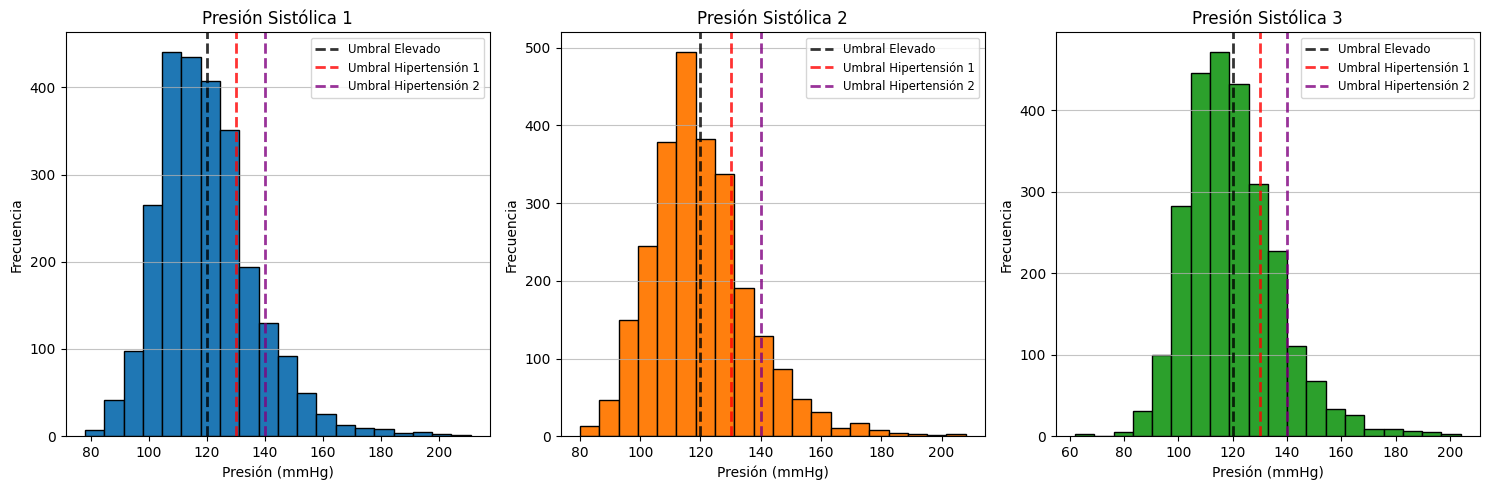

In [79]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3']
titulos = ['Presión Sistólica 1', 'Presión Sistólica 2', 'Presión Sistólica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


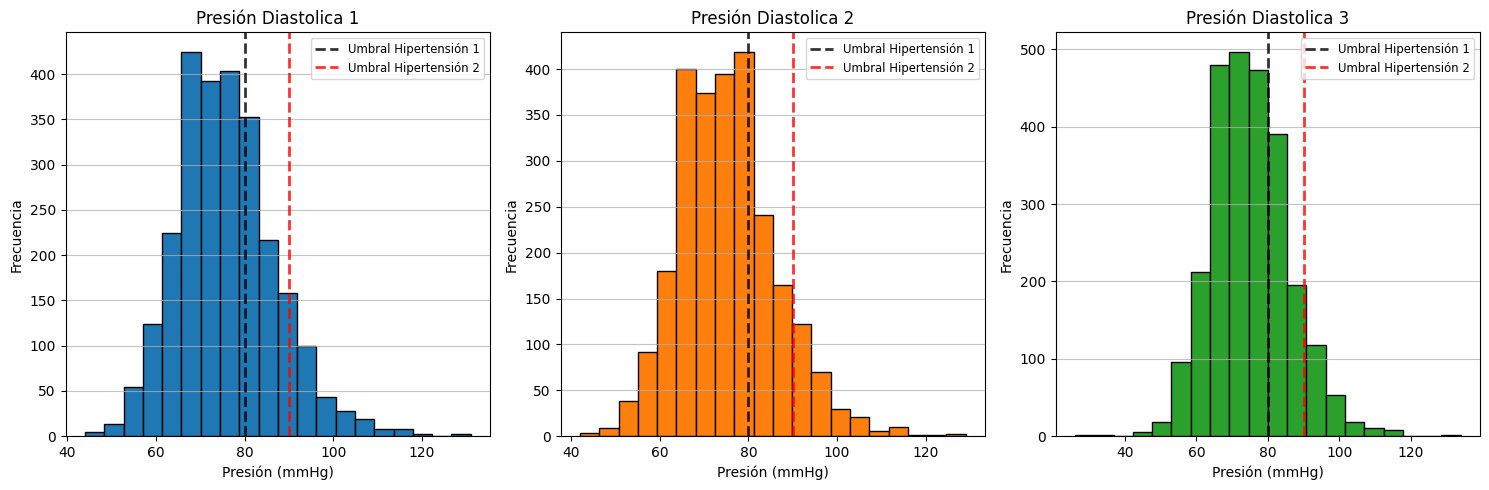

In [80]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3']
titulos = ['Presión Diastolica 1', 'Presión Diastolica 2', 'Presión Diastolica 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    for umbral in umbrales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    axes[i].legend(loc='upper right', fontsize='small')    
# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


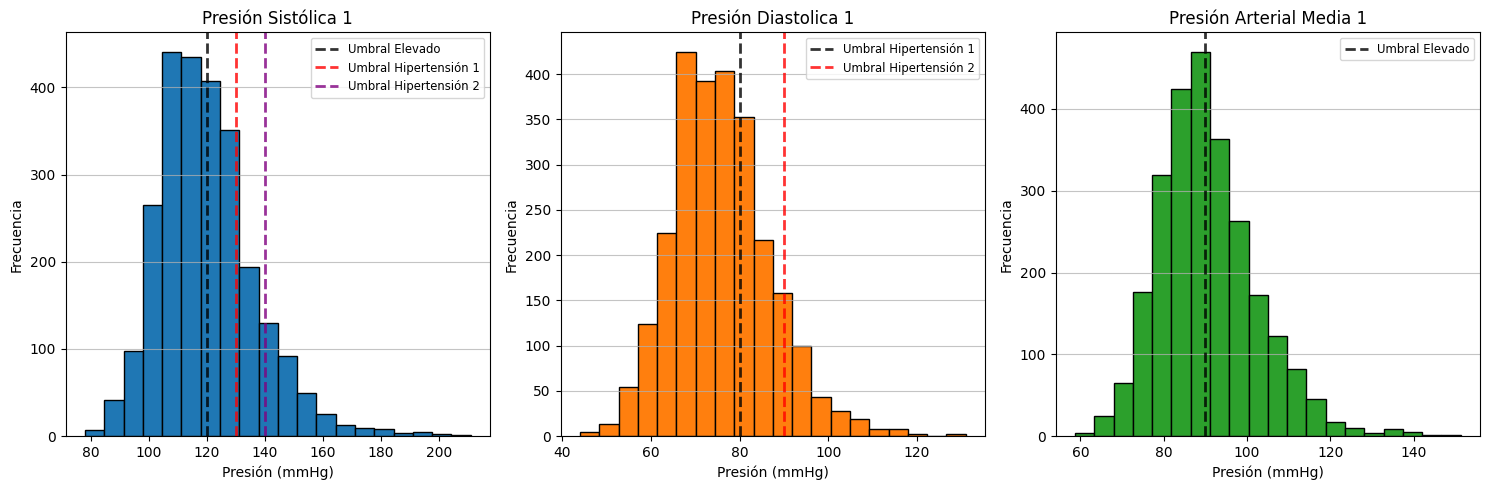

In [81]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_sistolica_1', 'pa_diastolica_1', 'pres_arterial_1']
titulos = ['Presión Sistólica 1', 'Presión Diastolica 1', 'Presión Arterial Media 1']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


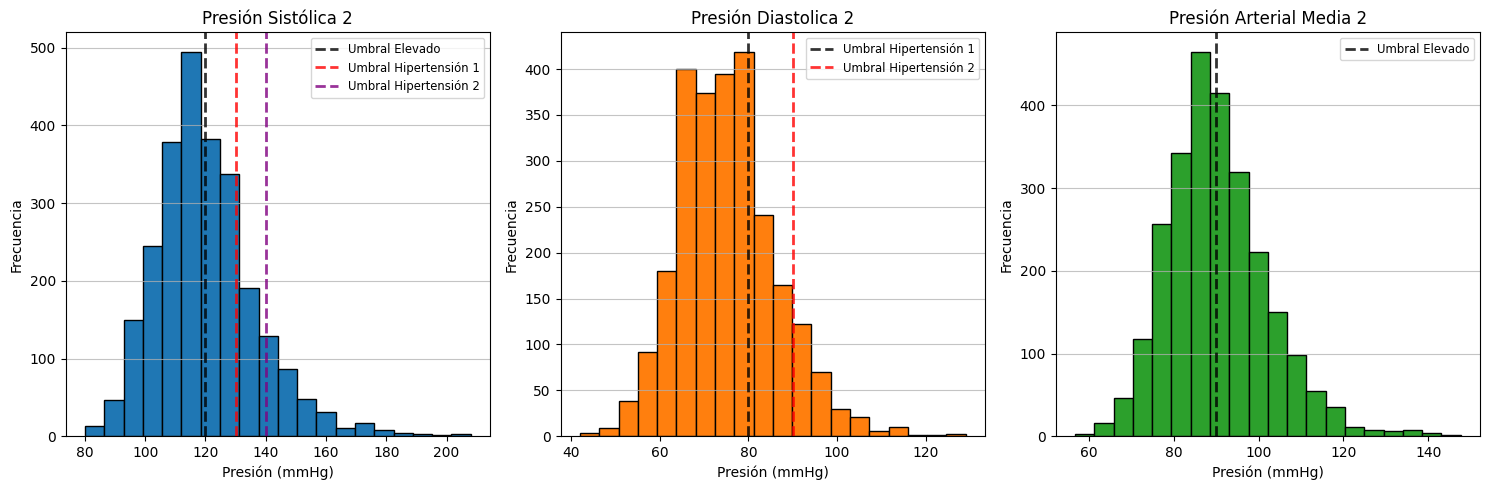

In [82]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_sistolica_2', 'pa_diastolica_2', 'pres_arterial_2']
titulos = ['Presión Sistólica 2', 'Presión Diastolica 2', 'Presión Arterial Media 2']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


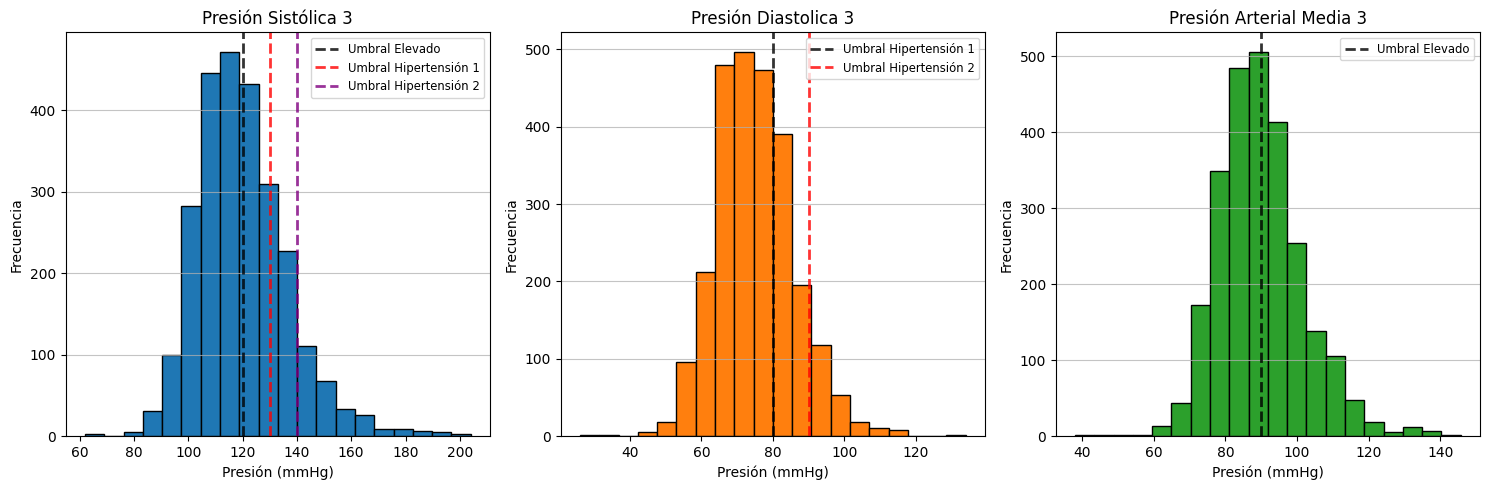

In [83]:
# Configurar el tamaño de la figura (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Variables que vamos a graficar
variables = ['pa_sistolica_3', 'pa_diastolica_3', 'pres_arterial_3']
titulos = ['Presión Sistólica 3', 'Presión Diastolica 3', 'Presión Arterial Media 3']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

umbrales = [
    {'valor': 120, 'color': 'black', 'etiqueta': 'Umbral Elevado'},
    {'valor': 130, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 140, 'color': 'purple', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesDis = [
    {'valor': 80, 'color': 'black', 'etiqueta': 'Umbral Hipertensión 1'},
    {'valor': 90, 'color': 'red', 'etiqueta': 'Umbral Hipertensión 2'}
]
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Elevado'}
]

# Agrupamos los umbrales en una lista que coincida con el orden de las variables
lista_umbrales = [umbrales, umbralesDis, umbralesMed]

# Crear cada histograma con un bucle
for i in range(3):
    # Usamos dropna() para evitar errores con valores nulos (NaN)
    axes[i].hist(df_presion[variables[i]].dropna(), bins=20, color=colores[i], edgecolor='black')
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Presión (mmHg)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.75)

    # Seleccionamos los umbrales correspondientes a la gráfica actual (i)
    umbrales_actuales = lista_umbrales[i]
    
    for umbral in umbrales_actuales:
        axes[i].axvline(
            x=umbral['valor'], 
            color=umbral['color'], 
            linestyle='--', 
            alpha=0.8, 
            linewidth=2, 
            label=umbral['etiqueta']
        )
    
    # Mostrar la leyenda en cada gráfico
    axes[i].legend(loc='upper right', fontsize='small')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

# Mostrar la gráfica
plt.show()


In [84]:
# Definir las listas de columnas para cada cálculo
columnas_sis = ['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3']
columnas_dis = ['pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3']

# Calcular la media ignorando automáticamente los valores nulos (NaN)
df_presion['pa_sis_media'] = df_presion[columnas_sis].mean(axis=1).round(0)
df_presion['pa_dis_media'] = df_presion[columnas_dis].mean(axis=1).round(0)

# Comprobar el resultado
df_presion[['pa_sistolica_1', 'pa_sistolica_2', 'pa_sistolica_3', 'pa_sis_media', 
            'pa_diastolica_1', 'pa_diastolica_2', 'pa_diastolica_3', 'pa_dis_media']].head()


,pa_sistolica_1,pa_sistolica_2,pa_sistolica_3,pa_sis_media,pa_diastolica_1,pa_diastolica_2,pa_diastolica_3,pa_dis_media
0,135.0,131.0,132.0,133.0,98.0,96.0,94.0,96.0
1,121.0,117.0,113.0,117.0,84.0,76.0,76.0,79.0
2,111.0,112.0,104.0,109.0,79.0,80.0,76.0,78.0
3,110.0,120.0,115.0,115.0,72.0,74.0,75.0,74.0
4,99.0,110.0,123.0,111.0,69.0,68.0,67.0,68.0


In [85]:

df_presion['pres_arterial_media'] = (df_presion['pa_sis_media'] + 2 * df_presion['pa_dis_media']) / 3



In [86]:
df_presion['pres_arterial_media'] = df_presion['pres_arterial_media'].round(1)

In [87]:
df_presion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pa_diastolica_1      2580 non-null   float64
 1   pa_diastolica_2      2580 non-null   float64
 2   pa_diastolica_3      2580 non-null   float64
 3   pa_sistolica_1       2580 non-null   float64
 4   pa_sistolica_2       2580 non-null   float64
 5   pa_sistolica_3       2580 non-null   float64
 6   pres_arterial_1      2580 non-null   float64
 7   pres_arterial_2      2580 non-null   float64
 8   pres_arterial_3      2580 non-null   float64
 9   pa_sis_media         2580 non-null   float64
 10  pa_dis_media         2580 non-null   float64
 11  pres_arterial_media  2580 non-null   float64
dtypes: float64(12)
memory usage: 242.0 KB


In [88]:
df_presion.head()

,pa_diastolica_1,pa_diastolica_2,pa_diastolica_3,pa_sistolica_1,pa_sistolica_2,pa_sistolica_3,pres_arterial_1,pres_arterial_2,pres_arterial_3,pa_sis_media,pa_dis_media,pres_arterial_media
0,98.0,96.0,94.0,135.0,131.0,132.0,110.333333,107.666667,106.666667,133.0,96.0,108.3
1,84.0,76.0,76.0,121.0,117.0,113.0,96.333333,89.666667,88.333333,117.0,79.0,91.7
2,79.0,80.0,76.0,111.0,112.0,104.0,89.666667,90.666667,85.333333,109.0,78.0,88.3
3,72.0,74.0,75.0,110.0,120.0,115.0,84.666667,89.333333,88.333333,115.0,74.0,87.7
4,69.0,68.0,67.0,99.0,110.0,123.0,79.000000,82.000000,85.666667,111.0,68.0,82.3


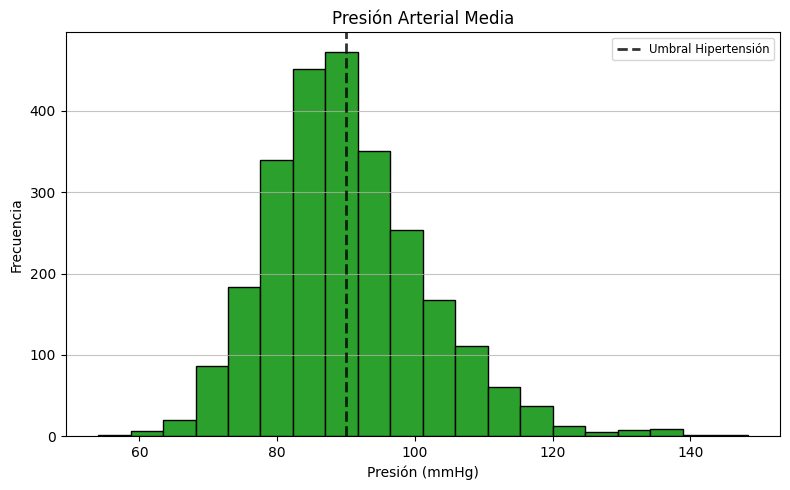

In [89]:
# Configurar el tamaño de la figura (1 solo gráfico)
fig, ax = plt.subplots(figsize=(8, 5))

# Definimos los umbrales específicos para la Presión Arterial Media
umbralesMed = [
    {'valor': 90, 'color': 'black', 'etiqueta': 'Umbral Hipertensión'}
]

# Nombre de la variable en el dataframe (asegúrate de que coincida con tu df, ej: 'pres_arterial_media' o 'pres_arterial_3')
columna = 'pres_arterial_media'

# Crear el histograma
# Usamos dropna() para evitar errores con valores nulos (NaN)
ax.hist(df_presion[columna].dropna(), bins=20, color='#2ca02c', edgecolor='black') # Verde
ax.set_title('Presión Arterial Media')
ax.set_xlabel('Presión (mmHg)')
ax.set_ylabel('Frecuencia')
ax.grid(axis='y', alpha=0.75)

# Añadir las líneas de los umbrales
for umbral in umbralesMed:
    ax.axvline(
        x=umbral['valor'], 
        color=umbral['color'], 
        linestyle='--', 
        alpha=0.8, 
        linewidth=2, 
        label=umbral['etiqueta']
    )

# Mostrar la leyenda
ax.legend(loc='upper right', fontsize='small')

# Ajustar el espaciado
plt.tight_layout()

# Mostrar la gráfica
plt.show()


In [90]:
df['pres_arterial_media'] = df_presion['pres_arterial_media']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Columns: 119 entries, ciclo to pres_arterial_media
dtypes: float64(117), object(2)
memory usage: 2.3+ MB


A continuación vamos a crear la variable binaria correspondiente al target que vamos a emplear, "hipertensión" donde:

- Normal == 0

- Hipertenso == 1

!! Se han eliminado las variables og de presiones diastólicas y sistólicas

In [91]:
# Crear la columna binaria "hipertension"
df["hipertension"] = (df["pres_arterial_media"] > 90).astype(int)

# Mostrar el DataFrame resultante
print(df)

      ciclo  estado_entrevista  genero  edad_an  raza_etnia1  raza_etnia_3  \
0      12.0                2.0     1.0     43.0          5.0           6.0   
1      12.0                2.0     1.0     66.0          3.0           3.0   
2      12.0                2.0     2.0     44.0          2.0           2.0   
3      12.0                2.0     1.0     34.0          1.0           1.0   
4      12.0                2.0     1.0     51.0          3.0           3.0   
...     ...                ...     ...      ...          ...           ...   
2575   12.0                2.0     1.0     33.0          1.0           1.0   
2576   12.0                2.0     2.0     46.0          1.0           1.0   
2577   12.0                2.0     2.0     69.0          5.0           7.0   
2578   12.0                2.0     1.0     50.0          2.0           2.0   
2579   12.0                2.0     1.0     40.0          2.0           2.0   

      periodo_examen  pais_nacimiento  tamano_hogar  peso_entre

## Análisis Variables

In [92]:
# 1. Definición de categóricas utilizando el diccionario
  # Como ya importamos el diccionario en la celda anterior para renombrar no volvemos a importar. 

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
cols_categoricas = [limpiar_nombre(col) for col in cols_categoricas]

print(f"Número de columnas categóricas: {len(cols_categoricas)}")
print(cols_categoricas)

Número de columnas categóricas: 38
['ciclo', 'estado_entrevista', 'genero', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'aprueba_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'estado_medidas_corp', 'estado_elastografia', 'tipo_sonda_elasto', 'nota_albumina_orina', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_mercurio', 'nota_selenio', 'nota_manganeso', 'hipertension']


In [93]:
# 2. Filtrar solo las presentes
cols_categoricas_presentes = [col for col in cols_categoricas if col in df.columns]

# 3. Convertir a category
for col in cols_categoricas_presentes:
    df[col] = df[col].astype('category')

# 4. Identificar numéricas
cols_numericas = df.columns.difference(cols_categoricas_presentes).tolist()

# 5. Verificación CORRECTA
print(f"--- Clasificación Manual Completada ---")
print(f"Variables categóricas (esperadas): {len(cols_categoricas_presentes)}")
print(f"Variables numéricas: {len(cols_numericas)}")

# Conteo correcto de tipos
print("\nResumen de tipos de datos:")
print(df.dtypes.astype(str).value_counts())

# 6. Diagnóstico 
print("\nColumnas categóricas detectadas:")
print(df.select_dtypes(include='category').columns.tolist())

print("\nColumnas object (revisar si deberían ser categóricas):")
print(df.select_dtypes(include='object').columns.tolist())

# Ver qué variables no estaban en el dataset
cols_faltantes = [col for col in cols_categoricas if col not in df.columns]

print(f"\nCategóricas presentes: {len(cols_categoricas_presentes)}")
print(f"Categóricas faltantes: {len(cols_faltantes)}")

--- Clasificación Manual Completada ---
Variables categóricas (esperadas): 38
Variables numéricas: 82

Resumen de tipos de datos:
float64     82
category    38
Name: count, dtype: int64

Columnas categóricas detectadas:
['ciclo', 'estado_entrevista', 'genero', 'raza_etnia1', 'raza_etnia_3', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'caidas', 'fracturas', 'test_densidad_osea', 'medicacion_osteoporosis', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'aprueba_cond4', 'brazo_medicion_pa', 'tamano_manguito_pa', 'estado_medidas_corp', 'estado_elastografia', 'tipo_sonda_elasto', 'nota_albumina_orina', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_mercurio', 'nota_selenio', 'nota_manganeso', 'hipertension']

Columnas object (revisar si deberían ser categóricas):
[]

Categóricas p

Exportacion del dataset con los nombres actualizados

## Valores nulos

Antes de proceder con el análisis de nulos por columna vamos a revisar los nulos que hay por fila.

Distribución de filas según porcentaje de nulos:

rango_nulos
0-10%     2058
10-20%     342
20-30%      59
30-40%      38
40-50%      58
>50%        25
Name: count, dtype: int64


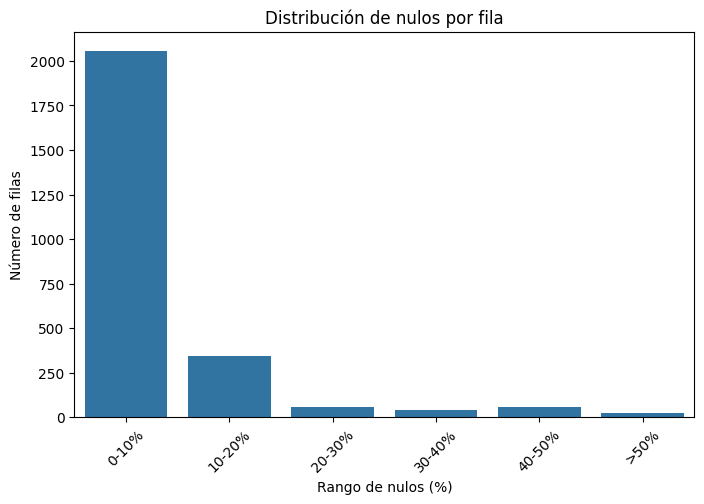


Número de filas con más de 30% de nulos: 121


In [94]:

# 1. Porcentaje de nulos por fila
df_null_rows = df.isnull().mean(axis=1) * 100

# Convertimos a DataFrame para trabajar mejor
df_null_rows = df_null_rows.to_frame(name='porcentaje_nulos')

# 2. Clasificación en rangos (MISMA lógica que columnas)
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%']

df_null_rows['rango_nulos'] = pd.cut(df_null_rows['porcentaje_nulos'], bins=bins, labels=labels, include_lowest=True)

# 3. Conteo por rango
conteo_filas = df_null_rows['rango_nulos'].value_counts().sort_index()

print("Distribución de filas según porcentaje de nulos:\n")
print(conteo_filas)

# 4. Visualización
plt.figure(figsize=(8,5))
sns.barplot(x=conteo_filas.index, y=conteo_filas.values)
plt.title("Distribución de nulos por fila")
plt.xlabel("Rango de nulos (%)")
plt.ylabel("Número de filas")
plt.xticks(rotation=45)
plt.show()

# 5. Filas problemáticas (>30%)
filas_malas = df_null_rows[df_null_rows['porcentaje_nulos'] > 30]

print(f"\nNúmero de filas con más de 30% de nulos: {len(filas_malas)}")

La mayor parte de nuestros pacientes presentan un porcentage de nulos ínfimo (0-10%). Para evitar perder un gran volumen de pacientes, vamos a proceder a eliminar únicamente aquellos cuyo porcentage de nulos sea superior al 30%

In [95]:
# 1. Filtrar filas con <=30% de nulos
df_clean_rows = df[df_null_rows['porcentaje_nulos'] <= 30].copy()

# 2. Comparación antes vs después
print("ANTES:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nDESPUÉS (filtrando >30% nulos):")
print(f"Filas: {df_clean_rows.shape[0]}")
print(f"Columnas: {df_clean_rows.shape[1]}")

# 3. Filas eliminadas
filas_eliminadas = df.shape[0] - df_clean_rows.shape[0]
print(f"\nFilas eliminadas: {filas_eliminadas}")
df = df_clean_rows

ANTES:
Filas: 2580
Columnas: 120

DESPUÉS (filtrando >30% nulos):
Filas: 2459
Columnas: 120

Filas eliminadas: 121


In [96]:
# Cálculo de porcentajes de nulos
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

# Tabla resumen de nulos
df_nulls = pd.DataFrame({
    'Variable': null_percentages.index,
    'Porcentaje_Nulos': null_percentages.values
}).sort_values(by='Porcentaje_Nulos', ascending=False)

# Clasificación por rangos 
bins = [0, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '>30%']

# Creamos una columna de rango 
df_nulls['Rango'] = pd.cut(df_nulls['Porcentaje_Nulos'], bins=bins, labels=labels, include_lowest=True)

# Mostrar conteo de variables por rango
resumen_rangos = df_nulls['Rango'].value_counts().sort_index()

print("--- Resumen de Variables por Rango de Nulos ---")
for rango, cantidad in resumen_rangos.items():
    print(f"Rango {rango}: {cantidad} variables")

# Mostrar las variables con más nulos 
print("\nPorcentage de nulos por variable")
print(df_nulls.to_string(index=False))

--- Resumen de Variables por Rango de Nulos ---
Rango 0-10%: 101 variables
Rango 10-20%: 13 variables
Rango 20-30%: 6 variables
Rango >30%: 0 variables

Porcentage de nulos por variable
                      Variable  Porcentaje_Nulos  Rango
       medicacion_osteoporosis         24.440830 20-30%
            test_densidad_osea         22.244815 20-30%
               cant_antiacidos         20.699471 20-30%
               toma_antiacidos         20.699471 20-30%
              toma_suplementos         20.496137 20-30%
              cant_suplementos         20.496137 20-30%
              tiempo_seg_cond4         16.795445 10-20%
                 aprueba_cond4         16.632778 10-20%
              tiempo_seg_cond3         16.266775 10-20%
                 aprueba_cond3         16.063440 10-20%
              tiempo_seg_cond2         15.209435 10-20%
                 aprueba_cond2         15.168768 10-20%
              tiempo_seg_cond1         15.046767 10-20%
                 aprueba_cond1

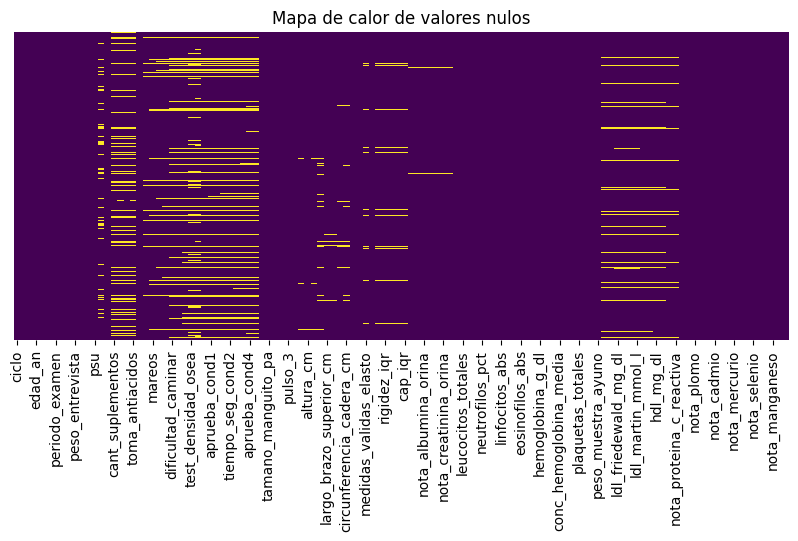

In [97]:
# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean_rows.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

## Distribución de Categóricas

Tras haber definifo las variables categóricas procedemos a observar la distribución y a buscar si se pudiese combinar variables de este tipo.

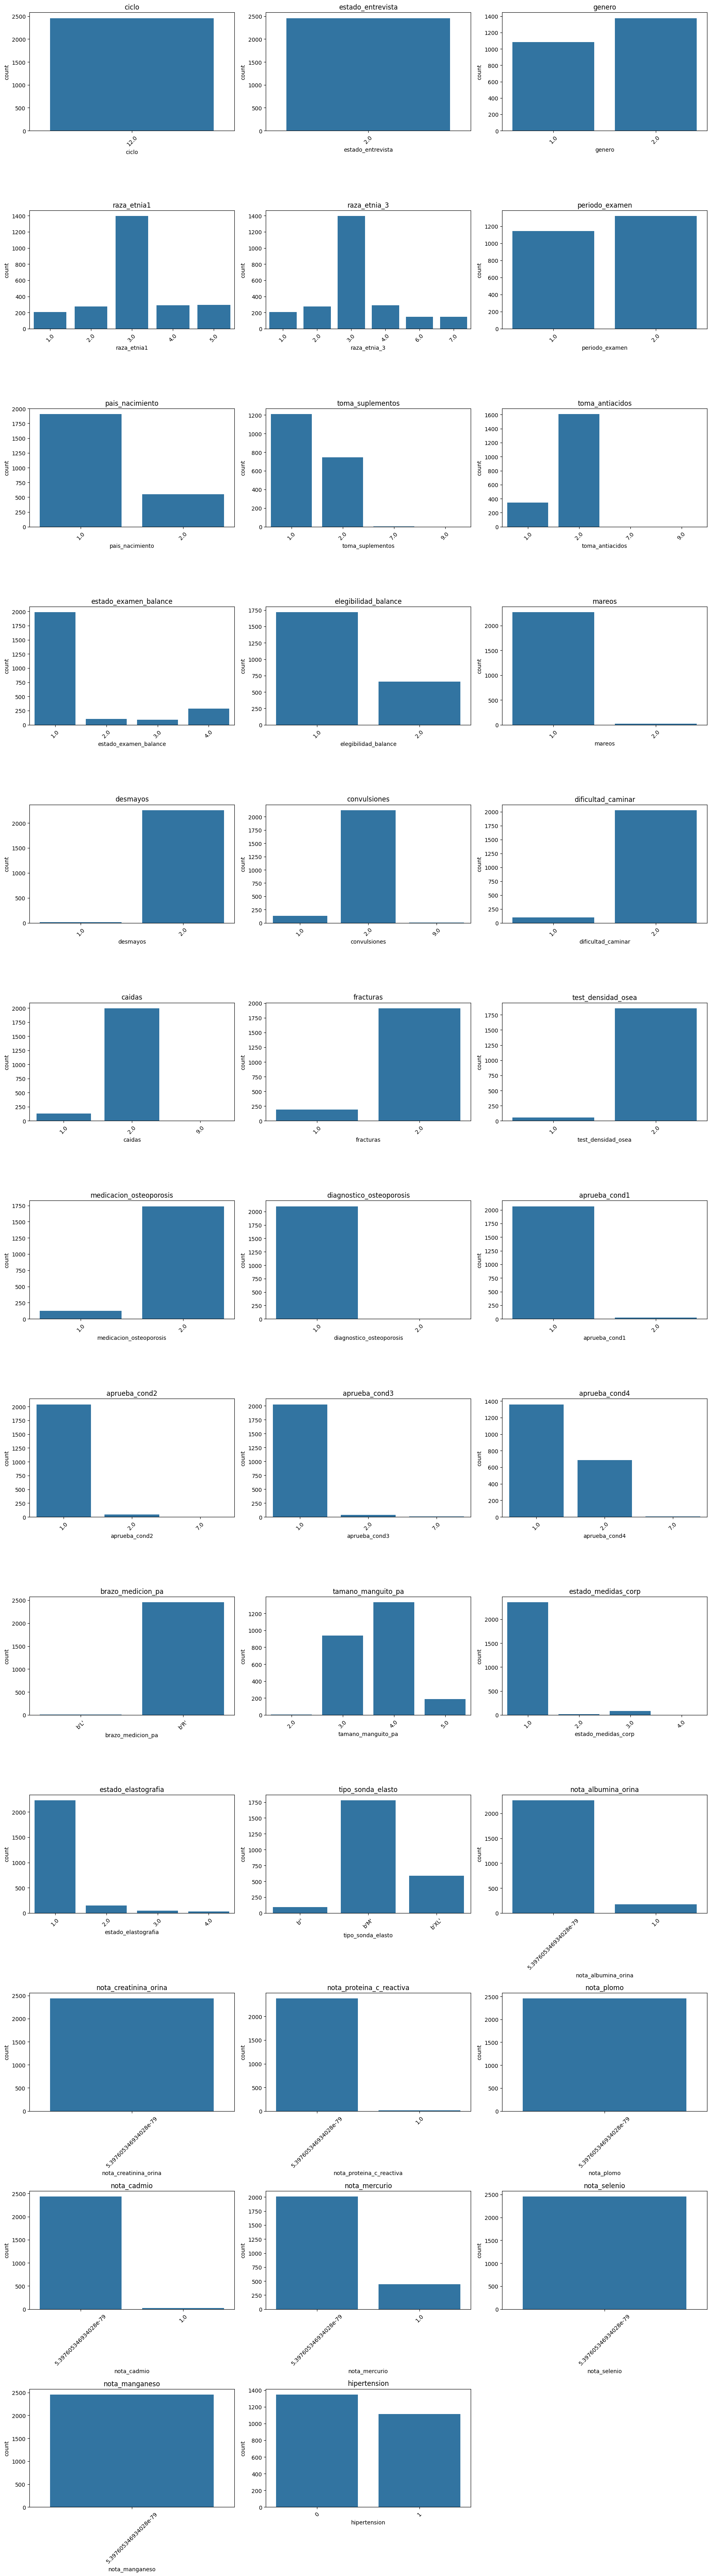

In [98]:
# 1. Configuración
n_cols = 3  # nº de gráficos por fila
n_vars = len(cols_categoricas)
n_rows = (n_vars // n_cols) + 1

plt.figure(figsize=(18, 5 * n_rows))

# 2. Loop por variables categóricas
for i, col in enumerate(cols_categoricas):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Conteo de valores
    conteo = df[col].value_counts().reset_index()
    conteo.columns = [col, 'count']
    
    # Barplot
    sns.barplot(data=conteo, x=col, y='count')
    
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<u>**Análisis resultados**</u>

Una gran parte de las variables categóricas presenta un fuerte desbalance, donde una categoría domina claramente sobre las demás.

Ejemplos representativos:
- `mareos`, `desmayos`, `convulsiones`
- `dificultad_caminar`, `caidas`, `fracturas`
- `med_osteoporosis`, `diag_osteoporosis`

Este desbalance implica que una categoría domina claramente sobre el resto. Esto es consistente con datos de población general, pero introduce sesgos, favoreciendo la clase mayoritaria.

Además, se identifican variables con muy baja variabilidad o prácticamente constantes, especialmente en indicadores de laboratorio o variables técnicas. Estas variables aportan poca o ninguna información relevante, por lo que pueden ser consideradas candidatas a eliminación en fases posteriores del análisis.




In [99]:
# Como primer paso vamos a eliminar las variables muy desbalanceadas
vars_desbalanceadas = []

for col in df.columns:
    if col in cols_categoricas:
        frec = df[col].value_counts(normalize=True).max()
        
        if frec > 0.95:
            vars_desbalanceadas.append(col)

print("Variables muy desbalanceadas:")
print(vars_desbalanceadas)
print("Variables totales categóricas:")
print(len(cols_categoricas))

df = df.drop(columns=vars_desbalanceadas)
cols_categoricas = [
    col for col in cols_categoricas
    if col not in vars_desbalanceadas
]

# Eliminamos las variables "notas" dado que realmente no tenemos los comentarios concretos y no generan información relevante
df = df.drop(columns=df.filter(like="nota").columns)

# Mostrar el DataFrame resultante
print(df)

print("Variables categóricas tras limpieza:")
print(len(cols_categoricas))

Variables muy desbalanceadas:
['ciclo', 'estado_entrevista', 'mareos', 'desmayos', 'dificultad_caminar', 'test_densidad_osea', 'diagnostico_osteoporosis', 'aprueba_cond1', 'aprueba_cond2', 'aprueba_cond3', 'brazo_medicion_pa', 'estado_medidas_corp', 'nota_creatinina_orina', 'nota_proteina_c_reactiva', 'nota_plomo', 'nota_cadmio', 'nota_selenio', 'nota_manganeso']
Variables totales categóricas:
38
     genero  edad_an raza_etnia1 raza_etnia_3 periodo_examen pais_nacimiento  \
0       1.0     43.0         5.0          6.0            2.0             2.0   
1       1.0     66.0         3.0          3.0            2.0             1.0   
2       2.0     44.0         2.0          2.0            1.0             2.0   
3       1.0     34.0         1.0          1.0            1.0             1.0   
4       1.0     51.0         3.0          3.0            1.0             1.0   
...     ...      ...         ...          ...            ...             ...   
2574    2.0     54.0         3.0        

Cabe destacar que nuestras variables NO SON BINARIAS.

En la documentación viene especificado que muchas de nustras variables binarias vienen dadas con '1' y '2'. Además, muchos nulos tienen un valor dado (como 3, 4, 7 o 9) por lo que no aparecen en una primera inspección. 

Por lo tanto, primero vamos a dividir las bariables entre binarias, binarias especiales y no binarias. Posteriormente aplicaremos una función para convertirlas en binarias codificadas adecuadamente con los 1, 0 y NaN que correspondan.

In [100]:
binarias_puras = []
binarias_especiales = []
no_binarias = []

for col in cols_categoricas:
    if col not in df.columns:
        continue
    
    valores = pd.Series(df[col].dropna().unique()).tolist()
    valores_validos = sorted([v for v in valores if pd.notna(v)])
    valores_set = set(valores_validos)
    
    # sin contar NaN
    if valores_set.issubset({1, 2}):
        binarias_puras.append(col)
    
    elif valores_set.issubset({1, 2, 7, 9, 3, 4}):
        binarias_especiales.append(col)
    
    else:
        no_binarias.append(col)


In [101]:
print("\n=== BINARIAS PURAS (1/2) ===")
for col in binarias_puras:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())

print("\n=== BINARIAS CON CÓDIGOS ESPECIALES (1/2/7/9) ===")
for col in binarias_especiales:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())

print("\n=== NO BINARIAS ===")
for col in no_binarias:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())


=== BINARIAS PURAS (1/2) ===

VARIABLE: genero
[1.0, 2.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: periodo_examen
[2.0, 1.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: pais_nacimiento
[2.0, 1.0]
Categories (2, float64): [1.0, 2.0]

VARIABLE: elegibilidad_balance
[1.0, 2.0, NaN]
Categories (2, float64): [1.0, 2.0]

VARIABLE: fracturas
[2.0, 1.0, NaN]
Categories (2, float64): [1.0, 2.0]

VARIABLE: medicacion_osteoporosis
[2.0, NaN, 1.0]
Categories (2, float64): [1.0, 2.0]

=== BINARIAS CON CÓDIGOS ESPECIALES (1/2/7/9) ===

VARIABLE: toma_suplementos
[2.0, 1.0, NaN, 7.0, 9.0]
Categories (4, float64): [1.0, 2.0, 7.0, 9.0]

VARIABLE: toma_antiacidos
[2.0, NaN, 1.0, 7.0]
Categories (4, float64): [1.0, 2.0, 7.0, 9.0]

VARIABLE: estado_examen_balance
[1.0, 3.0, 2.0, 4.0]
Categories (4, float64): [1.0, 2.0, 3.0, 4.0]

VARIABLE: convulsiones
[2.0, NaN, 1.0, 9.0]
Categories (3, float64): [1.0, 2.0, 9.0]

VARIABLE: caidas
[2.0, 1.0, NaN, 9.0]
Categories (3, float64): [1.0, 2.0, 9.0]

VA

Del listado anterior, pasaremos a binario las columnas de las categorías "binarias puras" y "binarias especiales".

En las "no binarias" encontramos el conjunto de columnas que recogen el código de un comentario realizado por el paciente respecto a la prueba realizada, por lo que las trataremos a parte.

In [102]:
# función para volver las variables a binario
def recodif_binario(col):
    return col.map({
        1.0: 1,
        2.0: 0,
        3.0: pd.NA,
        4.0: pd.NA,
        7.0: pd.NA,
        9.0: pd.NA
    }).astype("Int64")

In [103]:
cols_binarias = binarias_puras + binarias_especiales

for col in cols_binarias:
        if col not in df.columns:
                continue
        
        df[col] = recodif_binario(df[col])

In [104]:
for col in cols_binarias:
    
    if col not in df.columns:
        continue
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print(df[col].unique())


VARIABLE: genero
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64

VARIABLE: periodo_examen
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64

VARIABLE: pais_nacimiento
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64

VARIABLE: elegibilidad_balance
<IntegerArray>
[1, 0, <NA>]
Length: 3, dtype: Int64

VARIABLE: fracturas
<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

VARIABLE: medicacion_osteoporosis
<IntegerArray>
[0, <NA>, 1]
Length: 3, dtype: Int64

VARIABLE: toma_suplementos
<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

VARIABLE: toma_antiacidos
<IntegerArray>
[0, <NA>, 1]
Length: 3, dtype: Int64

VARIABLE: estado_examen_balance
<IntegerArray>
[1, <NA>, 0]
Length: 3, dtype: Int64

VARIABLE: convulsiones
<IntegerArray>
[0, <NA>, 1]
Length: 3, dtype: Int64

VARIABLE: caidas
<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

VARIABLE: aprueba_cond4
<IntegerArray>
[0, 1, <NA>]
Length: 3, dtype: Int64

VARIABLE: estado_elastografia
<IntegerArray>
[1, 0, <NA>]
Length: 3, dtype: Int

Dado que hemos metido nuevos nulos, vamos a revisar la distribución de estos.

Porcentaje de nulos en variables binarias:


,variable,porcentaje_nulos
0,medicacion_osteoporosis,24.440830
1,toma_antiacidos,20.740138
2,toma_suplementos,20.618137
3,aprueba_cond4,16.795445
4,estado_examen_balance,15.006100
5,fracturas,14.599431
6,caidas,13.664091
7,convulsiones,8.377389
8,elegibilidad_balance,3.375356
9,estado_elastografia,3.212688


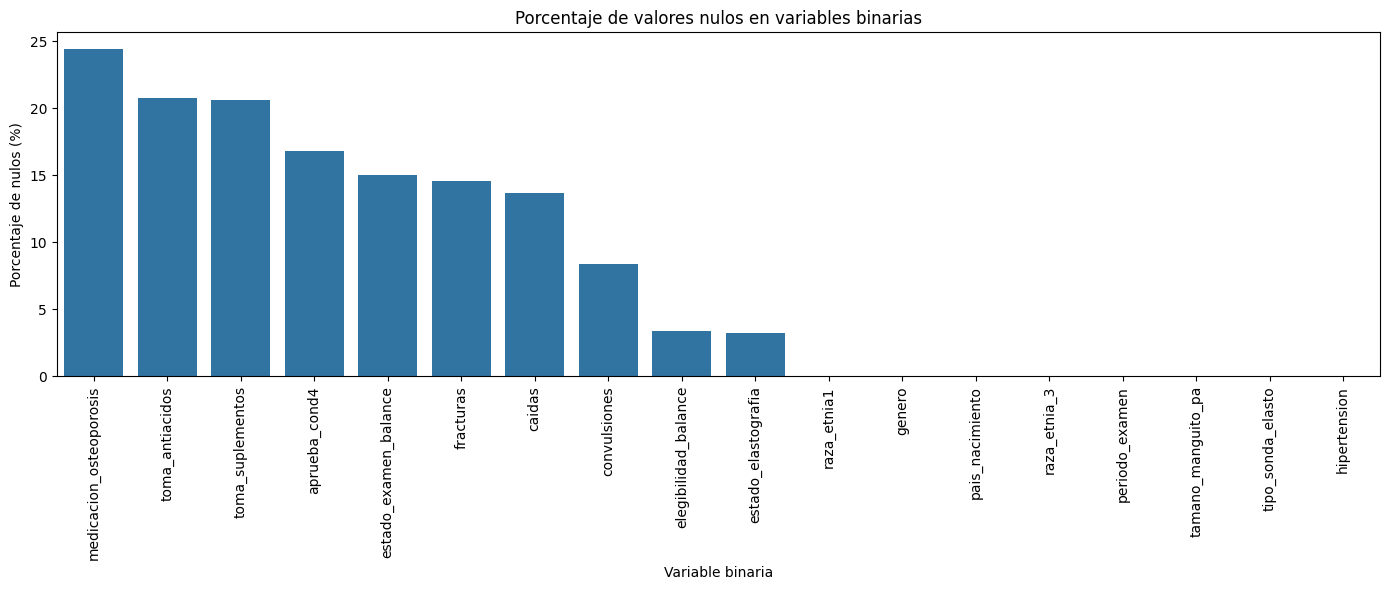

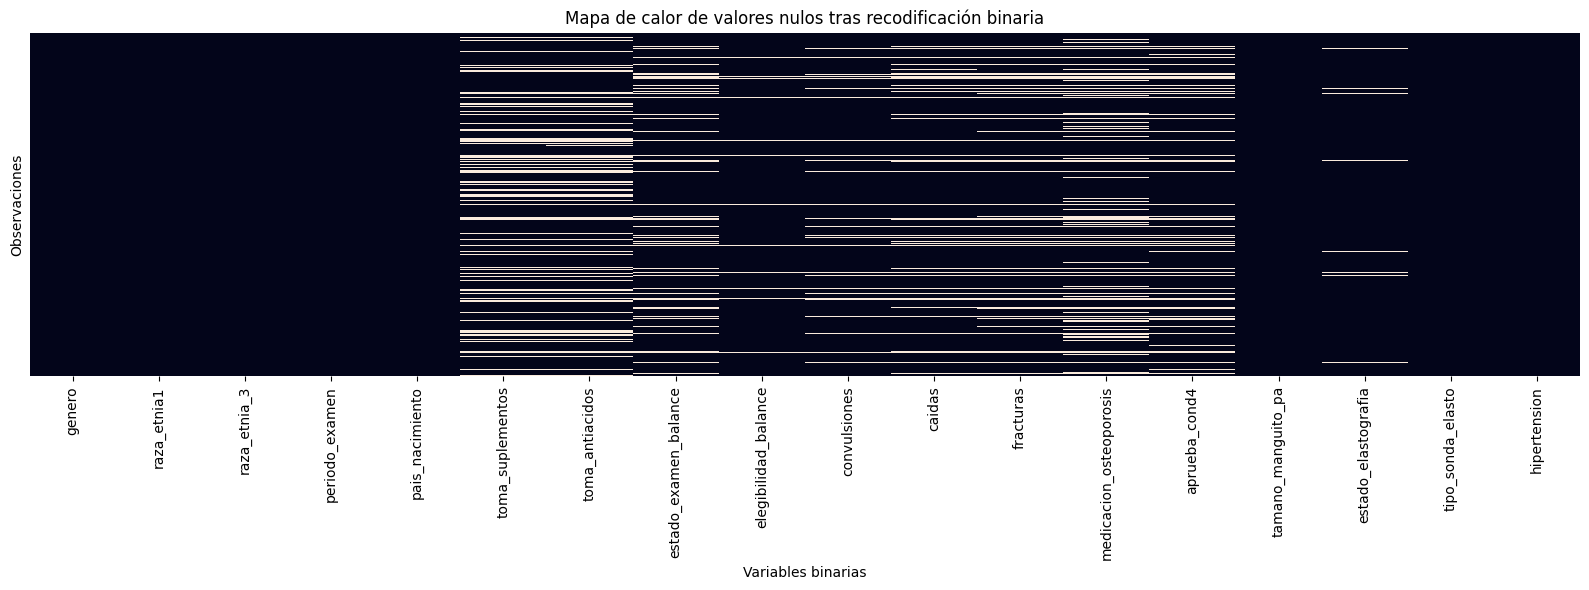

In [105]:
# 1. Revisar nulos tras recodificación binaria

# porcentaje de nulos
cols_categoricas = [
    col for col in cols_categoricas
    if col in df.columns
]

porcentaje_nulos = (
    df[cols_categoricas]
    .isnull()
    .mean() * 100
).sort_values(ascending=False)


df_nulos = porcentaje_nulos.reset_index()
df_nulos.columns = ['variable', 'porcentaje_nulos']

print("Porcentaje de nulos en variables binarias:")
display(df_nulos)

# 2. Barplot porcentaje de nulos
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_nulos,
    x='variable',
    y='porcentaje_nulos'
)

plt.title('Porcentaje de valores nulos en variables binarias')
plt.xlabel('Variable binaria')
plt.ylabel('Porcentaje de nulos (%)')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 3. Heatmap de nulos
plt.figure(figsize=(16, 6))

sns.heatmap(
    df[cols_categoricas].isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Mapa de calor de valores nulos tras recodificación binaria')
plt.xlabel('Variables binarias')
plt.ylabel('Observaciones')

plt.tight_layout()
plt.show()

Hay un crecimiento en los nulos, que era lo esperado, pero resulta tan insignificante que no afecta especialmente al porcentaje previo de nulos en la variable.

Para lidiar con ellos, dado su porcentage y que son MCAR en su inmensa mayoría, vamos a imputarlos utilizando la moda.

In [106]:
for col in cols_categoricas:
    
    # calcular moda
    moda = df[col].mode(dropna=True)
    
    # evitar errores si una columna está completamente vacía
    if len(moda) == 0:
        continue
    moda = moda[0]
    
    # imputar nulos
    df[col] = df[col].fillna(moda)
    df[col] = df[col].astype('category')

In [107]:
nulos_restantes = df[cols_categoricas].isnull().sum()

nulos_restantes = nulos_restantes[nulos_restantes > 0]

print("Nulos restantes en categóricas:")
display(nulos_restantes)

Nulos restantes en categóricas:


Series([], dtype: int64)

## Distribuciones y Outliers (Numéricas)

### Distribuciones Globales

Volvemos a analizar las variables numericas ya que se han elimando algunas variables

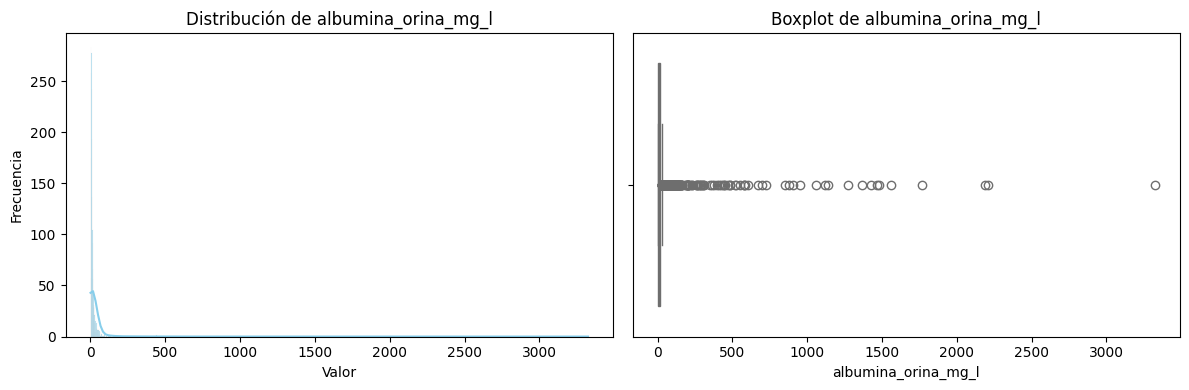

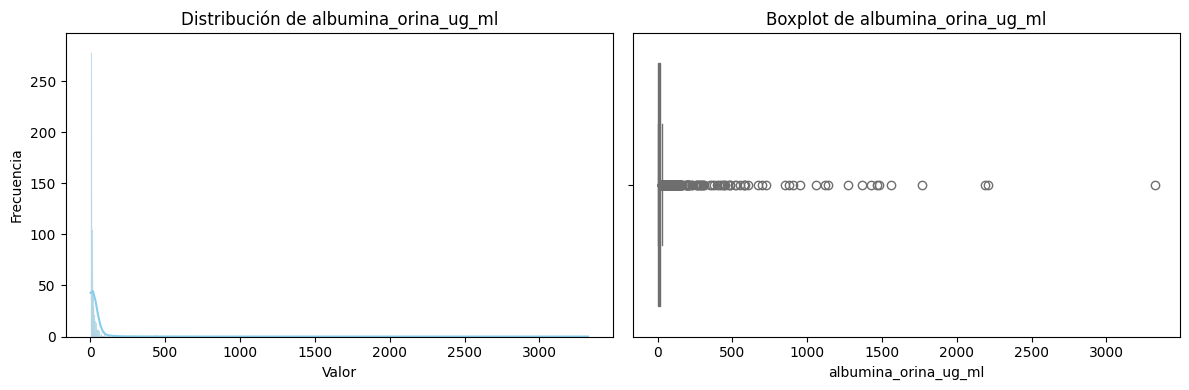

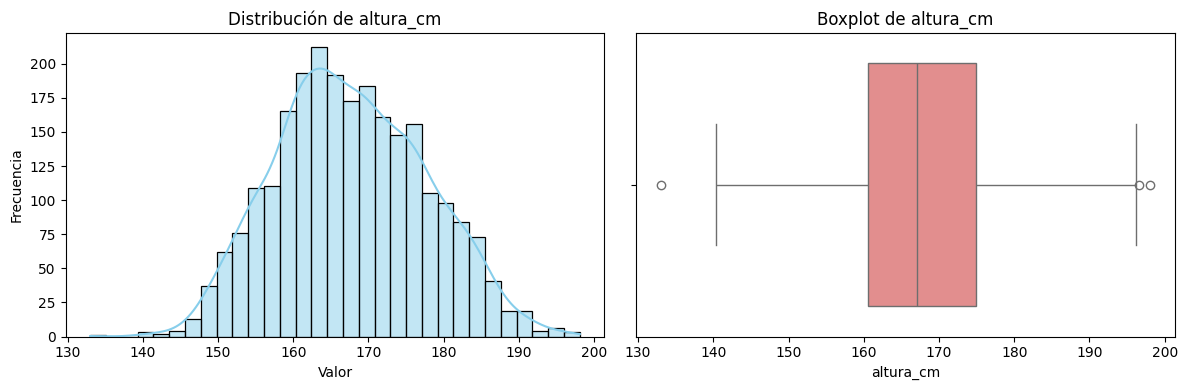

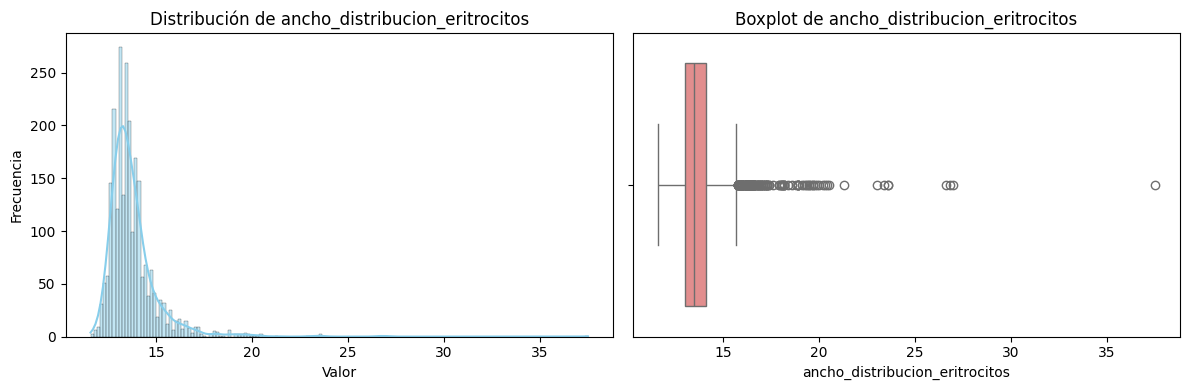

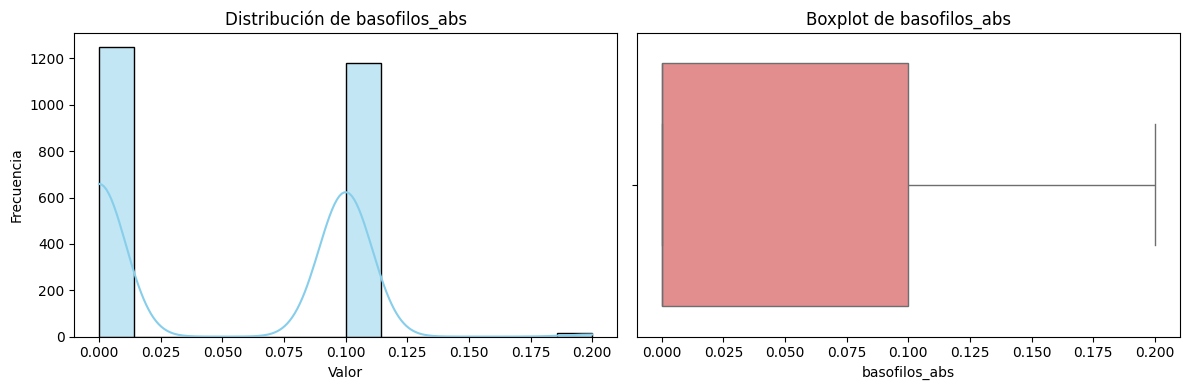

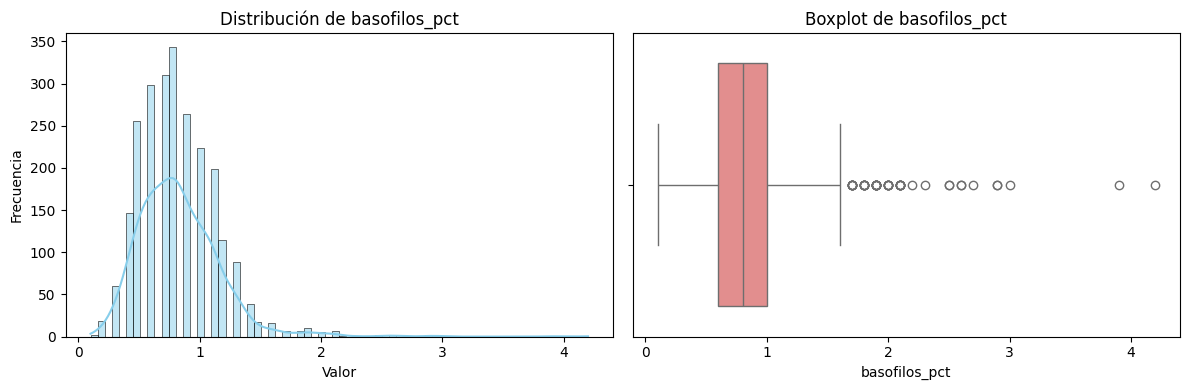

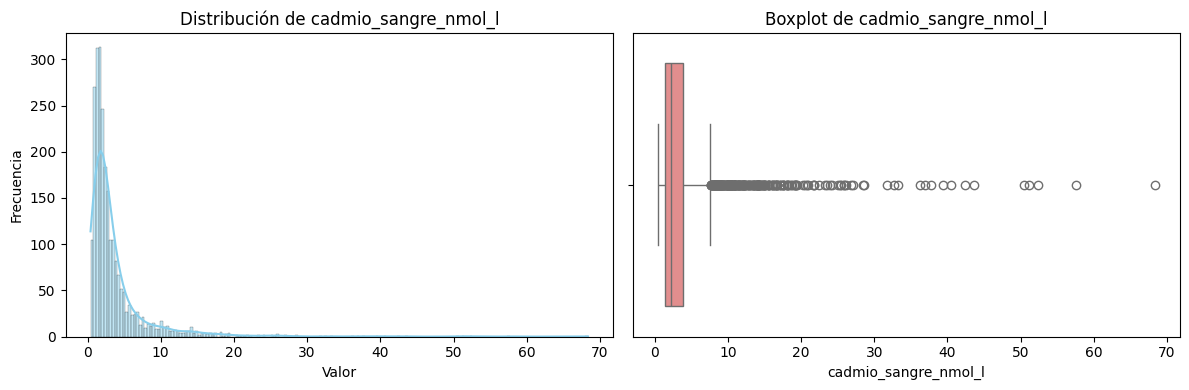

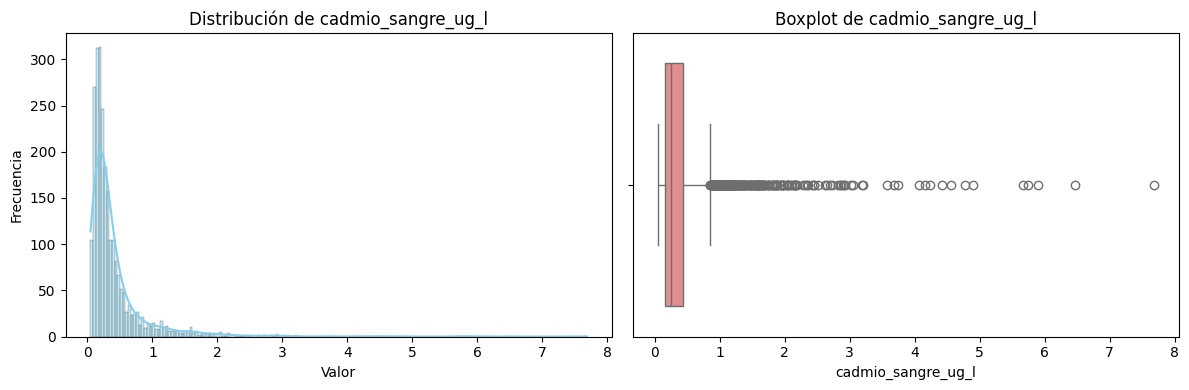

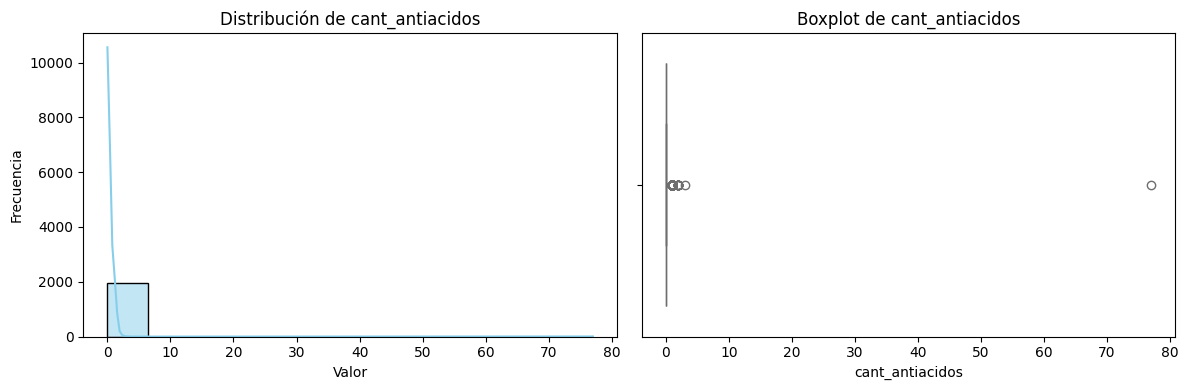

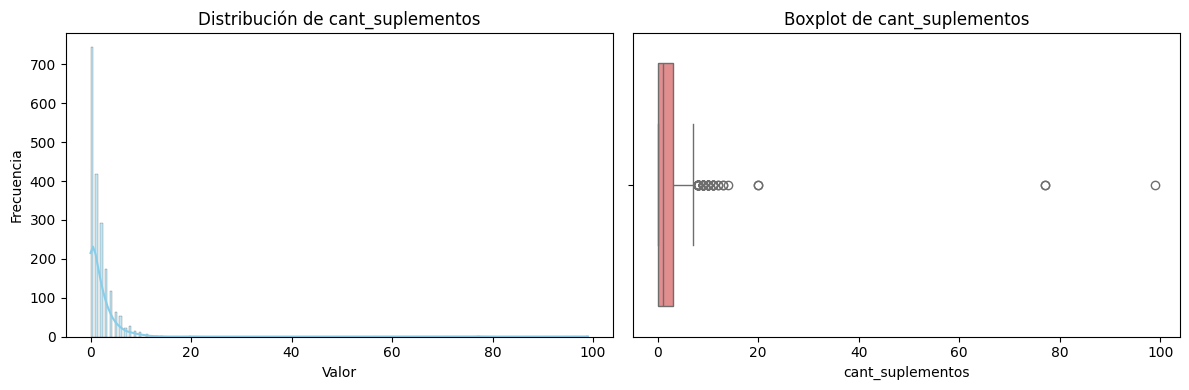

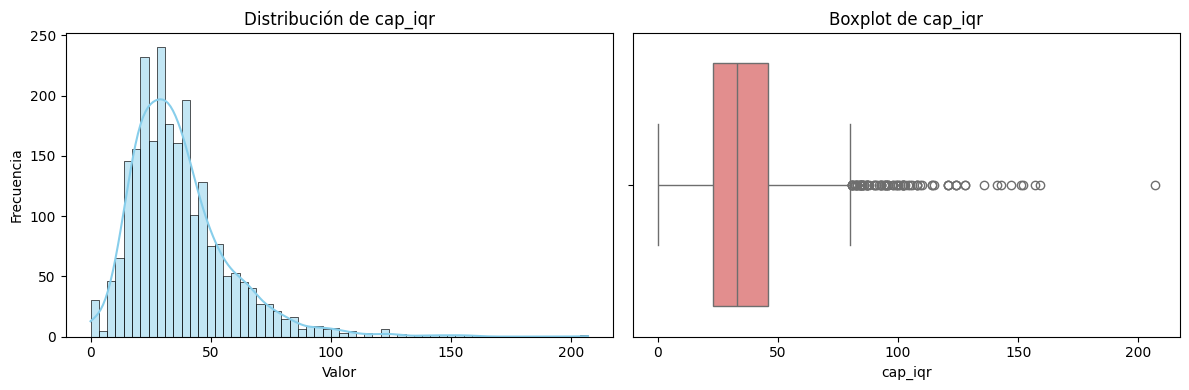

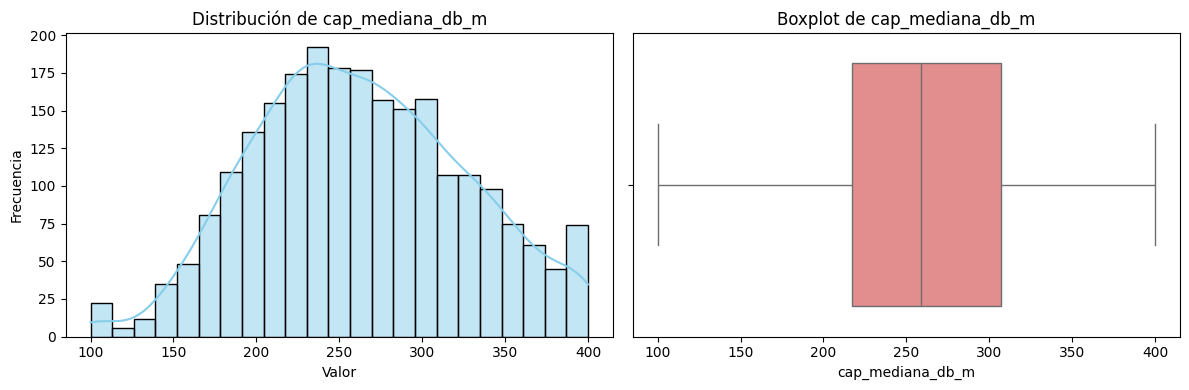

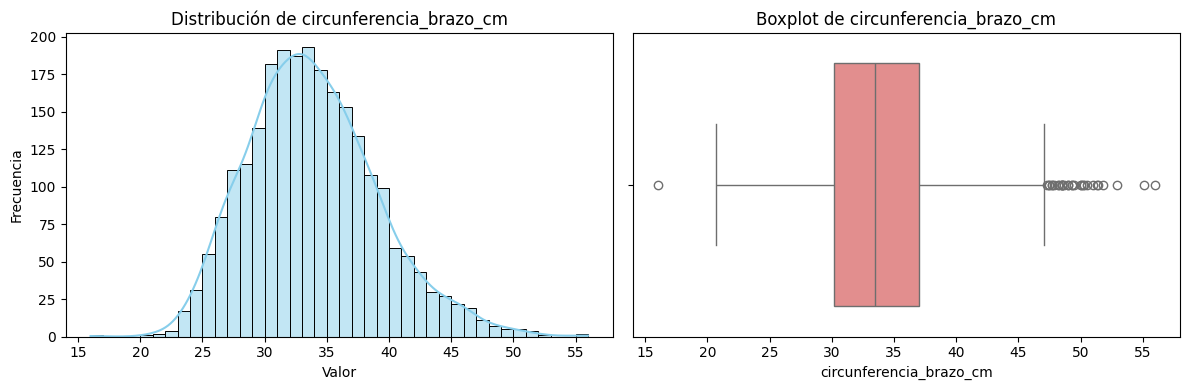

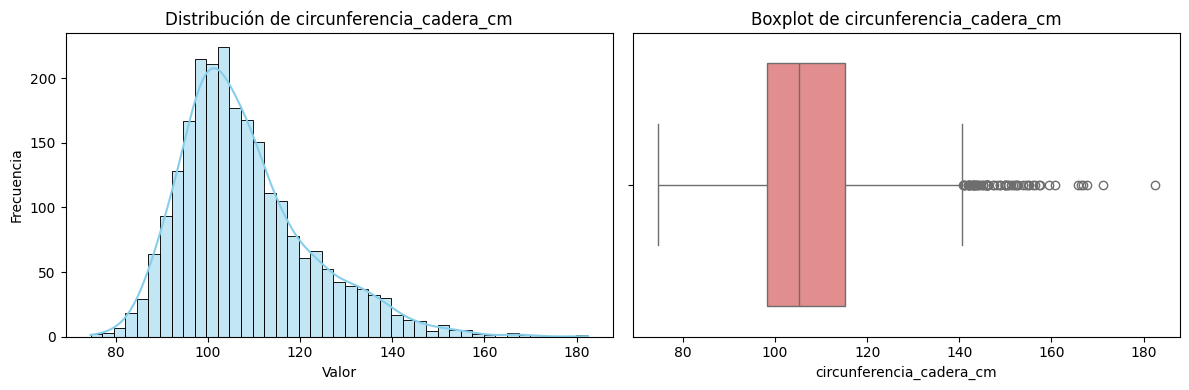

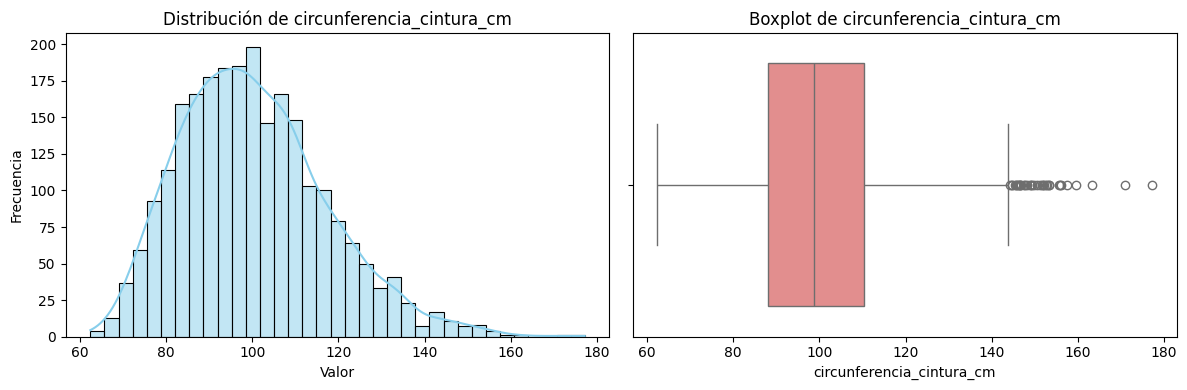

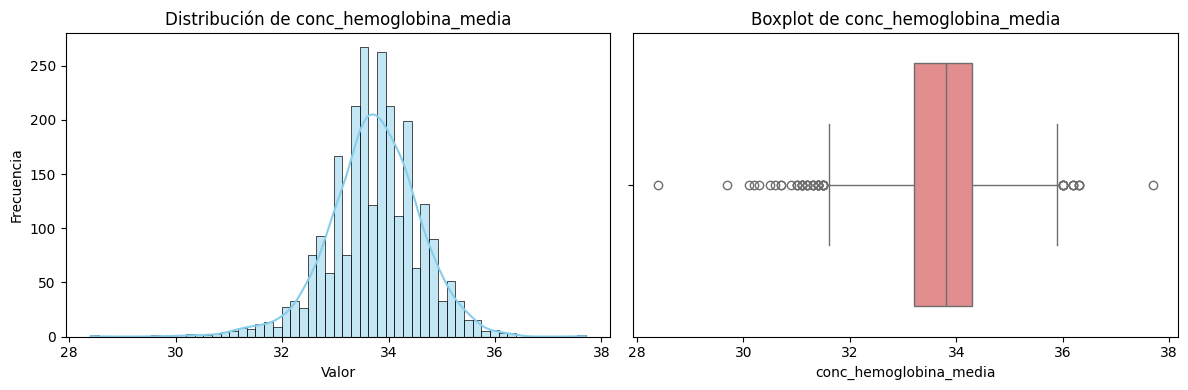

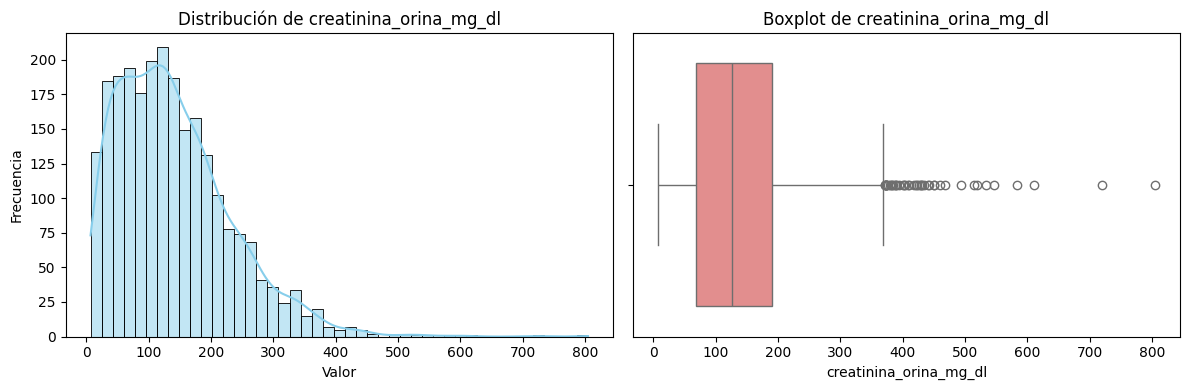

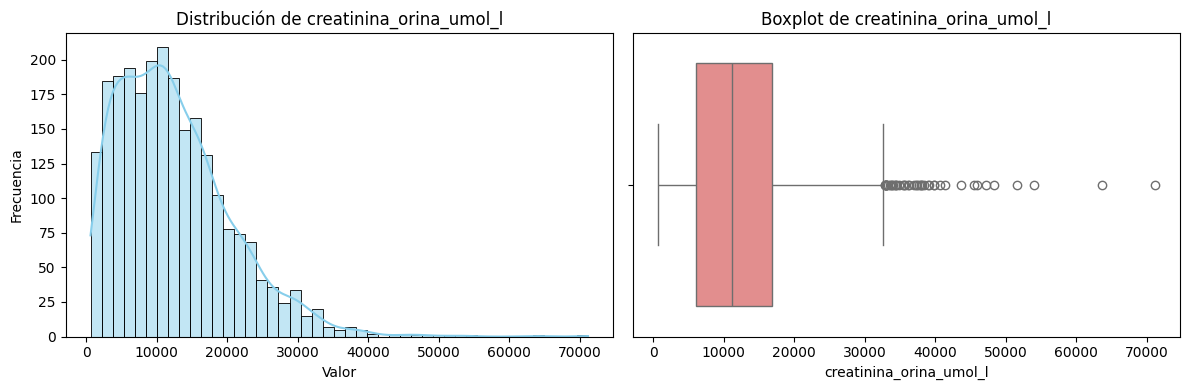

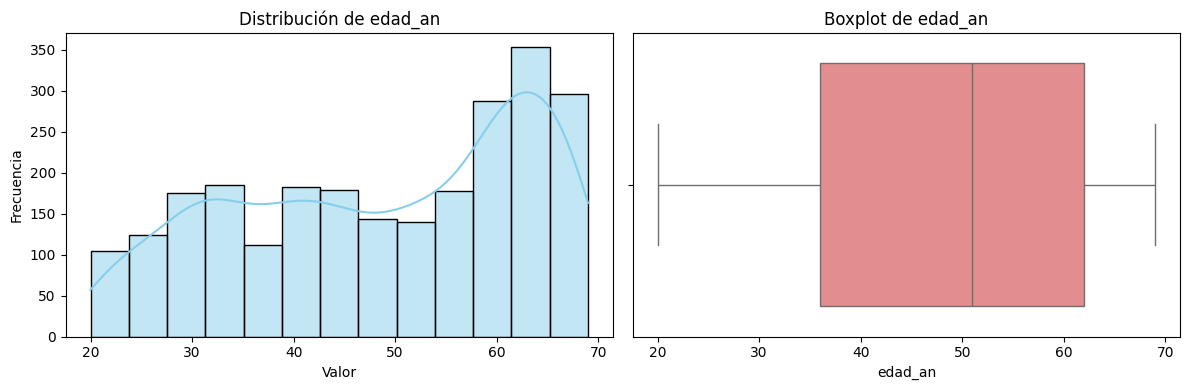

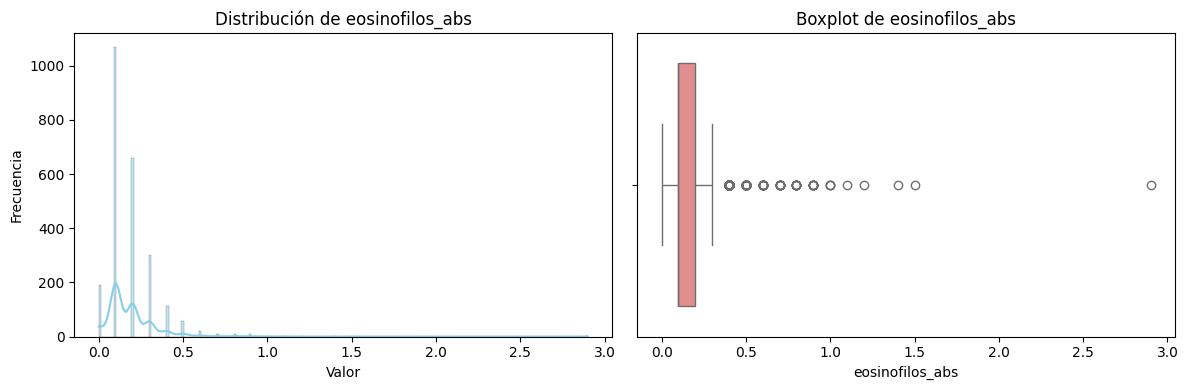

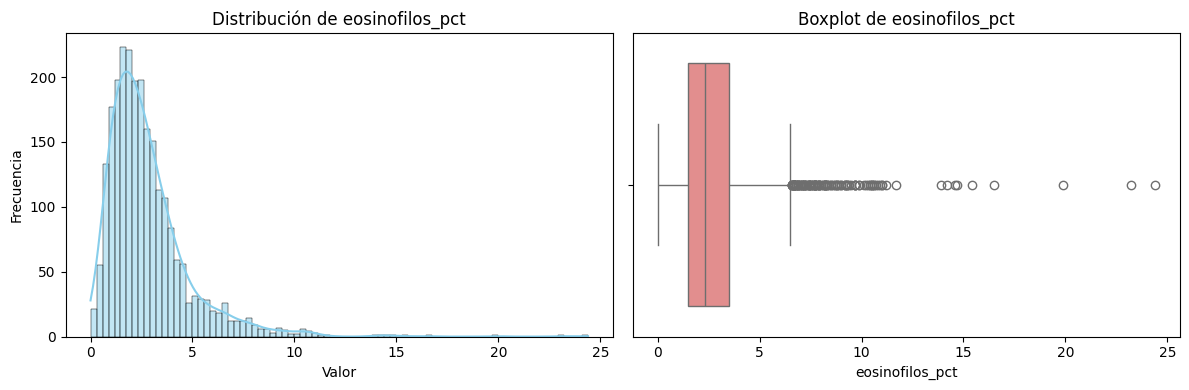

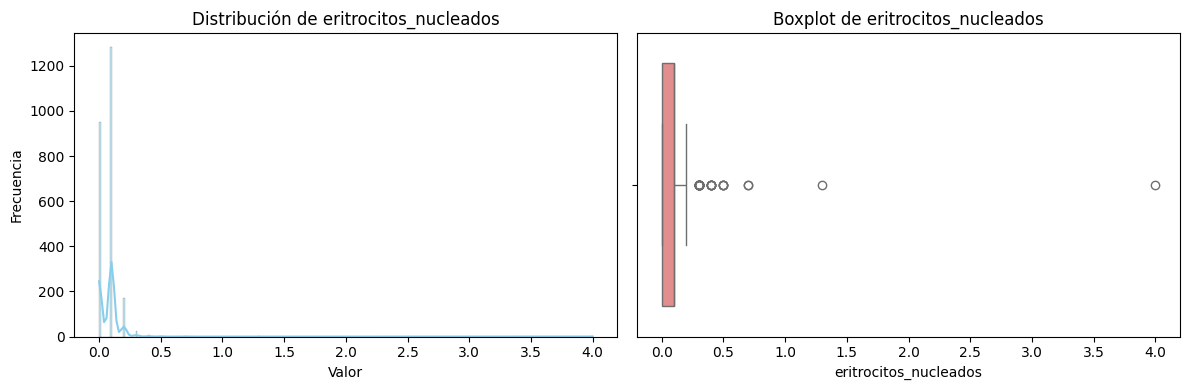

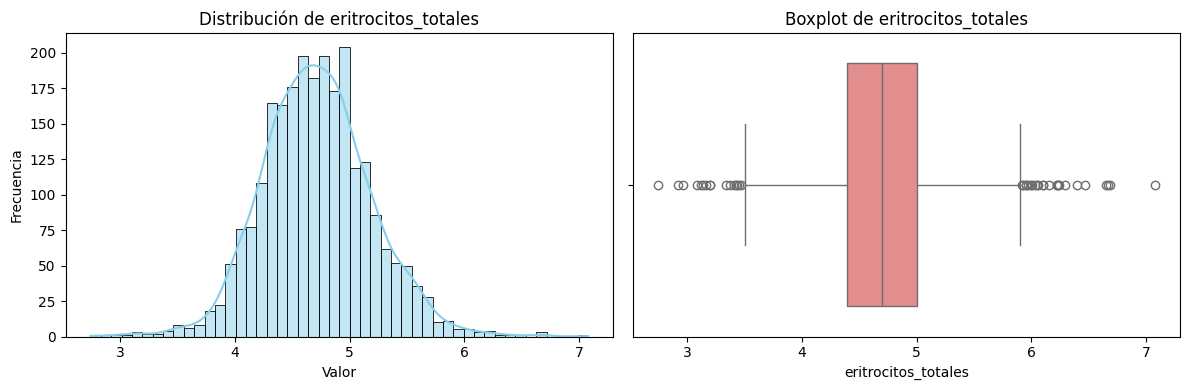

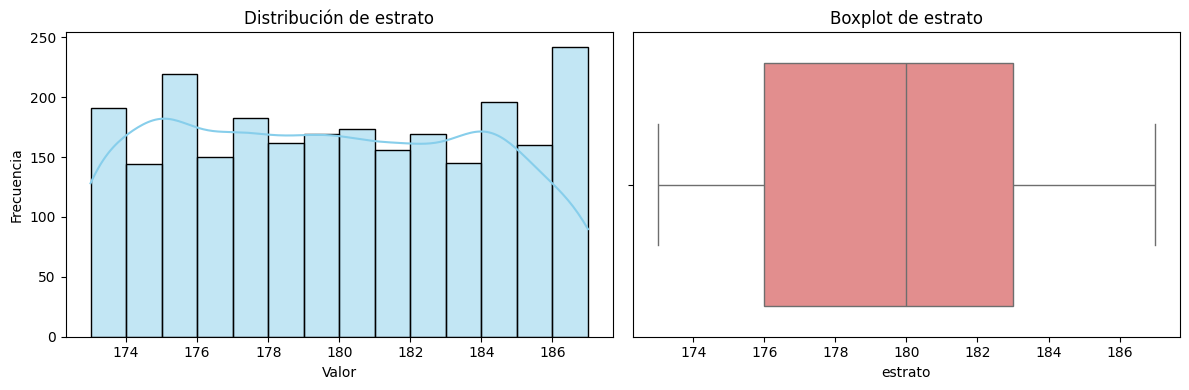

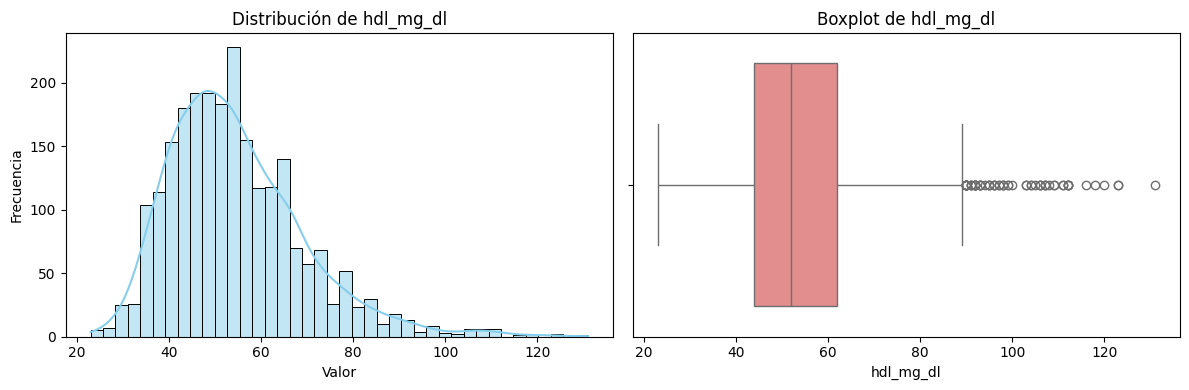

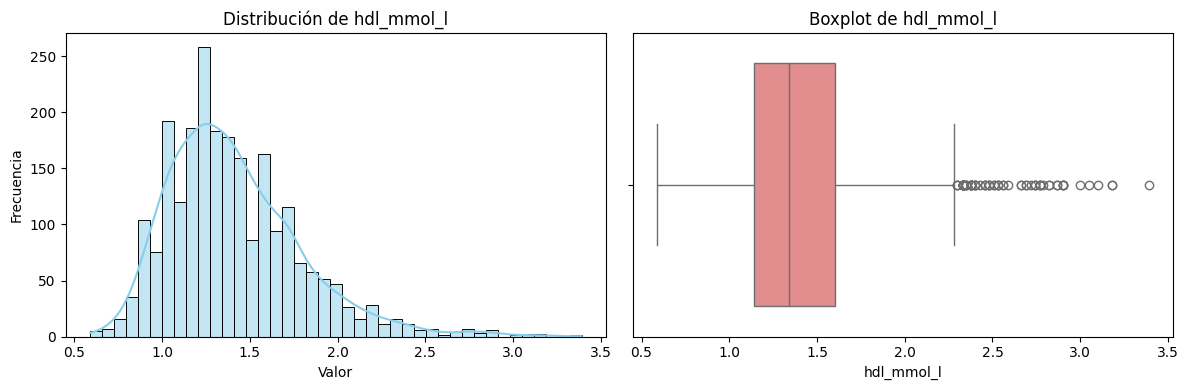

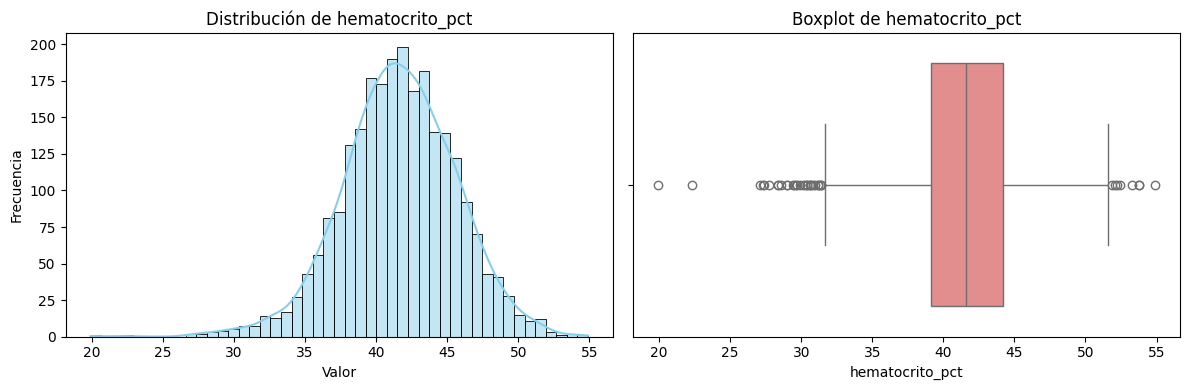

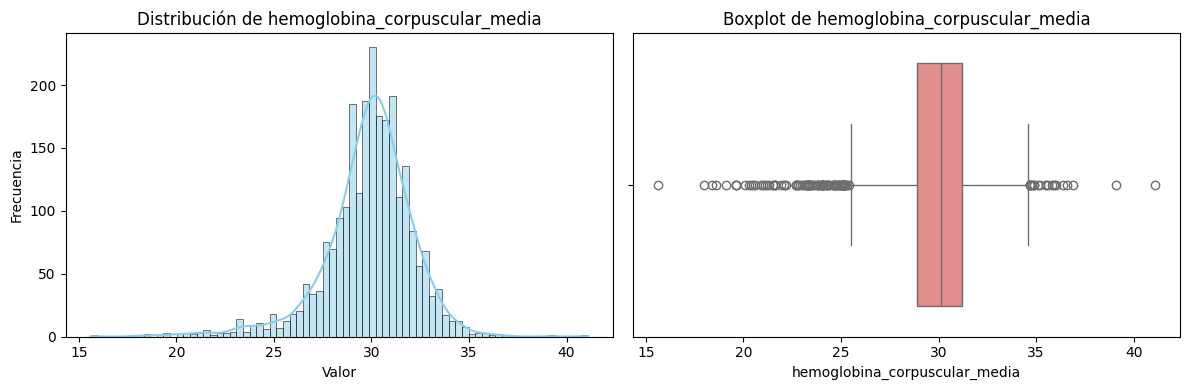

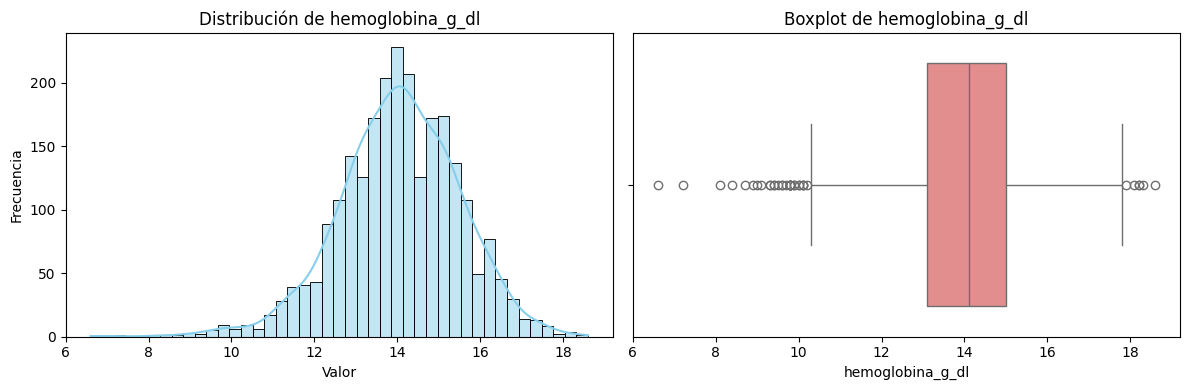

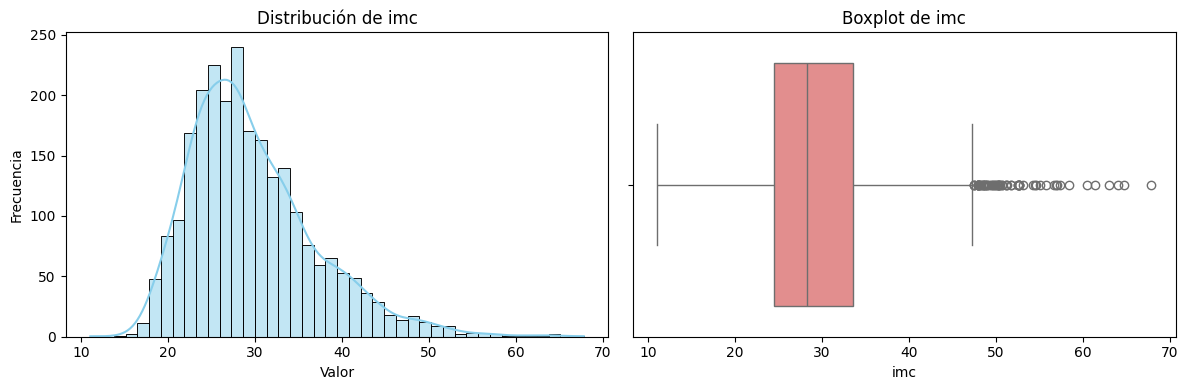

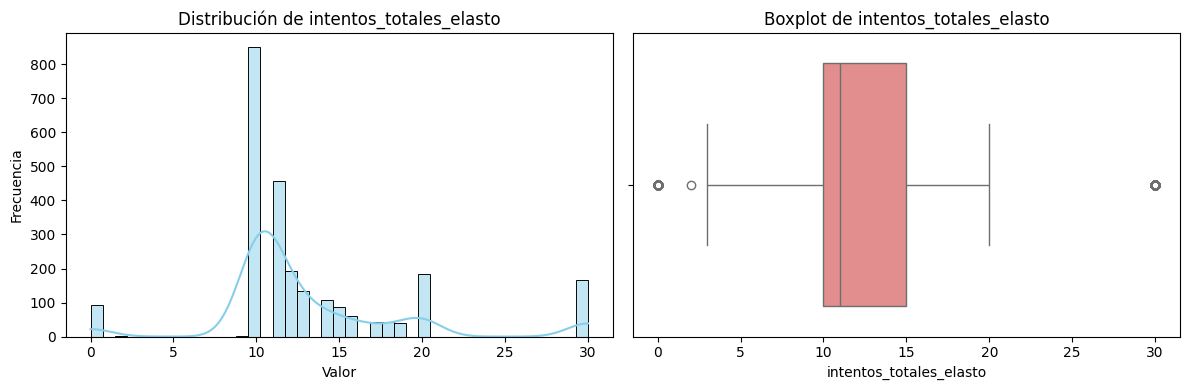

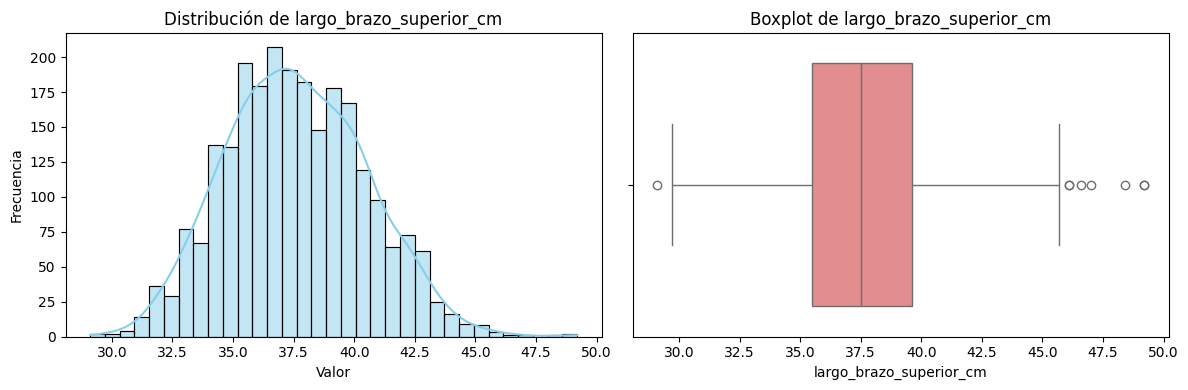

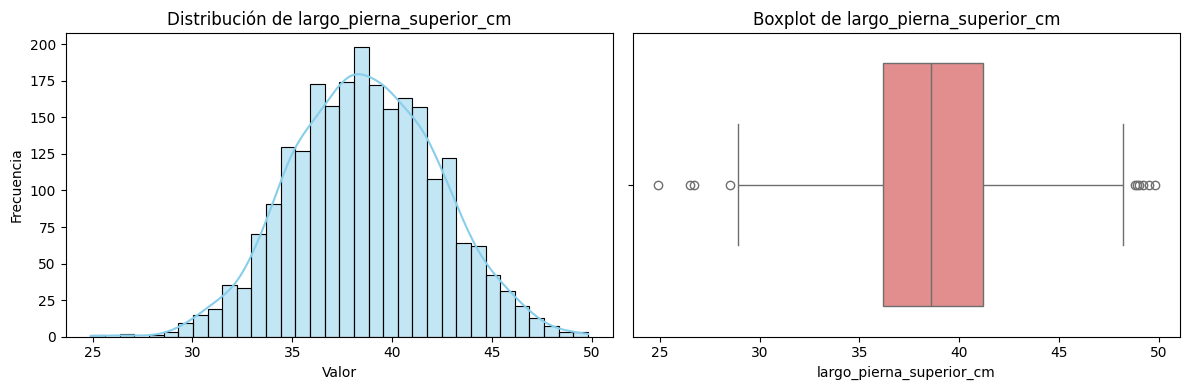

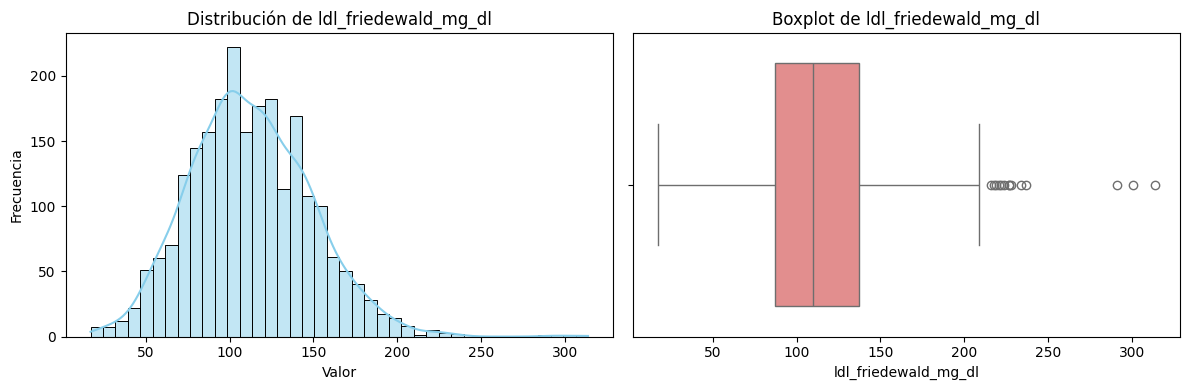

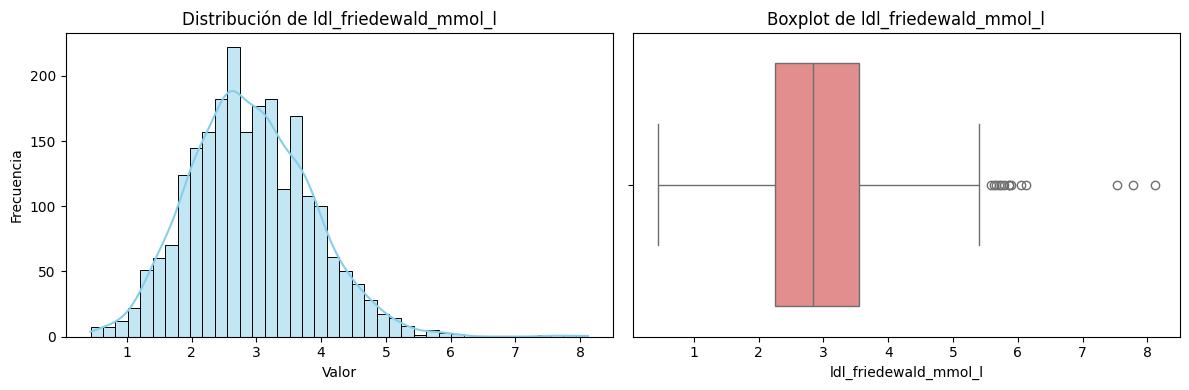

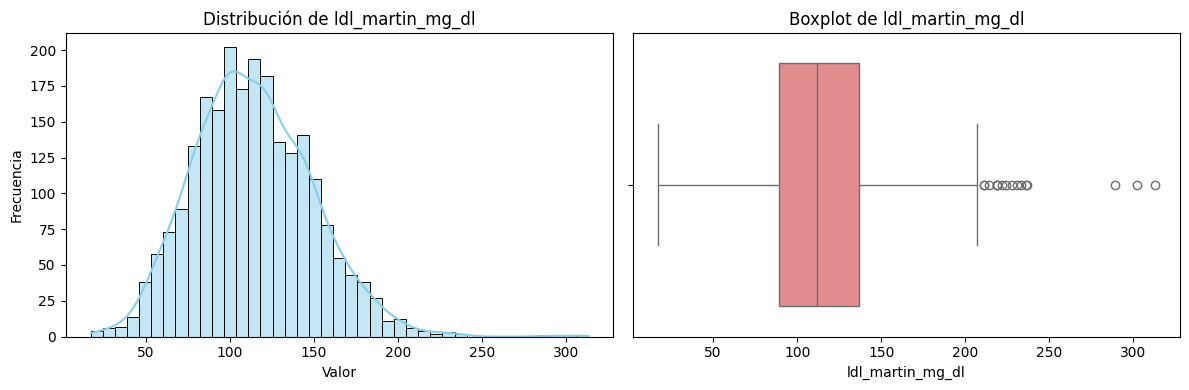

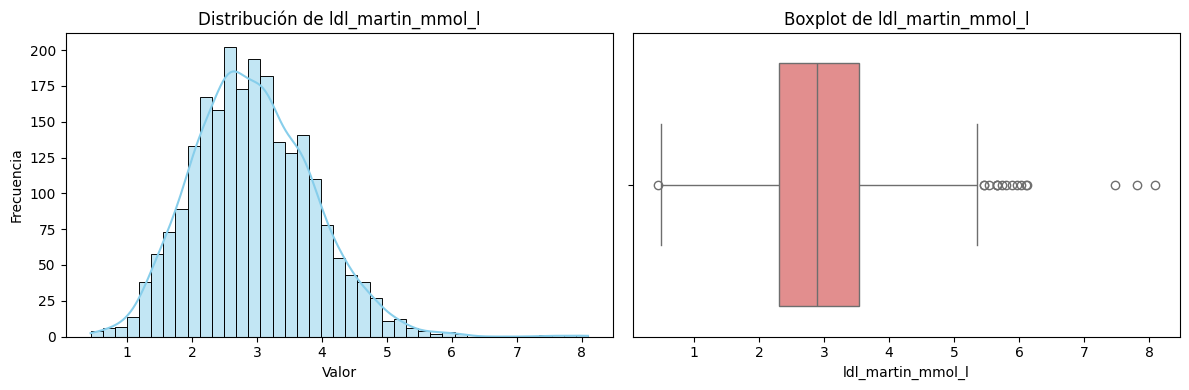

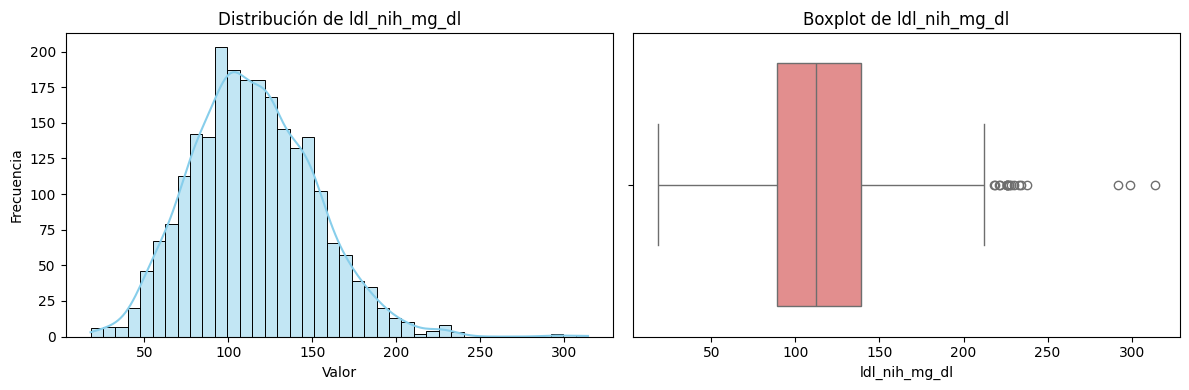

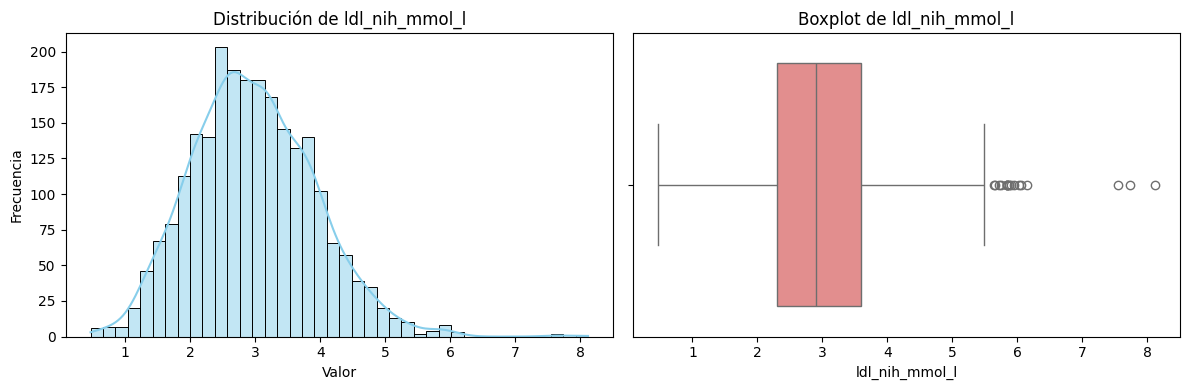

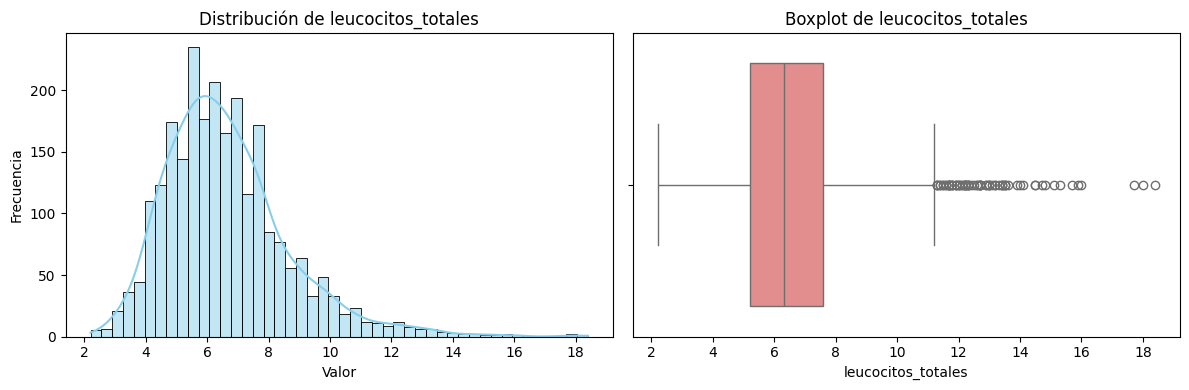

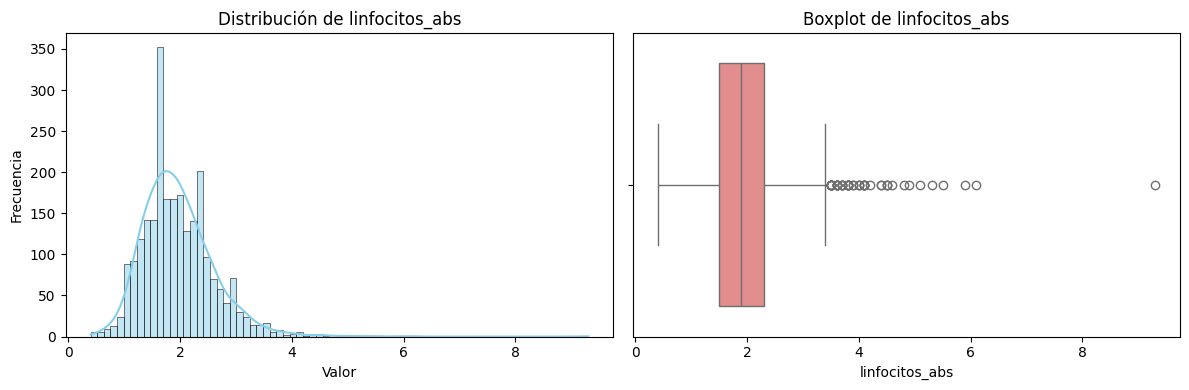

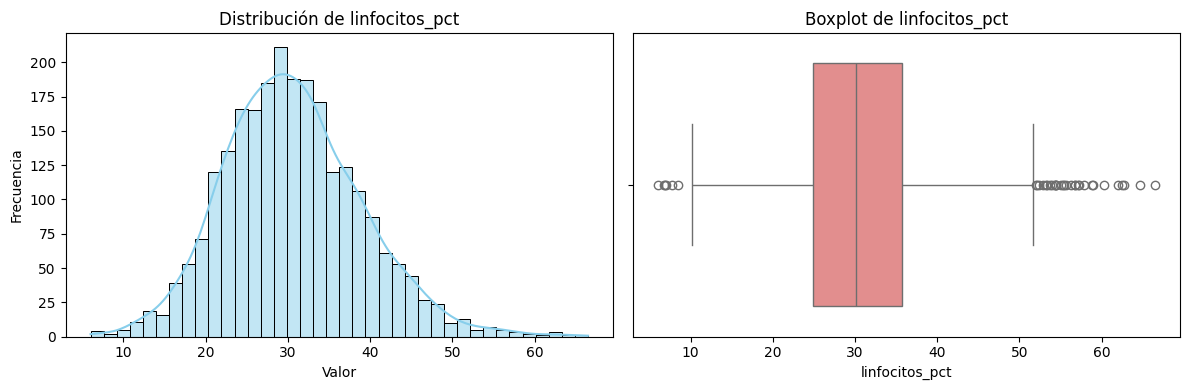

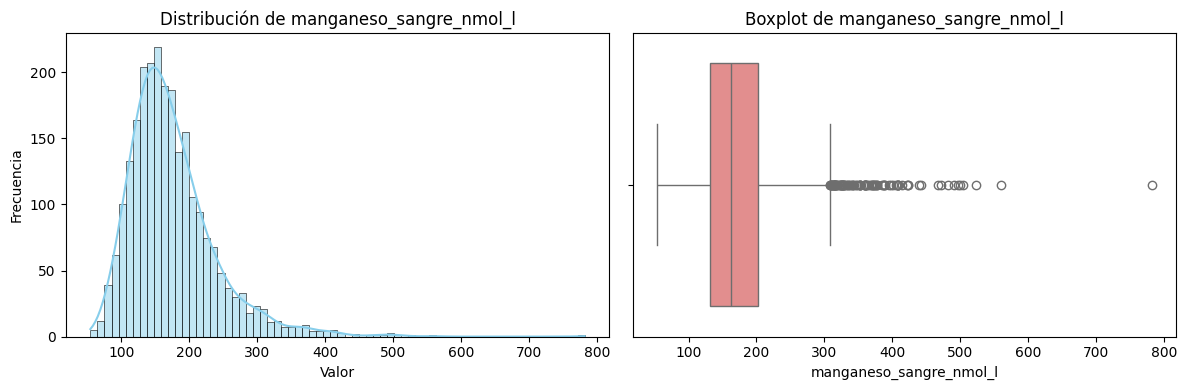

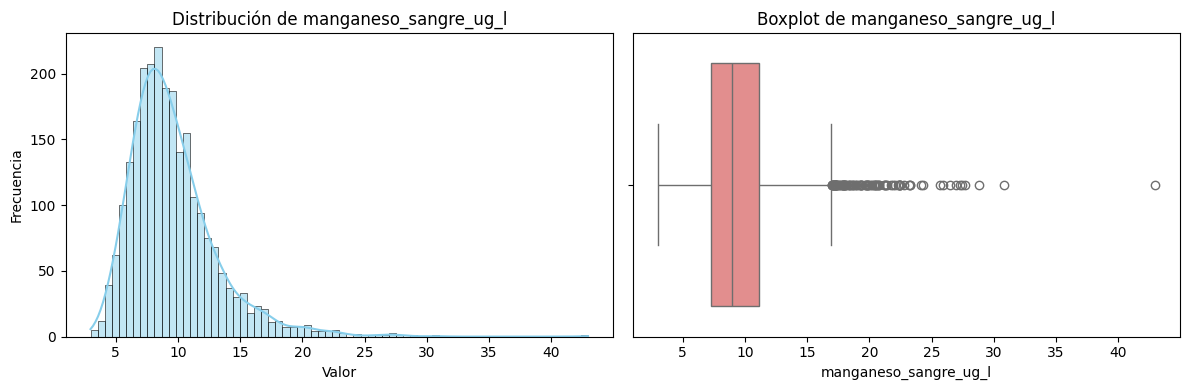

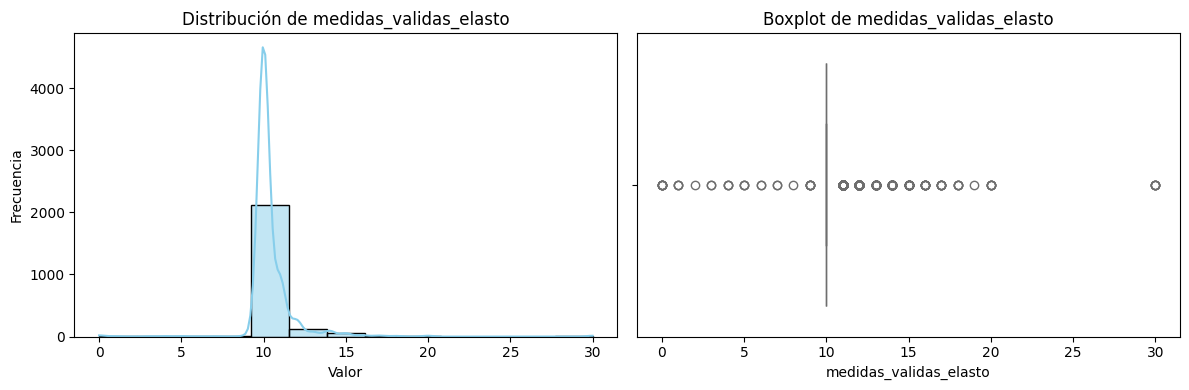

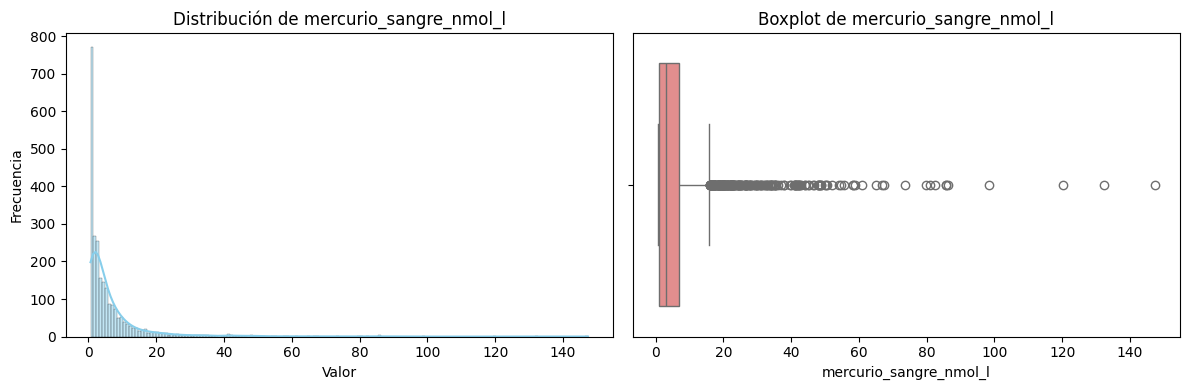

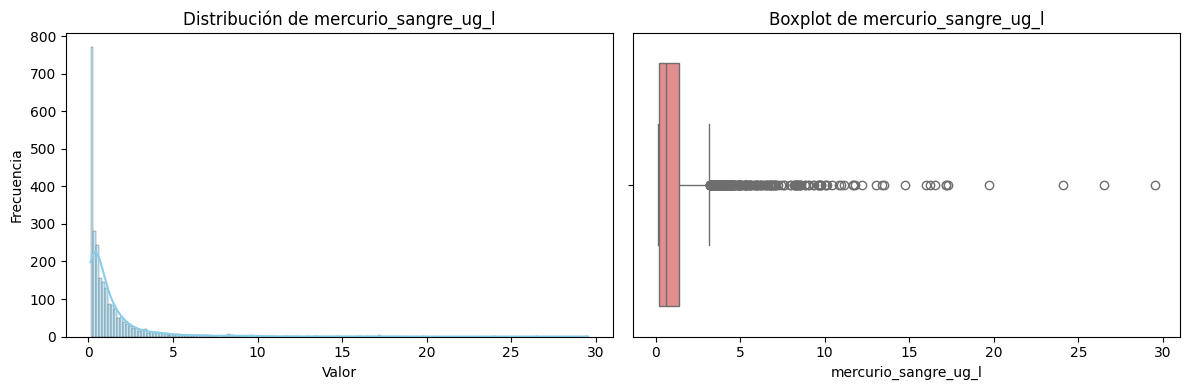

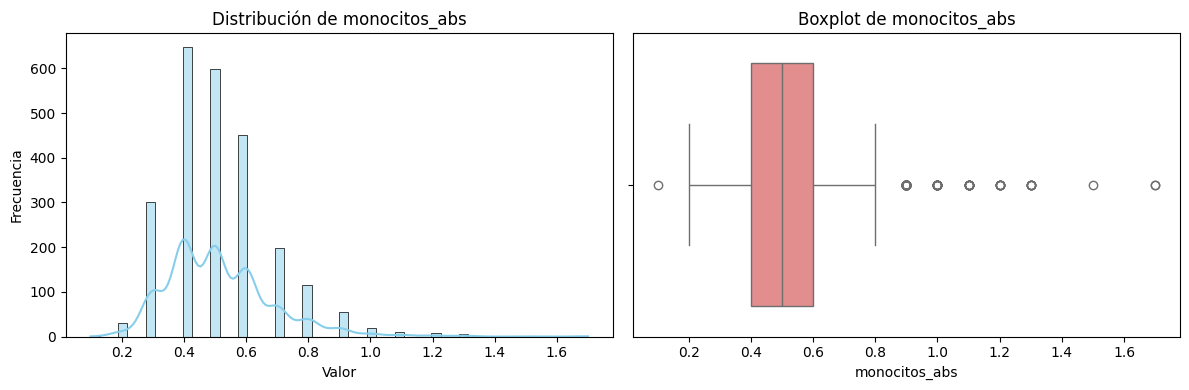

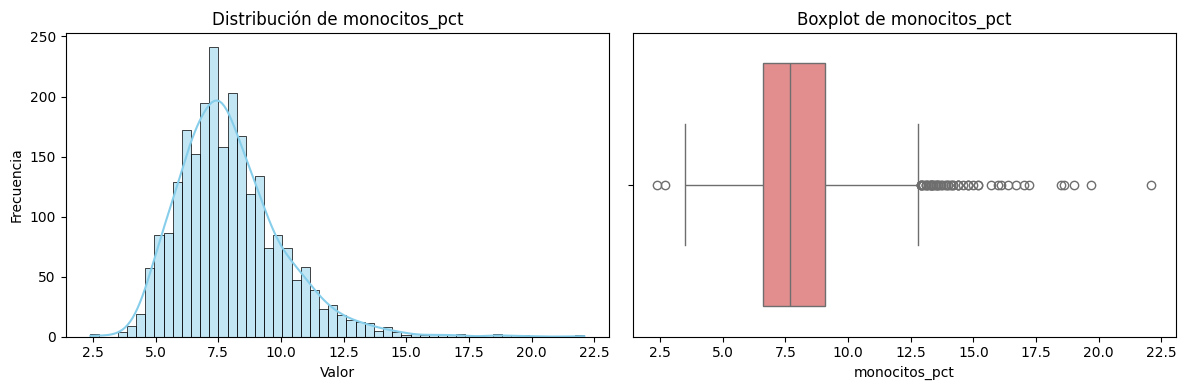

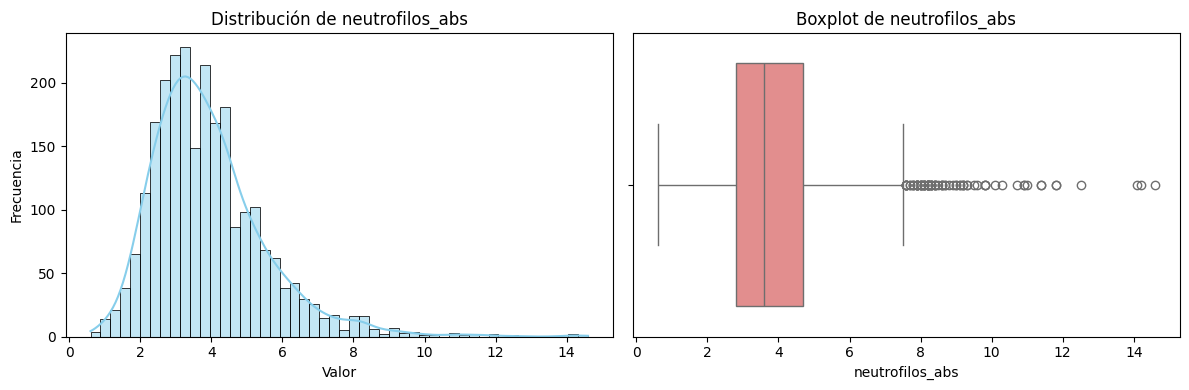

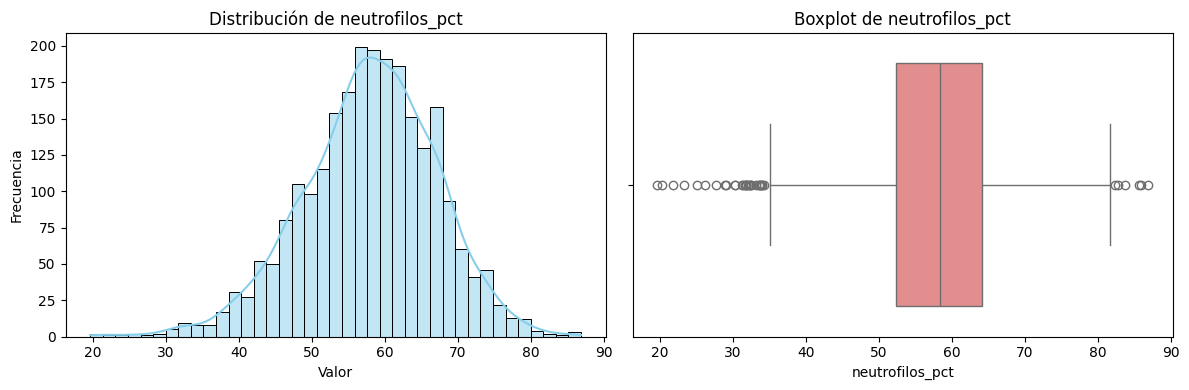

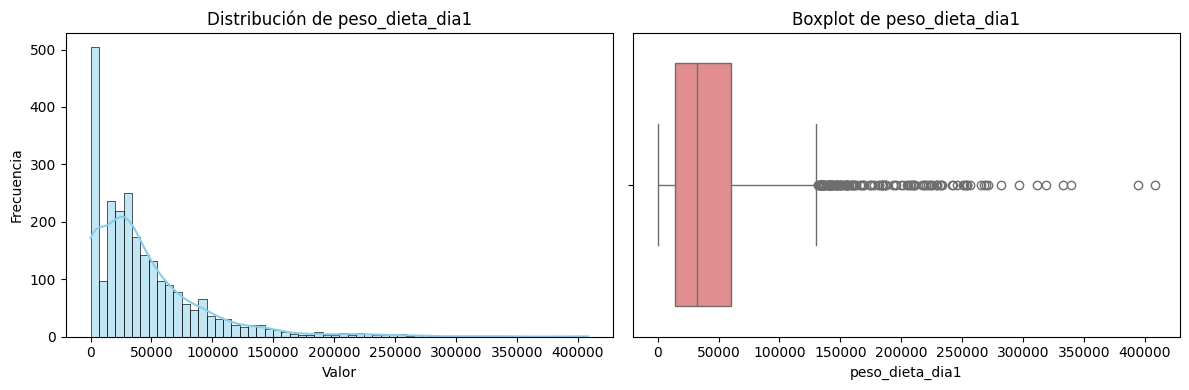

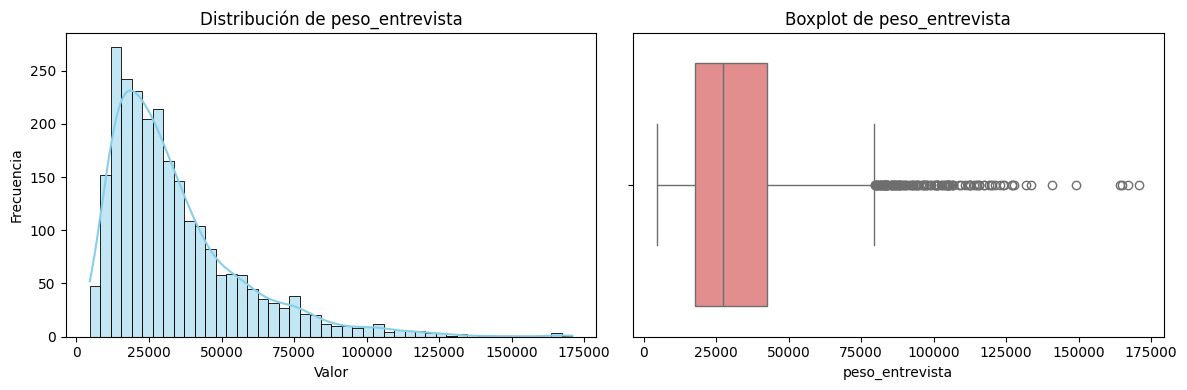

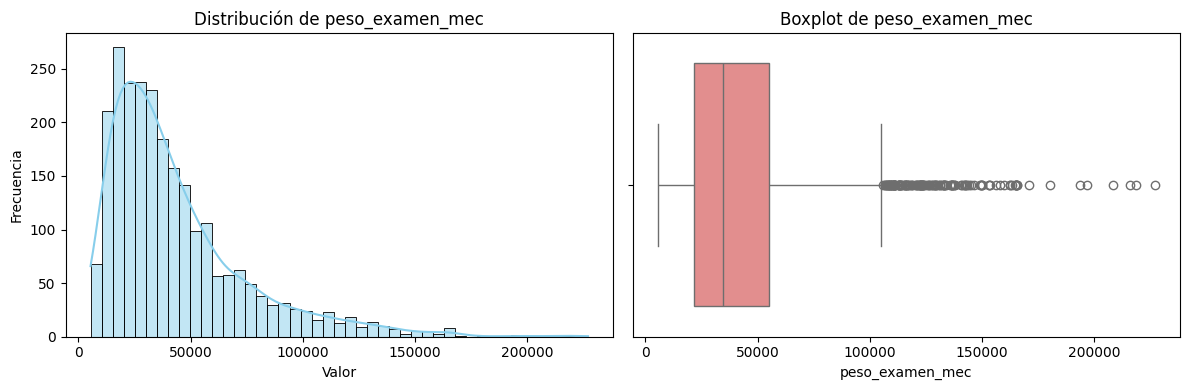

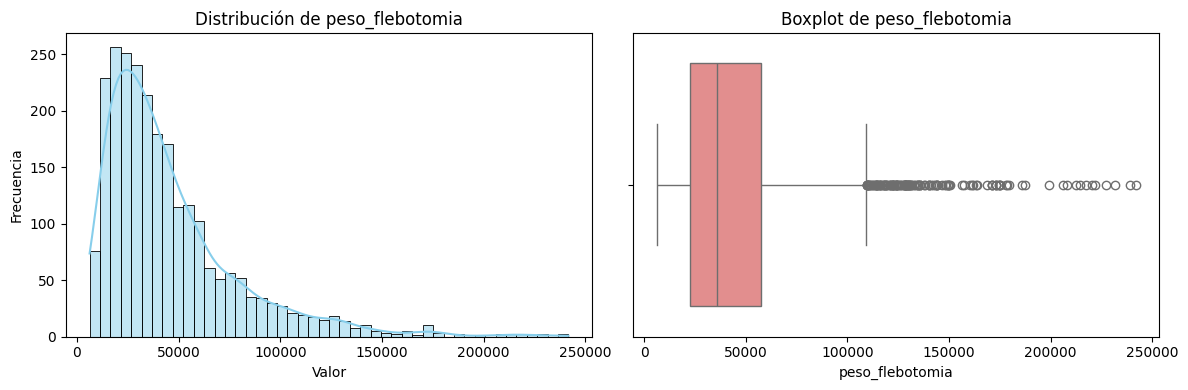

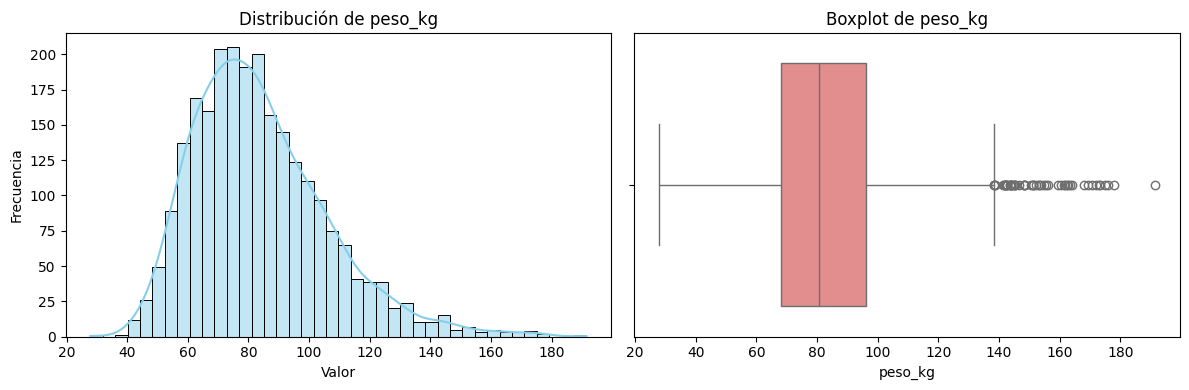

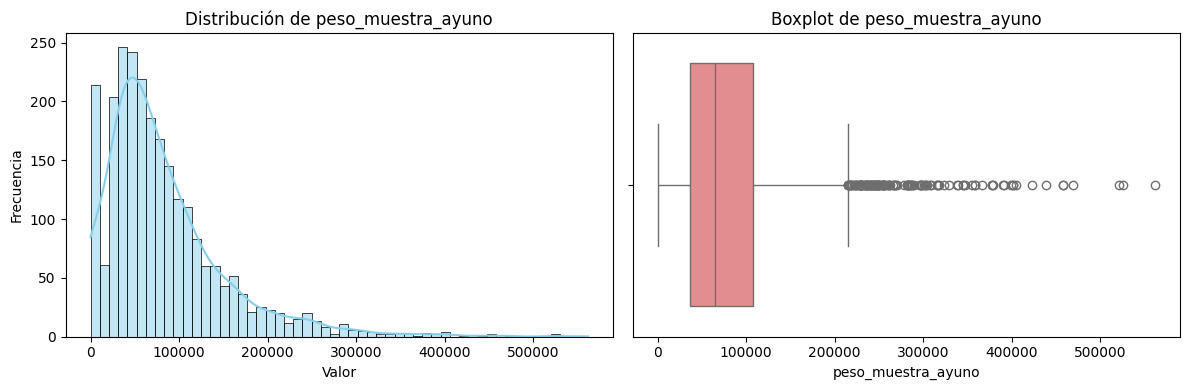

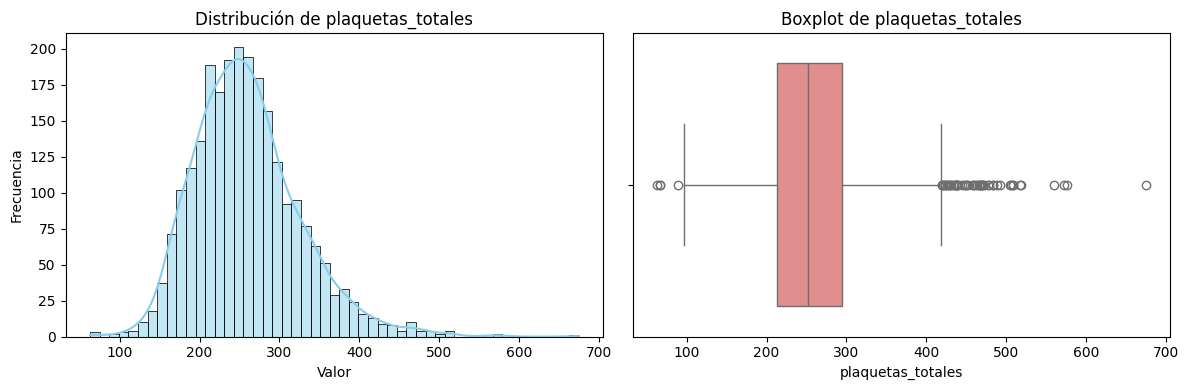

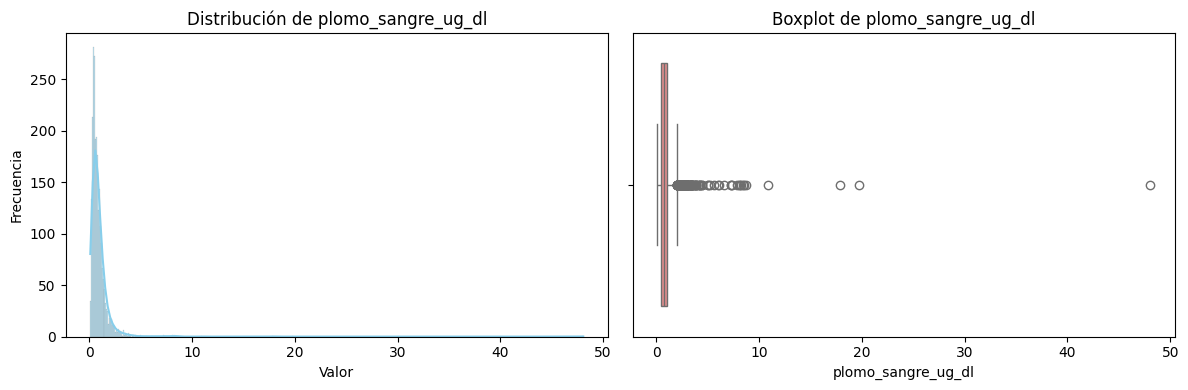

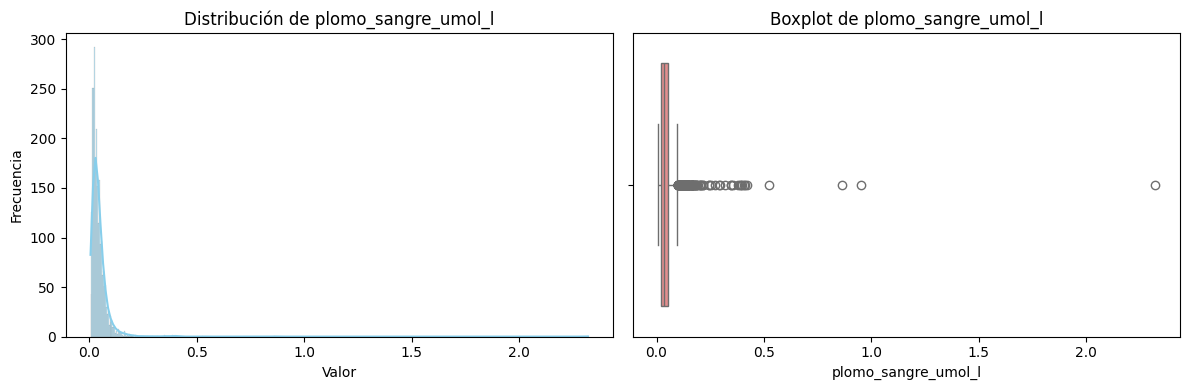

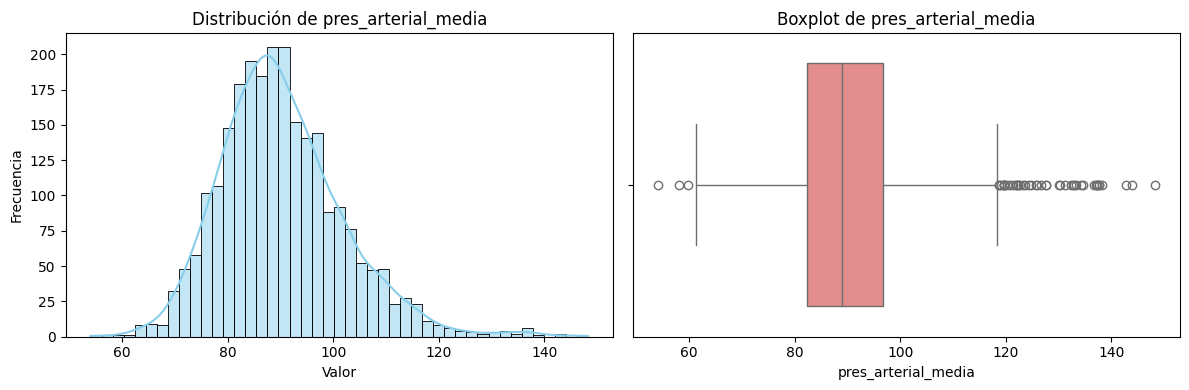

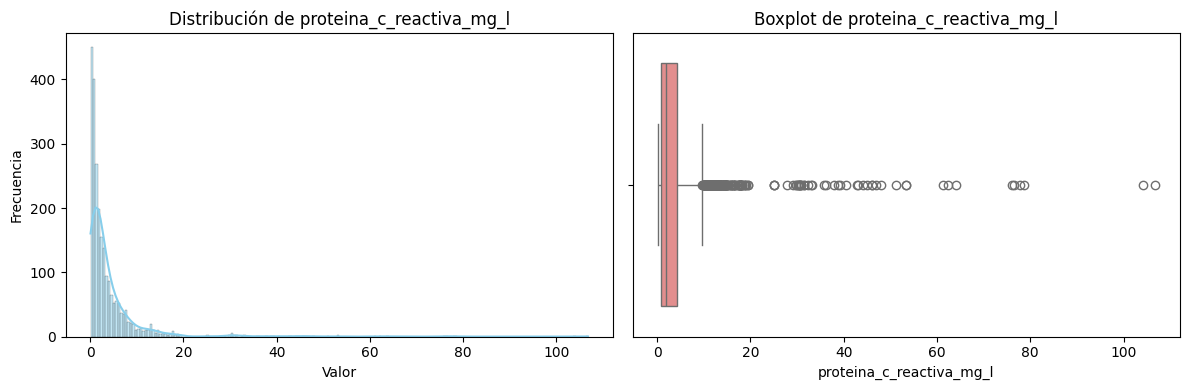

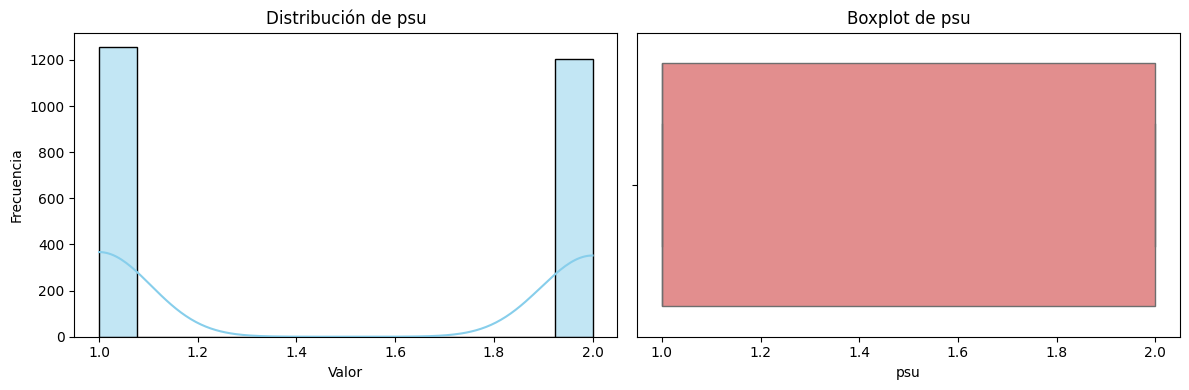

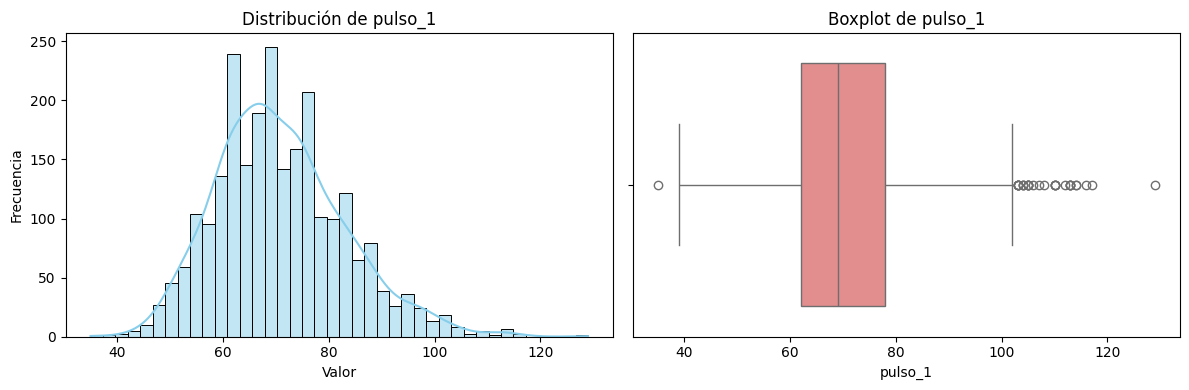

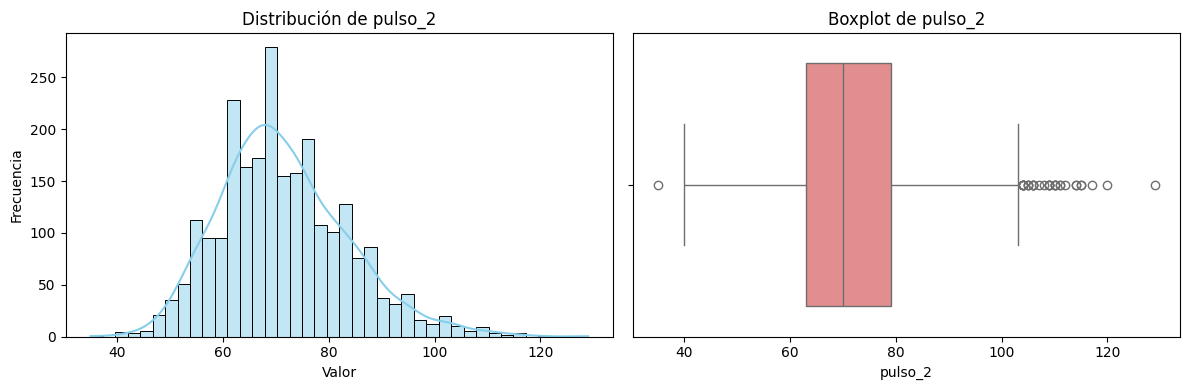

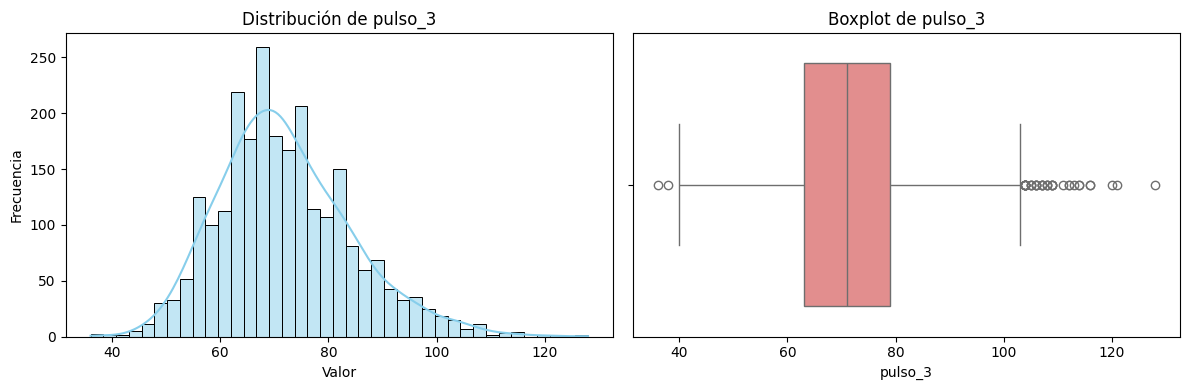

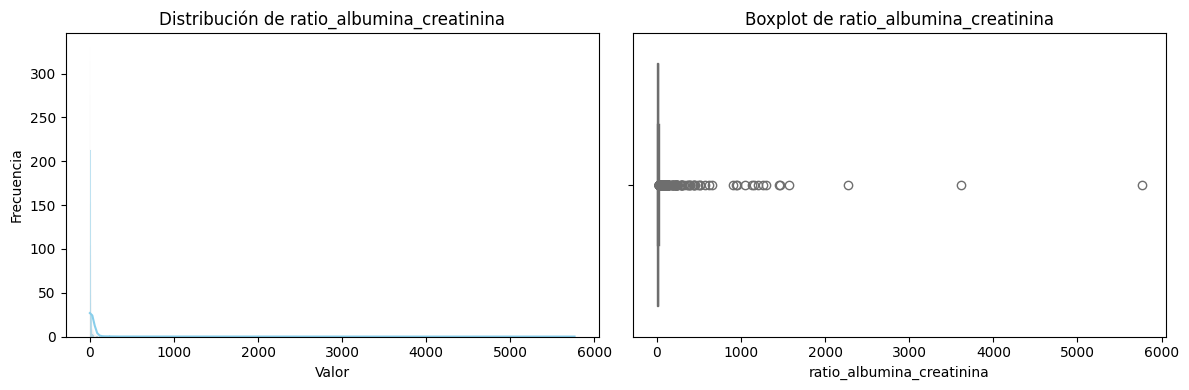

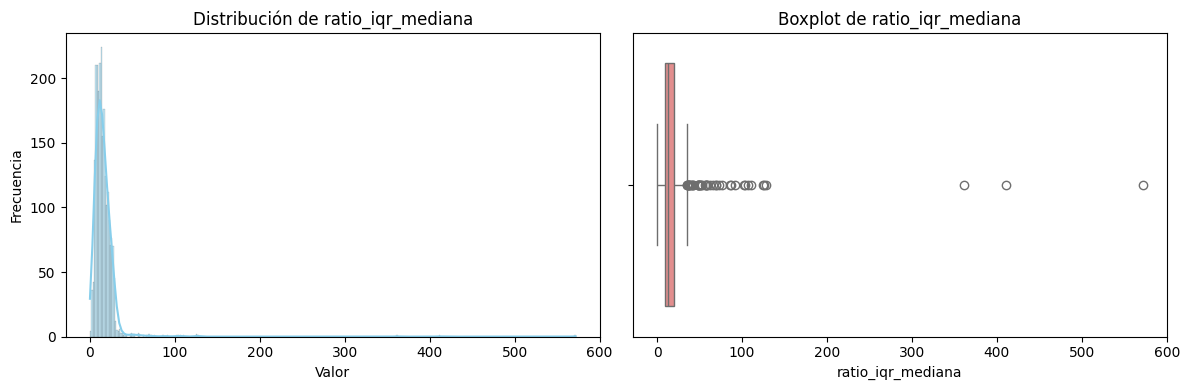

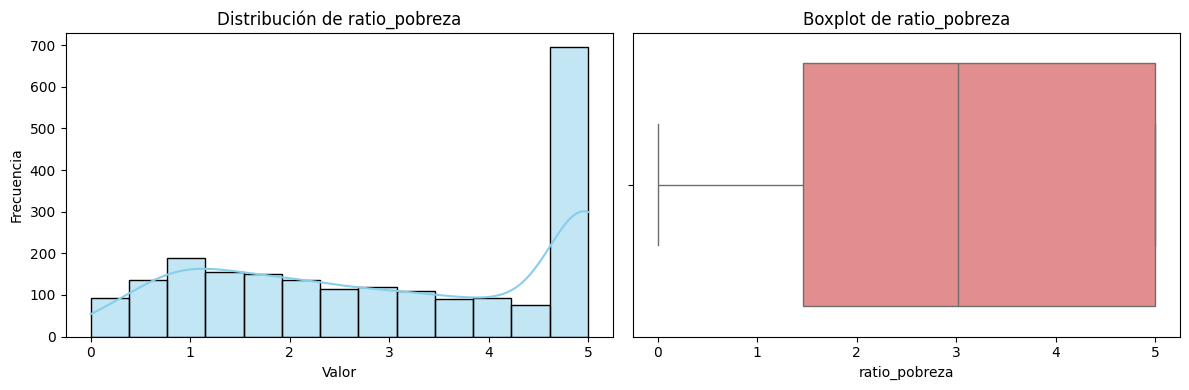

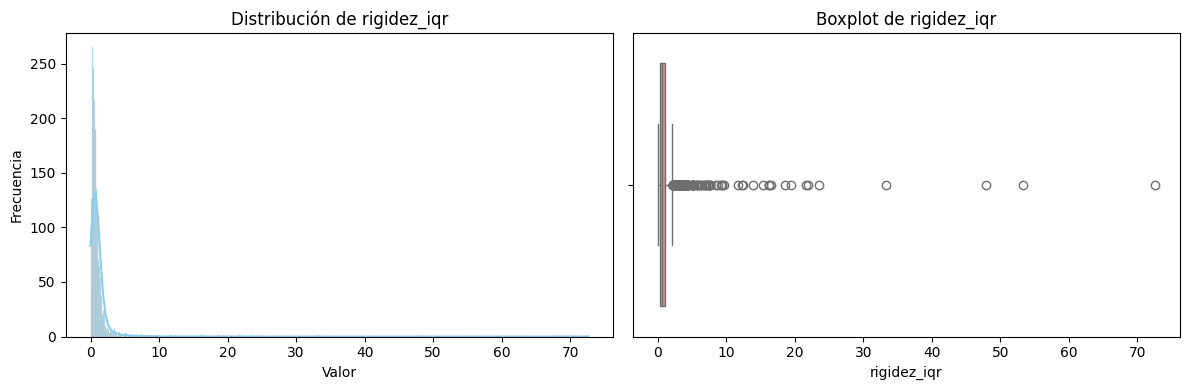

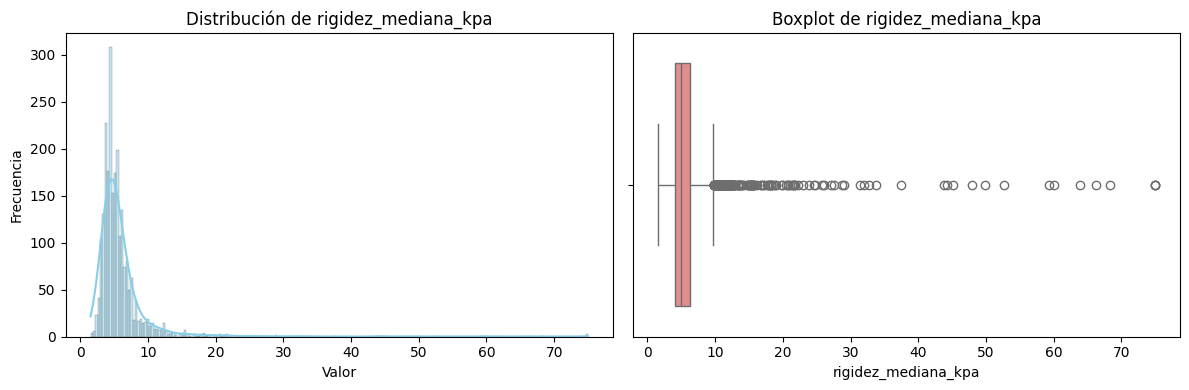

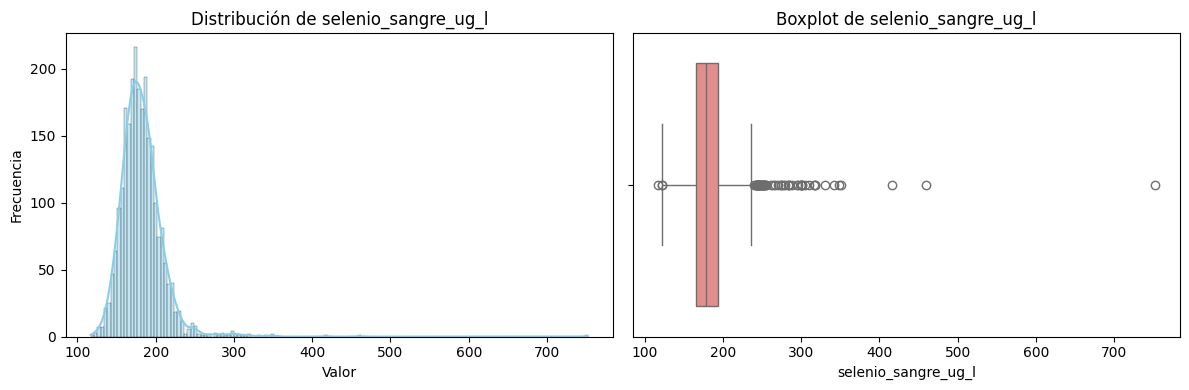

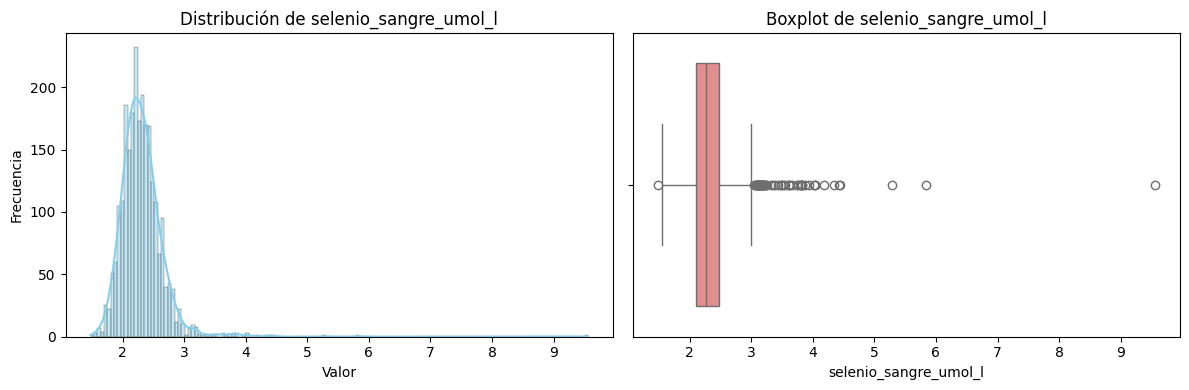

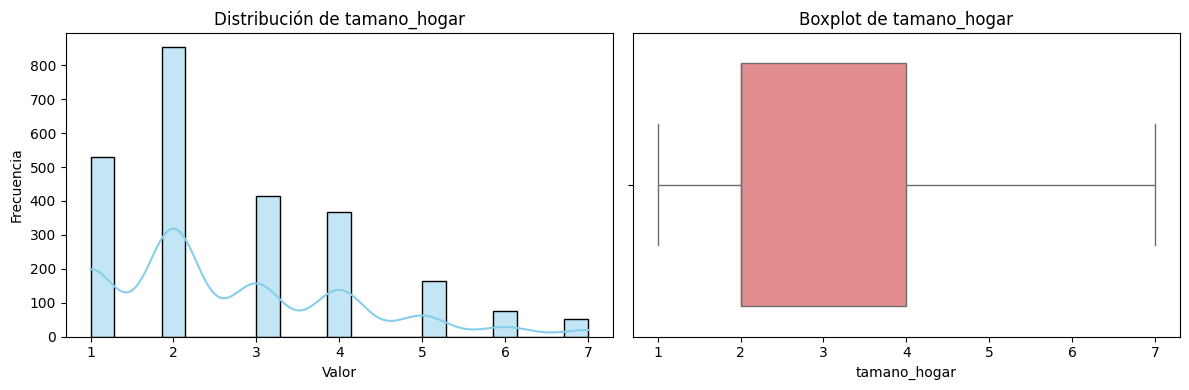

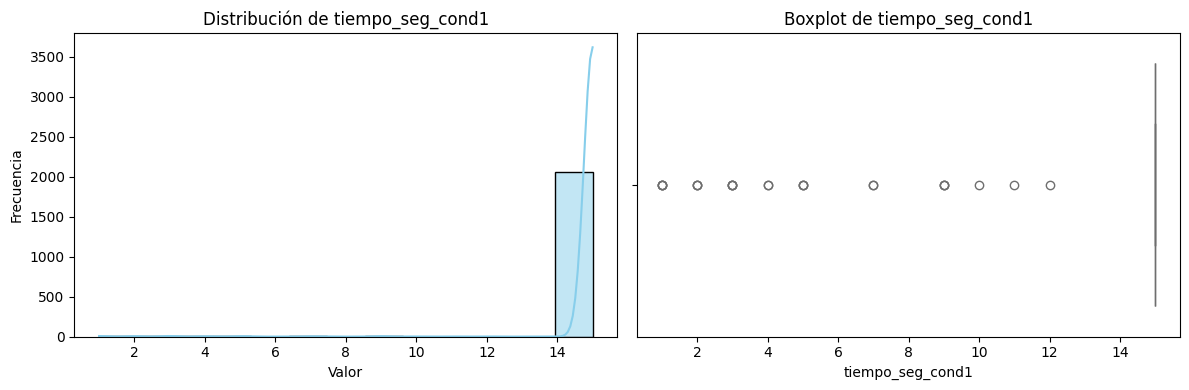

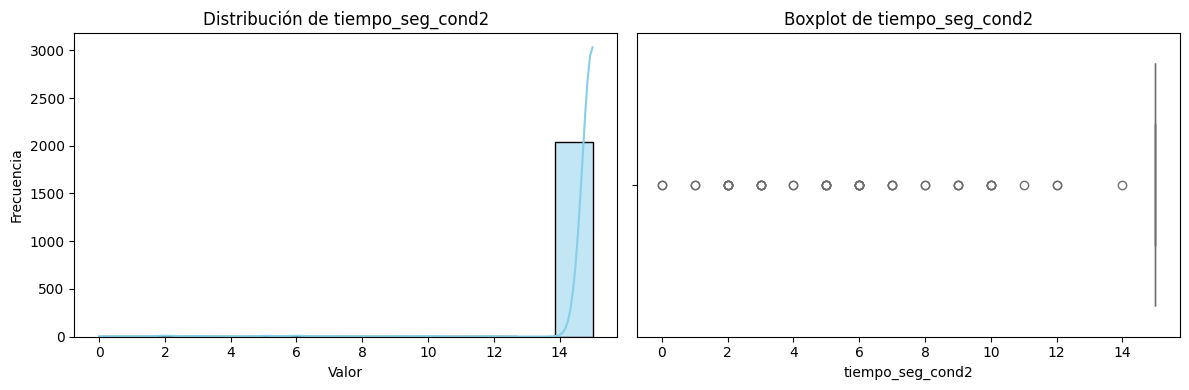

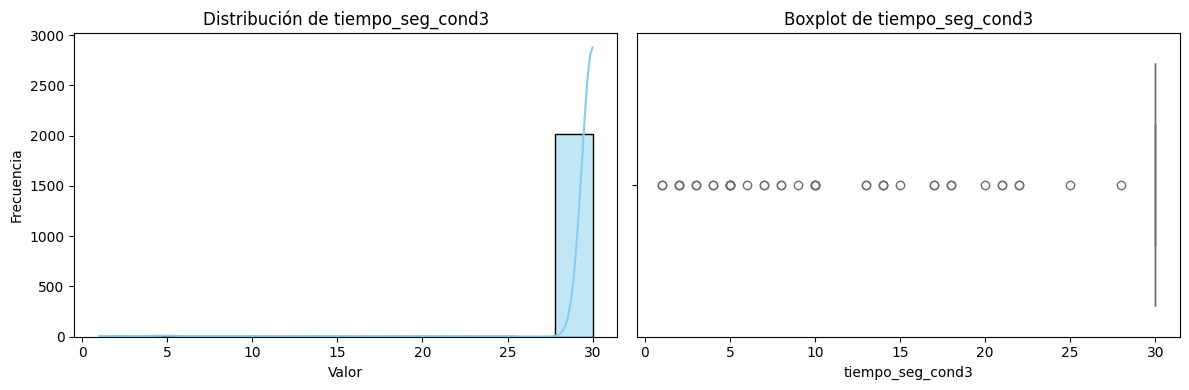

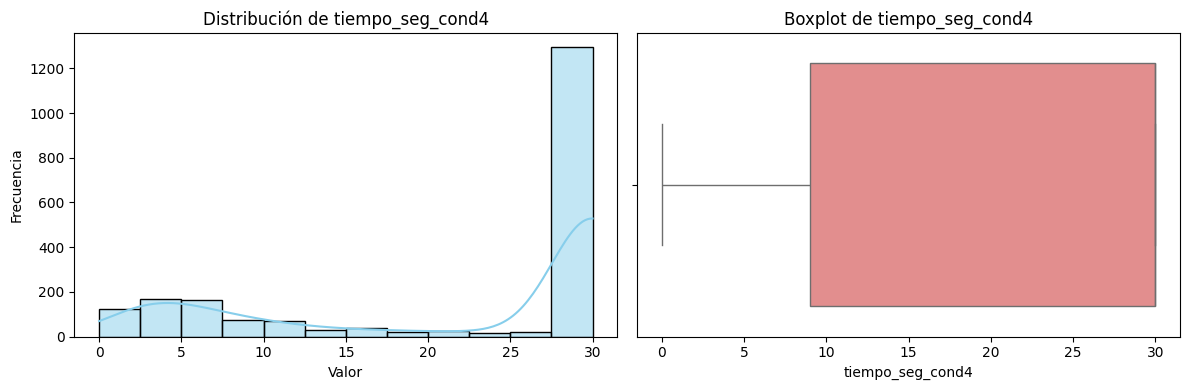

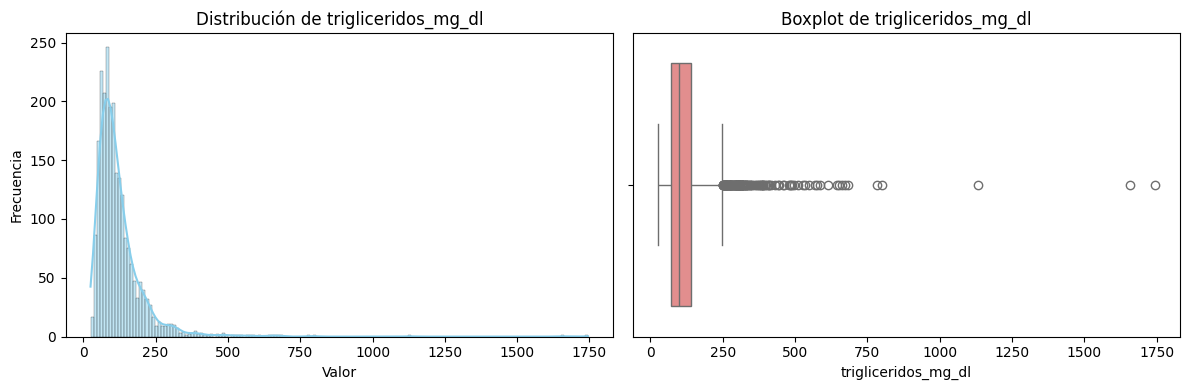

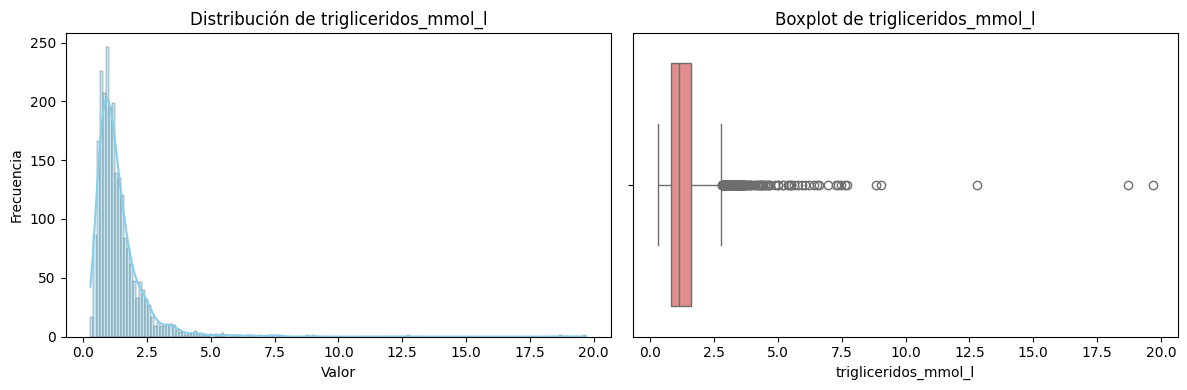

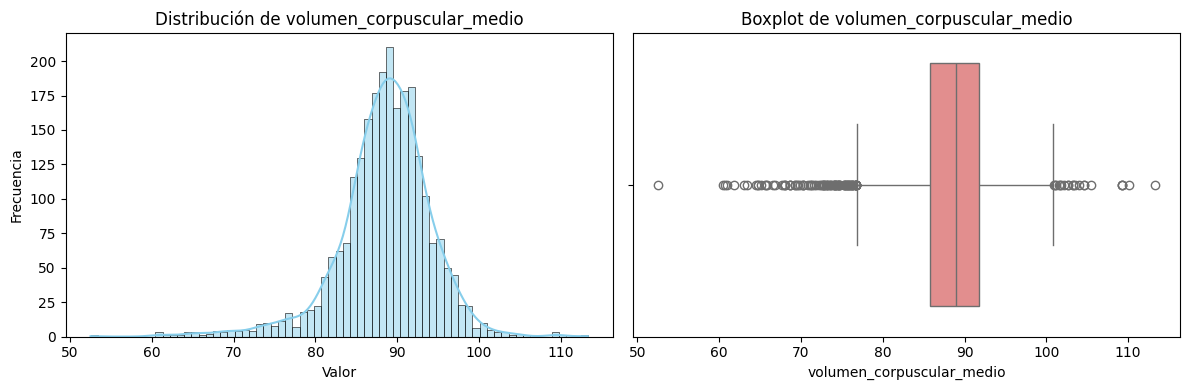

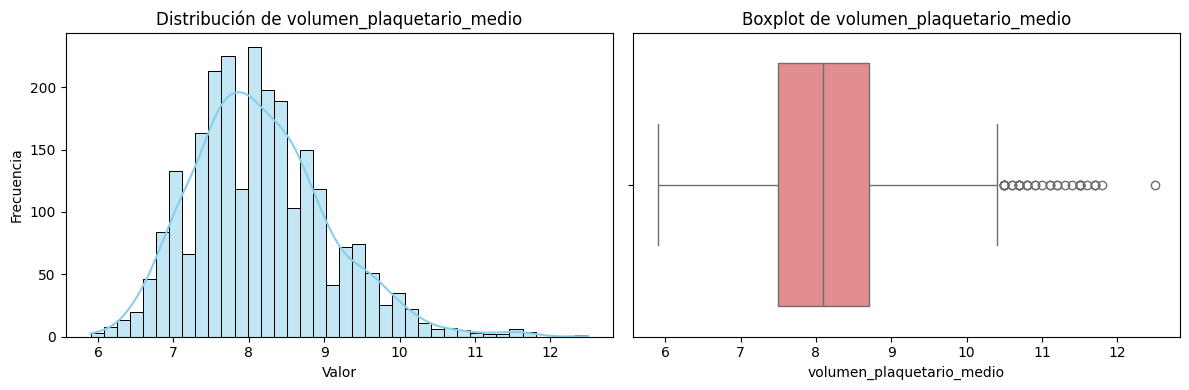

In [108]:
# Definimos el número de variables a visualizar por tanda para no saturar el cuaderno
vars_a_revisar = cols_numericas # Puedes cambiar el rango o usar cols_numericas completa

for col in vars_a_revisar:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma con KDE 
    sns.histplot(df_clean_rows[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot 
    sns.boxplot(x=df_clean_rows[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [109]:
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data < lower_bound) | (data > upper_bound)).sum()

# Creamos un resumen
outlier_summary = []
for col in cols_numericas:
    n_outliers = count_outliers(df[col].dropna())
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variable': col,
        'Num_Outliers': n_outliers,
        'Porcentaje': round(pct_outliers, 2)
    })

df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Num_Outliers', ascending=False)

print("--- Outliers detectados ---")
print(df_outliers.to_string(index=False))
#TODO: Comentar!!

--- Outliers detectados ---
                      Variable  Num_Outliers  Porcentaje
        medidas_validas_elasto           590       23.99
               cant_antiacidos           344       13.99
     ratio_albumina_creatinina           302       12.28
           albumina_orina_mg_l           284       11.55
          albumina_orina_ug_ml           284       11.55
       intentos_totales_elasto           259       10.53
            cadmio_sangre_ug_l           246       10.00
          cadmio_sangre_nmol_l           246       10.00
               eosinofilos_abs           223        9.07
          mercurio_sangre_ug_l           218        8.87
        mercurio_sangre_nmol_l           218        8.87
      proteina_c_reactiva_mg_l           194        7.89
           rigidez_mediana_kpa           183        7.44
                   rigidez_iqr           155        6.30
            plomo_sangre_ug_dl           153        6.22
           plomo_sangre_umol_l           152        6.18
anc

- Hacer análisis de outliers, ¿los outliers coinciden con los pacientes que en la categoría presentan símtomas?

### Distribuciones por Categoría

Como ya sugiere la pregunta anterior, en este subapartado vamos a mirar la relación que existe entre las categorías y las variables numéricas.

Con esto buscamos si existe alguna relación entre ciertas categorías y los valores numéricos, de esta manera podemos comprobar si existe relación entre los outliers y determinadas categorías.

In [110]:
resultados = []

# =========================
# 1. Variables a usar
# =========================
cols_excluir = [
    'ciclo', 'estado', 'gnero', 'etnia_1',
    'etnia_3', 'mes_examen', 'pas_nacimiento'
]

cols_categoricas_filtradas = [col for col in cols_categoricas if col not in cols_excluir]
cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# opcional: limitar numéricas para no sacar demasiadas combinaciones
# cols_numericas = cols_numericas[:10]

# =========================
# 2. Bucle principal
# =========================
for cat_col in cols_categoricas_filtradas:
    for num_col in cols_numericas:
        
        data = df[[cat_col, num_col]].dropna().copy()
        
        # saltar si no hay datos o si la categórica tiene una sola categoría
        if data.empty or data[cat_col].nunique() < 2:
            continue
        
        # =========================
        # 3. Detectar outliers con IQR
        # =========================
        Q1 = data[num_col].quantile(0.25)
        Q3 = data[num_col].quantile(0.75)
        IQR = Q3 - Q1
        
        if IQR == 0:
            continue
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data['outlier'] = ((data[num_col] < lower) | (data[num_col] > upper)).astype(int)
        
        # =========================
        # 4. Resumen por categoría
        # =========================
        resumen = data.groupby(cat_col, observed=False).agg(
            n_total=('outlier', 'count'),
            n_outliers=('outlier', 'sum')
        )
        
        resumen['pct_outliers'] = resumen['n_outliers'] / resumen['n_total'] * 100
        
        # quitar categorías sin observaciones válidas
        resumen = resumen[resumen['n_total'] > 0]
        
        if resumen.empty or resumen['n_outliers'].sum() == 0:
            continue
        
        # =========================
        # 5. Categoría con mayor % de outliers
        # =========================
        top_cat = resumen['pct_outliers'].idxmax()
        
        resultados.append({
            'variable_categorica': cat_col,
            'variable_numerica': num_col,
            'categoria_mas_outliers': top_cat,
            'n_total_categoria': int(resumen.loc[top_cat, 'n_total']),
            'n_outliers_categoria': int(resumen.loc[top_cat, 'n_outliers']),
            'pct_outliers_categoria': round(resumen.loc[top_cat, 'pct_outliers'], 2)
        })

# =========================
# 6. DataFrame final
# =========================
df_outliers = pd.DataFrame(resultados)

# ordenar por porcentaje, no por número absoluto
df_outliers = df_outliers.sort_values(
    by='pct_outliers_categoria',
    ascending=False
).reset_index(drop=True)

# mostrar los 20 más llamativos
display(df_outliers)

,variable_categorica,variable_numerica,categoria_mas_outliers,n_total_categoria,n_outliers_categoria,pct_outliers_categoria
0,tipo_sonda_elasto,intentos_totales_elasto,b'',93,93,100.00
1,tamano_manguito_pa,peso_entrevista,2.0,4,2,50.00
2,tamano_manguito_pa,peso_examen_mec,2.0,4,2,50.00
3,tamano_manguito_pa,peso_flebotomia,2.0,4,2,50.00
4,estado_elastografia,rigidez_iqr,0,127,51,40.16
...,...,...,...,...,...,...
1237,toma_suplementos,altura_cm,0,743,1,0.13
1238,estado_elastografia,altura_cm,1,2304,3,0.13
1239,caidas,altura_cm,0,2328,3,0.13
1240,convulsiones,altura_cm,0,2324,3,0.13


In [111]:
# # =========================
# # 1. Variables a usar
# # =========================
# cols_excluir = [
#     'ciclo', 'estado', 'gnero', 'etnia_1',
#     'etnia_3', 'mes_examen', 'pas_nacimiento'
# ]

# cols_categoricas_filtradas = [col for col in cols_categoricas if col not in cols_excluir]
# cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# print(f"Número de variables categóricas usadas: {len(cols_categoricas_filtradas)}")
# print(f"Número de variables numéricas usadas: {len(cols_numericas)}")

# # =========================
# # 2. Carpeta de salida
# # =========================
# carpeta_salida = "boxplots_numericas_por_categoria"
# os.makedirs(carpeta_salida, exist_ok=True)

# # =========================
# # 3. Parámetros de visualización
# # =========================
# n_cols = 3   # nº de gráficos por fila
# n_cats = len(cols_categoricas_filtradas)
# n_rows = math.ceil(n_cats / n_cols)

# # =========================
# # 4. Crear una imagen por variable numérica
# # =========================
# for num_col in cols_numericas:
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
#     axes = axes.flatten()
    
#     for i, cat_col in enumerate(cols_categoricas_filtradas):
#         ax = axes[i]
        
#         data_plot = df[[cat_col, num_col]].dropna().copy()
        
#         if data_plot.empty or data_plot[cat_col].nunique() < 2:
#             ax.set_visible(False)
#             continue
        
#         sns.boxplot(
#             data=data_plot,
#             x=cat_col,
#             y=num_col,
#             ax=ax
#         )
        
#         ax.set_title(f"{num_col} según {cat_col}", fontsize=11)
#         ax.set_xlabel(cat_col)
#         ax.set_ylabel(num_col)
#         ax.tick_params(axis='x', rotation=45)
    
#     # Ocultar ejes vacíos
#     for j in range(len(cols_categoricas_filtradas), len(axes)):
#         axes[j].set_visible(False)
    
#     plt.tight_layout()
    
#     # Guardar imagen
#     ruta_salida = os.path.join(carpeta_salida, f"{num_col}.png")
#     plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
#     # plt.show()
#     plt.close(fig)

# print(f"Imágenes guardadas en la carpeta: {carpeta_salida}")

## Correlaciones

--- Estadísticos Principales ---


,edad_an,tamano_hogar,peso_entrevista,peso_examen_mec,estrato,psu,ratio_pobreza,peso_dieta_dia1,cant_suplementos,cant_antiacidos,...,plomo_sangre_umol_l,cadmio_sangre_ug_l,cadmio_sangre_nmol_l,mercurio_sangre_ug_l,mercurio_sangre_nmol_l,selenio_sangre_ug_l,selenio_sangre_umol_l,manganeso_sangre_ug_l,manganeso_sangre_nmol_l,pres_arterial_media
count,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2.158000e+03,2.459000e+03,1.955000e+03,1.950000e+03,...,2456.000000,2456.00000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2456.000000,2459.000000
mean,48.746645,2.681985,33842.723132,43467.540891,179.654738,1.489630,3.026057e+00,4.435704e+04,1.876215e+00,2.220513e-01,...,0.045202,0.41934,3.730868,1.265314,6.314515,181.965635,2.310888,9.594357,174.636515,90.228386
std,14.383382,1.462762,22818.844316,31007.767272,4.239853,0.499994,1.692692e+00,4.752300e+04,3.968146e+00,1.785991e+00,...,0.065593,0.55330,4.922719,2.098682,10.472120,28.478659,0.361721,3.521368,64.096013,11.644384
min,20.000000,1.000000,4584.463196,5424.587296,173.000000,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,0.005000,0.04600,0.409000,0.120000,0.600000,116.700000,1.480000,2.980000,54.240000,54.000000
25%,36.000000,2.000000,17794.504129,21612.103335,176.000000,1.000000,1.460000e+00,1.406977e+04,5.397605e-79,5.397605e-79,...,0.022000,0.15900,1.415000,0.230000,1.150000,165.400000,2.100000,7.260000,132.150000,82.300000
50%,51.000000,2.000000,27391.039950,34519.232893,180.000000,1.000000,3.020000e+00,3.207934e+04,1.000000e+00,5.397605e-79,...,0.033000,0.24950,2.219500,0.600000,2.990000,178.900000,2.270000,8.950000,162.910000,89.000000
75%,62.000000,4.000000,42527.079160,55088.068391,183.000000,2.000000,5.000000e+00,6.065491e+04,3.000000e+00,5.397605e-79,...,0.052000,0.43900,3.906000,1.412500,7.052500,194.200000,2.470000,11.135000,202.680000,96.700000
max,69.000000,7.000000,170968.343177,227108.296958,187.000000,2.000000,5.000000e+00,4.085058e+05,9.900000e+01,7.700000e+01,...,2.322000,7.68400,68.365000,29.540000,147.400000,752.400000,9.560000,42.950000,781.780000,148.300000


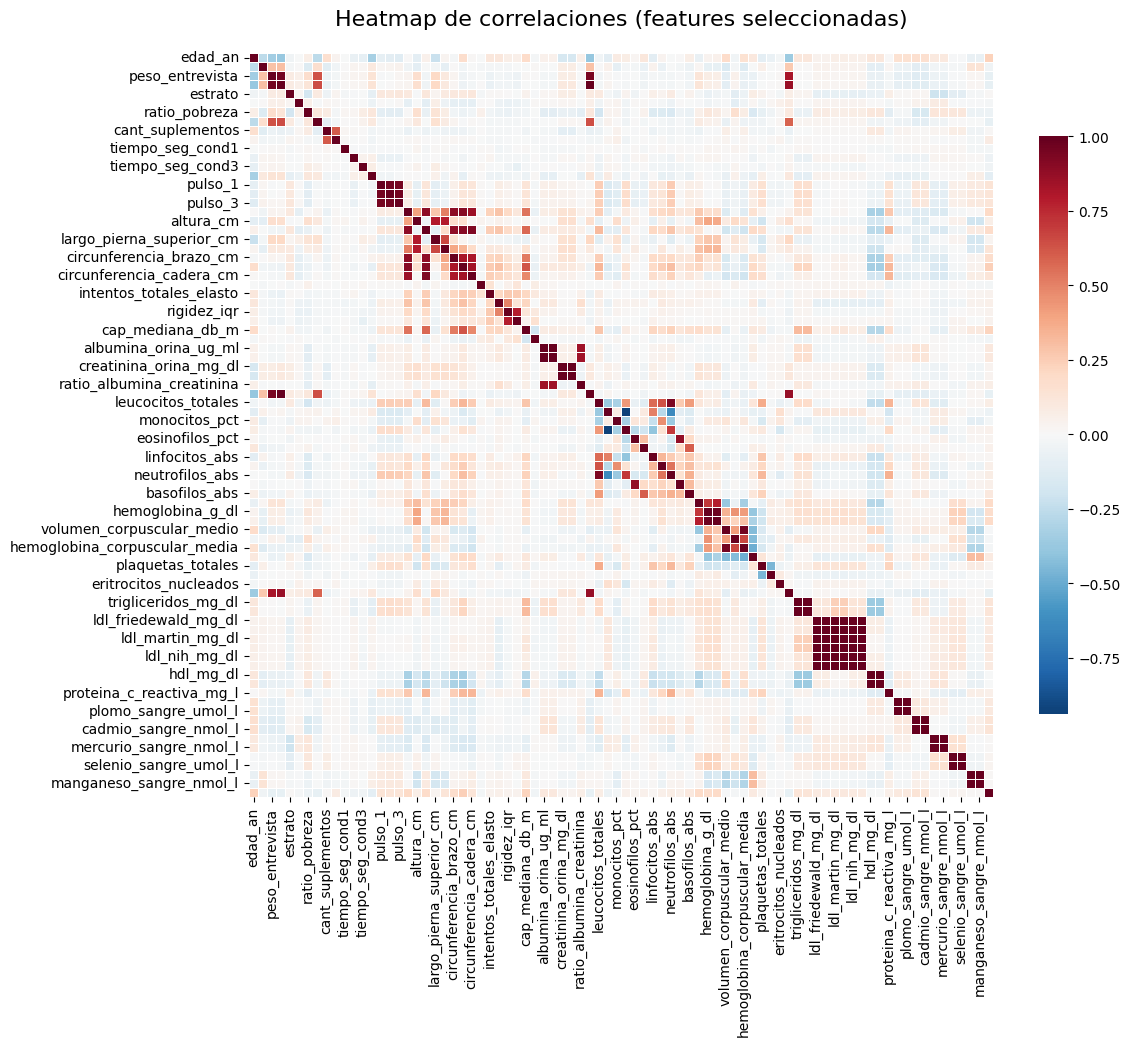

In [112]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df[cols_numericas].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()
#TODO: Comentar!!

- Analizar las correlaciones entre variables.
- Eliminar redundancias y mirar posibles agrupaciones

Analizamos las redundancias en variables, por conversion de unidades u otros motivos.

En el dataset original contamos con múltiples variables que representan exactamente el mismo indicador de salud: el **colesterol LDL**. Las diferencias entre ellas radican únicamente en la fórmula matemática utilizada para su estimación (Friedewald, Martin, NIH) y en su unidad de medida (mg/dL vs mmol/L).

Dado que estas variables están **altamente correlacionadas**, mantenerlas todas introduciría un problema de **multicolinealidad**.

**Decisión tomada:**
Para evitar estos problemas, hemos conservado una única representación: `ldl_martin_mmol_l`. Se eligió la fórmula de **Martin** por ser clínicamente más moderna y precisa (especialmente en niveles bajos de LDL o triglicéridos altos) y se optó por la unidad **mmol/L** (Sistema Internacional). Las demás variantes redundantes han sido eliminadas del conjunto de datos.

Columnas encontradas: ['ldl_friedewald_mg_dl', 'ldl_friedewald_mmol_l', 'ldl_martin_mg_dl', 'ldl_martin_mmol_l', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l']


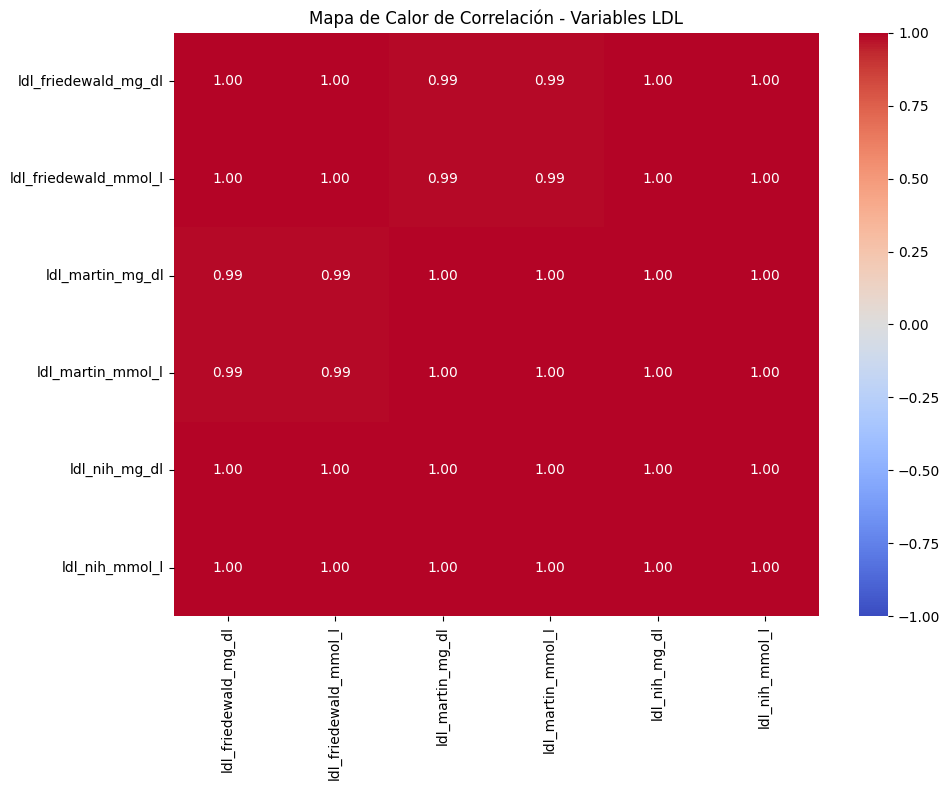

In [113]:

ldl_cols = [col for col in df.columns if col.lower().startswith('ldl')]
print("Columnas encontradas:", ldl_cols)

#  Comprobar si existen columnas y generar la matriz de correlación
if len(ldl_cols) > 0:
    corr_matrix = df[ldl_cols].corr()
    
    # 4. Configurar y mostrar el mapa de calor (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, 
                annot=True,          # Muestra los valores de correlación en las celdas
                cmap='coolwarm',     # Paleta de colores (rojo para +, azul para -)
                fmt=".2f",           # Formato a 2 decimales
                vmin=-1, vmax=1)     # Límites de la correlación de Pearson
    
    plt.title('Mapa de Calor de Correlación - Variables LDL')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas que empiecen por 'ldl' en el dataset.")

In [114]:
variable_a_mantener = 'ldl_martin_mmol_l'

#  Filtramos la lista para obtener solo las que vamos a eliminar
columnas_a_eliminar = [col for col in ldl_cols if col != variable_a_mantener]

#  Eliminamos esas columnas redundantes del DataFrame original
df = df.drop(columns=columnas_a_eliminar)

print(f" Se ha conservado: '{variable_a_mantener}'")
print(f" Se eliminaron: {columnas_a_eliminar}")

 Se ha conservado: 'ldl_martin_mmol_l'
 Se eliminaron: ['ldl_friedewald_mg_dl', 'ldl_friedewald_mmol_l', 'ldl_martin_mg_dl', 'ldl_nih_mg_dl', 'ldl_nih_mmol_l']


Al buscar las variables relacionadas con el cadmio, encontramos dos columnas que miden exactamente lo mismo y tienen una **correlación perfecta (1.00)**, diferenciándose únicamente en su unidad de medida. Para evitar problemas de redundancia (multicolinealidad) en el modelo, aplicamos la misma regla que con el colesterol:

* **Variable conservada:** `cadmio_sangre_nmol_l` (nanomoles por litro). Se mantiene por ser la métrica oficial del **Sistema Internacional (SI)** para concentraciones biológicas.
* **Variable eliminada:** `cadmio_sangre_ug_l` (microgramos por litro). Se descarta para no tener datos duplicados en el entrenamiento.

Columnas de cadmio encontradas: ['cadmio_sangre_ug_l', 'cadmio_sangre_nmol_l']

Resumen Estadístico:
       cadmio_sangre_ug_l  cadmio_sangre_nmol_l
count          2456.00000           2456.000000
mean              0.41934              3.730868
std               0.55330              4.922719
min               0.04600              0.409000
25%               0.15900              1.415000
50%               0.24950              2.219500
75%               0.43900              3.906000
max               7.68400             68.365000


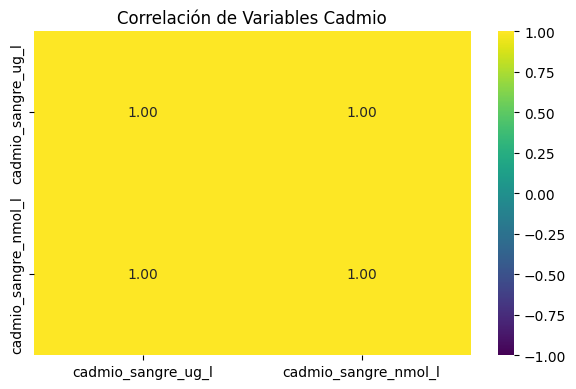

In [115]:
cadmio_cols = [col for col in df.columns if col.lower().startswith('cadmio')]
print("Columnas de cadmio encontradas:", cadmio_cols)

# 3. Analizar estadísticamente y mostrar correlación
if len(cadmio_cols) > 0:
    # Ver resumen estadístico
    print("\nResumen Estadístico:")
    print(df[cadmio_cols].describe())
    
    # Heatmap de correlación
    if len(cadmio_cols) > 1:
        corr_matrix = df[cadmio_cols].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Correlación de Variables Cadmio')
        plt.tight_layout()
        plt.show()

In [116]:
columnas_a_eliminar = ['cadmio_sangre_ug_l']     
df = df.drop(columns=columnas_a_eliminar)
    


Al analizar las variables relacionadas  plomo, identificamos dos métricas idénticas con unidades diferentes: `plomo_sangre_ug_dl` (microgramos por decilitro) y `plomo_sangre_umol_l` (micromoles por litro). Ambas presentan una **correlación perfecta de 1.00**, lo que indica que una es simplemente la transformación matemática de la otra.

Para mantener la consistencia en el preprocesamiento y prevenir la **multicolinealidad** en nuestro modelo de Machine Learning, hemos aplicado el mismo criterio de estandarización que en variables anteriores:

* **Variable conservada:** `plomo_sangre_umol_l`. Se mantiene por estar en la medida oficial del **Sistema Internacional (SI)** para la concentración biológica de sustancias químicas.
* **Variable eliminada:** `plomo_sangre_ug_dl`. Se descarta para evitar la duplicidad de información.

Columnas de plomo encontradas: ['plomo_sangre_ug_dl', 'plomo_sangre_umol_l']

Resumen Estadístico:
       plomo_sangre_ug_dl  plomo_sangre_umol_l
count         2456.000000          2456.000000
mean             0.935752             0.045202
std              1.358054             0.065593
min              0.095000             0.005000
25%              0.449750             0.022000
50%              0.689000             0.033000
75%              1.072000             0.052000
max             48.070000             2.322000


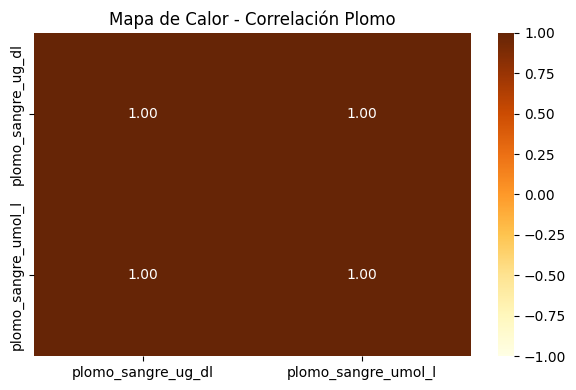

In [117]:
#Filtrar columnas que empiezan por 'plomo'
plomo_cols = [col for col in df.columns if col.lower().startswith('plomo')]
print("Columnas de plomo encontradas:", plomo_cols)

# Mostrar resumen y matriz de correlación
if len(plomo_cols) > 0:
    print("\nResumen Estadístico:")
    print(df[plomo_cols].describe())
    
    if len(plomo_cols) > 1:
        corr_matrix = df[plomo_cols].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr_matrix, annot=True, cmap='YlOrBr', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Mapa de Calor - Correlación Plomo')
        plt.tight_layout()
        plt.show()



In [118]:
columnas_a_eliminar = ['plomo_sangre_ug_dl']     
df = df.drop(columns=columnas_a_eliminar)

Al revisar las variables relacionadas con el manganeso, se detectaron dos métricas idénticas pero en diferentes unidades: `manganeso_sangre_ug_l` (microgramos por litro) y `manganeso_sangre_nmol_l` (nanomoles por litro). Al igual que ocurre con otros metales en el dataset, ambas tienen una **correlación perfecta de 1.00**.

Para mantener la coherencia metodológica en todo el preprocesamiento y evitar problemas de **multicolinealidad** en nuestro modelo predictivo:

* **Variable conservada:** `manganeso_sangre_nmol_l`. Se prioriza esta variable por seguir el estándar del **Sistema Internacional (SI)** para las concentraciones biológicas.
* **Variable eliminada:** `manganeso_sangre_ug_l`. Se elimina para no duplicar información en el entrenamiento del modelo.

Columnas de manganeso encontradas: ['manganeso_sangre_ug_l', 'manganeso_sangre_nmol_l']

Resumen Estadístico:
       manganeso_sangre_ug_l  manganeso_sangre_nmol_l
count            2456.000000              2456.000000
mean                9.594357               174.636515
std                 3.521368                64.096013
min                 2.980000                54.240000
25%                 7.260000               132.150000
50%                 8.950000               162.910000
75%                11.135000               202.680000
max                42.950000               781.780000


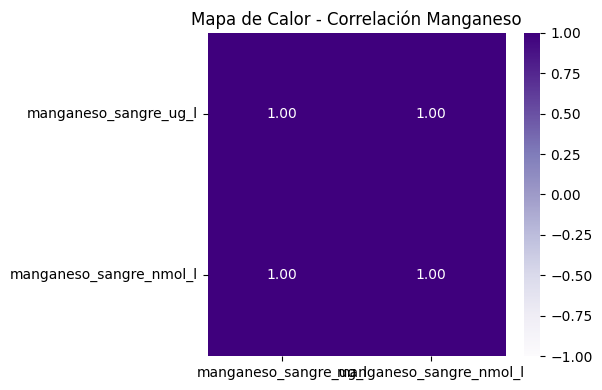

In [119]:
# Filtrar columnas de manganeso
manganeso_cols = [col for col in df.columns if col.lower().startswith('manganeso')]
print("Columnas de manganeso encontradas:", manganeso_cols)

# 3. Mostrar resumen estadístico y matriz de correlación
if len(manganeso_cols) > 0:
    print("\nResumen Estadístico:")
    print(df[manganeso_cols].describe())
    
    if len(manganeso_cols) > 1:
        corr_matrix = df[manganeso_cols].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr_matrix, annot=True, cmap='Purples', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Mapa de Calor - Correlación Manganeso')
        plt.tight_layout()
        plt.show()



In [120]:
columnas_a_eliminar = ['manganeso_sangre_ug_l']     
df = df.drop(columns=columnas_a_eliminar)

En el análisis de las variables de selenio detectamos dos columnas correspondientes al mismo indicador clínico, expresadas en diferentes unidades de medida: `selenio_sangre_ug_l` (microgramos por litro) y `selenio_sangre_umol_l` (micromoles por litro). La correlación entre ambas es **perfecta (1.00)**.

Para mantener la estandarización del dataset y evitar la **multicolinealidad** al entrenar nuestro modelo de Machine Learning, hemos aplicado la misma regla de limpieza que con el resto de los metales pesados:

* **Variable conservada:** `selenio_sangre_umol_l`. Se prioriza esta variable por seguir el estándar del **Sistema Internacional (SI)** de unidades para métricas biológicas.
* **Variable eliminada:** `selenio_sangre_ug_l`. Se excluye para evitar suministrar información redundante al algoritmo.

Columnas de selenio encontradas: ['selenio_sangre_ug_l', 'selenio_sangre_umol_l']

Resumen Estadístico:
       selenio_sangre_ug_l  selenio_sangre_umol_l
count          2456.000000            2456.000000
mean            181.965635               2.310888
std              28.478659               0.361721
min             116.700000               1.480000
25%             165.400000               2.100000
50%             178.900000               2.270000
75%             194.200000               2.470000
max             752.400000               9.560000


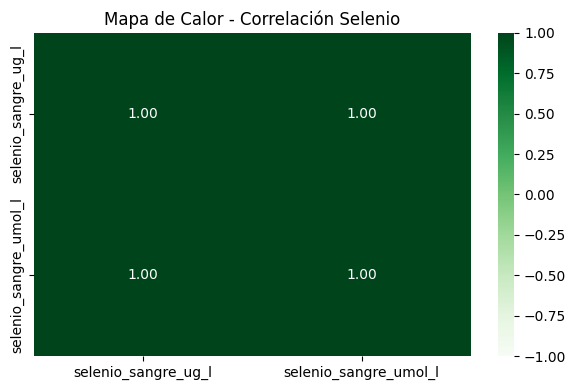

In [121]:
selenio_cols = [col for col in df.columns if col.lower().startswith('selenio')]
print("Columnas de selenio encontradas:", selenio_cols)

#  Mostrar resumen estadístico y matriz de correlación
if len(selenio_cols) > 0:
    print("\nResumen Estadístico:")
    print(df[selenio_cols].describe())
    
    if len(selenio_cols) > 1:
        corr_matrix = df[selenio_cols].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Mapa de Calor - Correlación Selenio')
        plt.tight_layout()
        plt.show()

In [122]:
columnas_a_eliminar = ['selenio_sangre_ug_l']     
df = df.drop(columns=columnas_a_eliminar)

Al igual que observamos con otros metales pesados en el dataset, existen dos variables para registrar la concentración de mercurio en la sangre del paciente: `mercurio_sangre_ug_l` (microgramos por litro) y `mercurio_sangre_nmol_l` (nanomoles por litro). Ambas métricas representan la misma información, lo que se comprueba con su **correlación perfecta (1.00)**.

Para mantener la estandarización de las unidades a lo largo del dataset y prevenir problemas de **multicolinealidad** durante la fase de entrenamiento del modelo:

* **Variable conservada:** `mercurio_sangre_nmol_l`. Se ha seleccionado esta métrica por cumplir con el estándar de concentración biológica del **Sistema Internacional (SI)** de unidades.
* **Variable eliminada:** `mercurio_sangre_ug_l`. Se ha eliminado del dataframe para evitar características redundantes.

Columnas de mercurio encontradas: ['mercurio_sangre_ug_l', 'mercurio_sangre_nmol_l']

Resumen Estadístico:
       mercurio_sangre_ug_l  mercurio_sangre_nmol_l
count           2456.000000             2456.000000
mean               1.265314                6.314515
std                2.098682               10.472120
min                0.120000                0.600000
25%                0.230000                1.150000
50%                0.600000                2.990000
75%                1.412500                7.052500
max               29.540000              147.400000


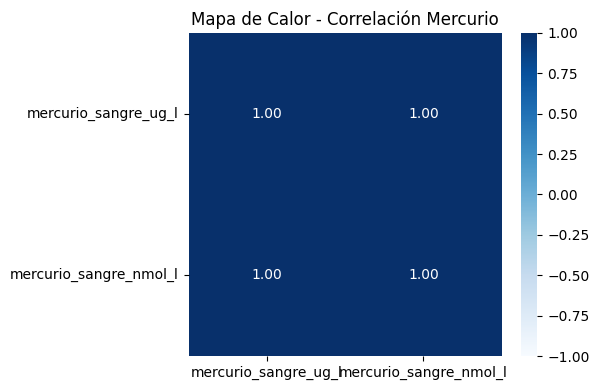

In [123]:
mercurio_cols = [col for col in df.columns if col.lower().startswith('mercurio')]
print("Columnas de mercurio encontradas:", mercurio_cols)

# Mostrar resumen estadístico y matriz de correlación
if len(mercurio_cols) > 0:
    print("\nResumen Estadístico:")
    print(df[mercurio_cols].describe())
    
    if len(mercurio_cols) > 1:
        corr_matrix = df[mercurio_cols].corr()
        plt.figure(figsize=(6, 4))
        sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Mapa de Calor - Correlación Mercurio')
        plt.tight_layout()
        plt.show()

In [124]:
columnas_a_eliminar = ['mercurio_sangre_ug_l']     
df = df.drop(columns=columnas_a_eliminar)

Una vez eliminadas las variables con distinto tipo de unidad, buscamos el resto con variables con correlaciones muy altas.

Correlaciones >= 0.95

Número de columnas analizadas: 72
Variables con alta correlación encontradas: 18


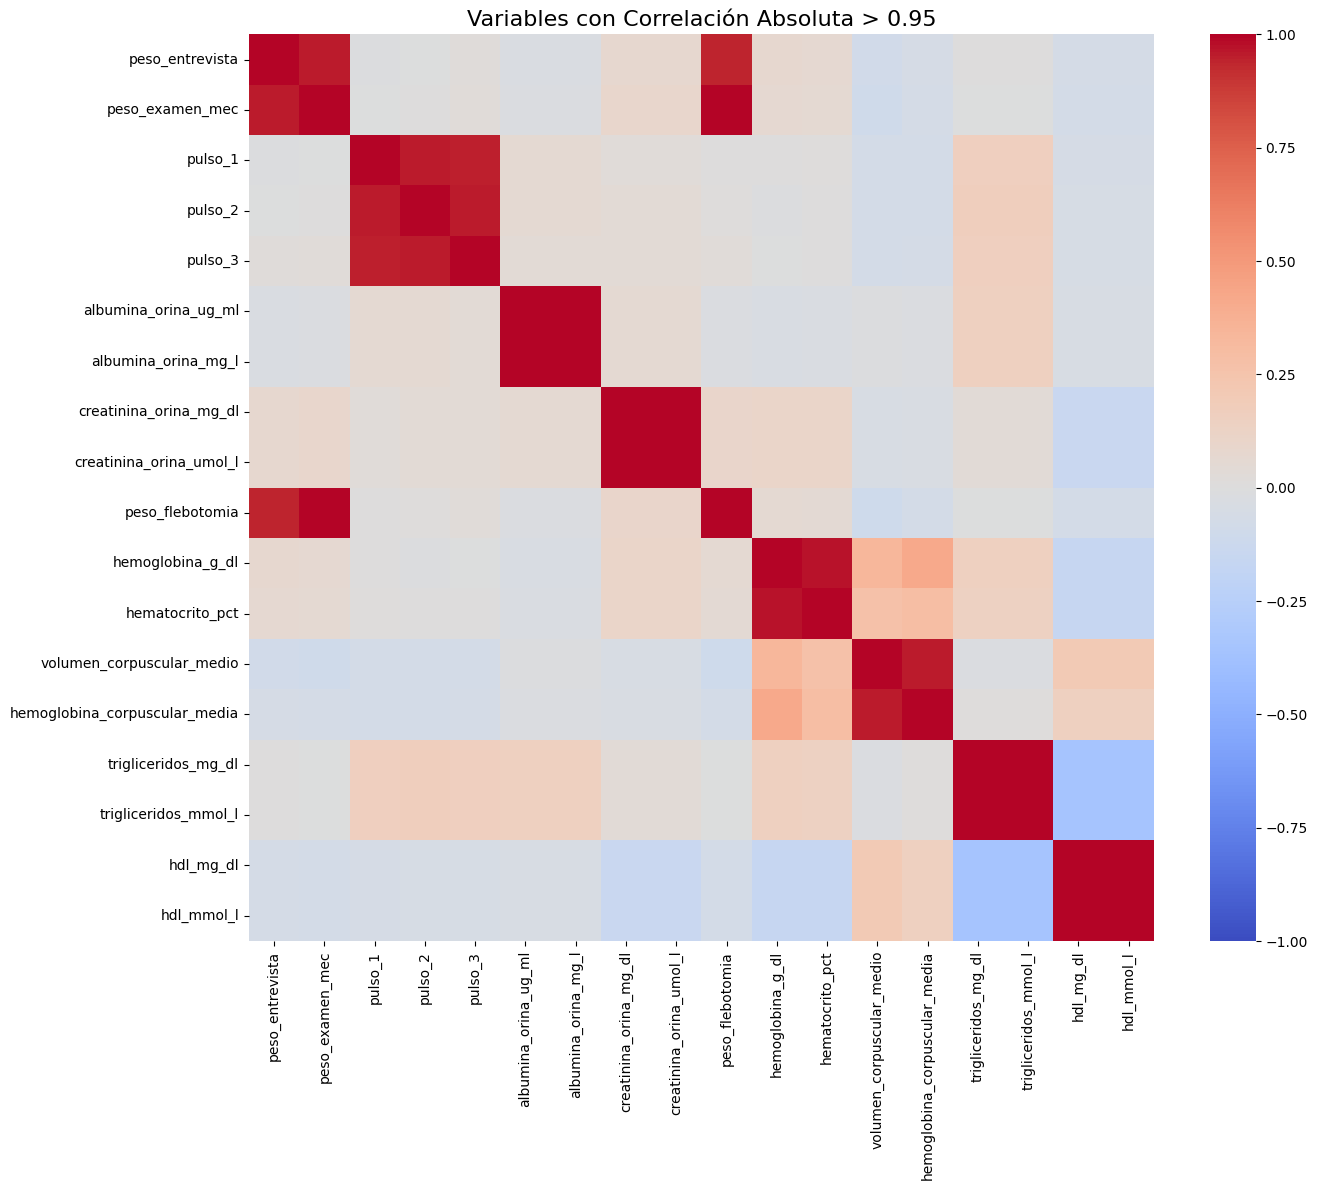

In [125]:
df_num = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación completa
corr_matrix = df_num.corr()

#  Aislar las correlaciones altas (ignorando la diagonal principal de 1.0)
corr_matrix_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_matrix_no_diag.values, 0) # Rellenamos la diagonal con 0

# Crear una máscara booleana buscando > 0.95 o < -0.95
mascara_altas = (corr_matrix_no_diag > 0.95) | (corr_matrix_no_diag < -0.95)

#  Obtener los nombres de las columnas que cumplen esta condición
columnas_altas = corr_matrix.columns[mascara_altas.any()].tolist()

print(f"Número de columnas analizadas: {len(df_num.columns)}")
print(f"Variables con alta correlación encontradas: {len(columnas_altas)}")

# 6. Generar el Heatmap solo con esas columnas
if len(columnas_altas) > 0:
    # Filtramos la matriz original usando las columnas seleccionadas
    corr_filtrada = df_num[columnas_altas].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_filtrada, 
                annot=False,          # Ocultar números para que sea legible
                cmap='coolwarm',      # Divergente: rojo (+), azul (-)
                vmin=-1, vmax=1)
    
    plt.title('Variables con Correlación Absoluta > 0.95', fontsize=16)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables con correlación superior a 0.95 o menor a -0.95.")

Tras realizar la matriz de correlación del dataset, detectamos múltiples parejas de variables clínicas con una **correlación perfecta de 1.00**. Esto ocurre porque el conjunto de datos reporta el mismo resultado de laboratorio utilizando dos unidades de medida distintas (el sistema americano en mg/dL o µg/mL frente al Sistema Internacional). 

Para mantener un dataset óptimo y sin problemas de multicolinealidad, estandarizamos estas variables conservando únicamente la métrica del **Sistema Internacional (SI)**:

* **Albúmina en orina:** Se conserva `albumina_orina_mg_l` (se elimina `ug_ml`).
* **Creatinina en orina:** Se conserva `creatinina_orina_umol_l` (se elimina `mg_dl`).
* **Triglicéridos:** Se conserva `trigliceridos_mmol_l` (se elimina `mg_dl`).
* **Colesterol HDL:** Se conserva `hdl_mmol_l` (se elimina `mg_dl`).

In [126]:
import pandas as pd

componentes_a_limpiar = ['albumina', 'creatin', 'trigliceridos', 'hdl']

# 3. Iterar y limpiar
for comp in componentes_a_limpiar:
    # Buscar todas las columnas que empiecen por este componente
    cols = [col for col in df.columns if col.lower().startswith(comp)]
    
    if len(cols) > 1:
        # Lógica para elegir la del Sistema Internacional
        if 'albumina' in comp:
            # Para la albúmina, el SI usa mg/L
            var_si = next((col for col in cols if 'mg_l' in col), None)
        else:
            # Para el resto, el SI usa moles por litro (mmol_l, umol_l, etc.)
            var_si = next((col for col in cols if 'mol_l' in col), None)
            
        if var_si:
            # Identificar cuáles eliminar
            cols_eliminar = [col for col in cols if col != var_si]
            
            # Eliminar las redundantes del DataFrame
            df = df.drop(columns=cols_eliminar)
            
            print(f" {comp.upper()}: Se conservó '{var_si}'")
            print(f" Eliminadas: {cols_eliminar}\n")
        else:
            print(f"⚠️ No se encontró la variable SI para {comp}.")

 ALBUMINA: Se conservó 'albumina_orina_mg_l'
 Eliminadas: ['albumina_orina_ug_ml']

 CREATIN: Se conservó 'creatinina_orina_umol_l'
 Eliminadas: ['creatinina_orina_mg_dl']

 TRIGLICERIDOS: Se conservó 'trigliceridos_mmol_l'
 Eliminadas: ['trigliceridos_mg_dl']

 HDL: Se conservó 'hdl_mmol_l'
 Eliminadas: ['hdl_mg_dl']



l revisar la matriz de correlaciones, identificamos una alta correlación positiva (**0.9549**) entre el `volumen_corpuscular_medio` (VCM) y la `hemoglobina_corpuscular_media` (HCM). 

A diferencia de los metales pesados, estas **no son la misma variable en distintas unidades**, sino dos métricas biológicas distintas que tienen una dependencia física natural: a mayor tamaño del glóbulo rojo (VCM), mayor es la cantidad de hemoglobina que puede albergar en su interior (HCM). 

No obstante, a nivel matemático introducen **multicolinealidad** en el modelo, ya que ambas ofrecen la misma señal subyacente para los algoritmos. Para solucionarlo:
* **Variable conservada:** `volumen_corpuscular_medio`. Se mantiene por ser la métrica clínica primaria utilizada para la clasificación de anemias (microcíticas vs macrocíticas).
* **Variable eliminada:** `hemoglobina_corpuscular_media`. Se excluye para reducir la redundancia y simplificar el modelo sin pérdida significativa de información.

In [127]:
variable_a_eliminar = 'hemoglobina_corpuscular_media'

df = df.drop(columns=[variable_a_eliminar])
print(f"Se eliminó del dataset: ['{variable_a_eliminar}']")

Se eliminó del dataset: ['hemoglobina_corpuscular_media']


Durante la evaluación de correlaciones observamos una relación positiva casi perfecta (**0.9719**) entre la `hemoglobina_g_dl` (concentración de la proteína en sangre) y el `hematocrito_pct` (porcentaje de glóbulos rojos en el volumen sanguíneo total). 

Esta alta correlación se debe a una constante biológica matemática (el hematocrito equivale aproximadamente al triple de la hemoglobina). Mantener ambas variables causaría **multicolinealidad**, confundiendo a los algoritmos al presentarles información repetida. Para solucionarlo:

* **Variable conservada:** `hemoglobina_g_dl`. Se prioriza esta variable por ser la métrica de oro (Gold Standard) más directa y robusta utilizada clínicamente para diagnosticar problemas en la sangre (como las anemias), ya que es menos susceptible a variaciones temporales por el nivel de hidratación del paciente.
* **Variable eliminada:** `hematocrito_pct`. Se excluye del conjunto de entrenamiento para simplificar el modelo predictivo.

In [128]:
variable_a_eliminar = 'hematocrito_pct'

# Eliminar del dataset
df = df.drop(columns=[variable_a_eliminar])
print(f" Se eliminó del dataset: ['{variable_a_eliminar}']")

 Se eliminó del dataset: ['hematocrito_pct']


Durante la exploración inicial, detectamos las variables `peso_entrevista` y `peso_examen_mec` (altamente correlacionadas entre sí con un 0.9561). Estas variables no corresponden a ninguna métrica física o de salud del paciente (como el peso corporal), sino que son **pesos estadísticos (Sample Weights)** utilizados por los diseñadores de la encuesta para extrapolaciones poblacionales.

Desde la perspectiva del **Machine Learning predictivo**:
1. Estas variables no aportan valor biológico ni clínico.
2. Un paciente nuevo en un entorno de producción o diagnóstico real no tendrá un "peso de encuesta" asociado.
3. Entrenar el modelo con estos pesos podría introducir sesgos o hacer que el algoritmo busque patrones artificiales basados en el diseño del muestreo.

**Decisión tomada:** Para evitar ruido y prevenir el aprendizaje de relaciones espurias, **ambas variables han sido eliminadas** del conjunto de entrenamiento.

In [129]:
pesos_cols = ['peso_entrevista', 'peso_examen_mec']
# Eliminamos ambos pesos ya que no son variables predictivas de salud
df = df.drop(columns=pesos_cols, errors='ignore')
print(f"Se eliminaron del dataset los pesos muestrales: {pesos_cols}")

Se eliminaron del dataset los pesos muestrales: ['peso_entrevista', 'peso_examen_mec']


Una vez limpiado hasta un 95% de correlacion 

Número de columnas analizadas: 64
Variables con alta correlación encontradas: 25


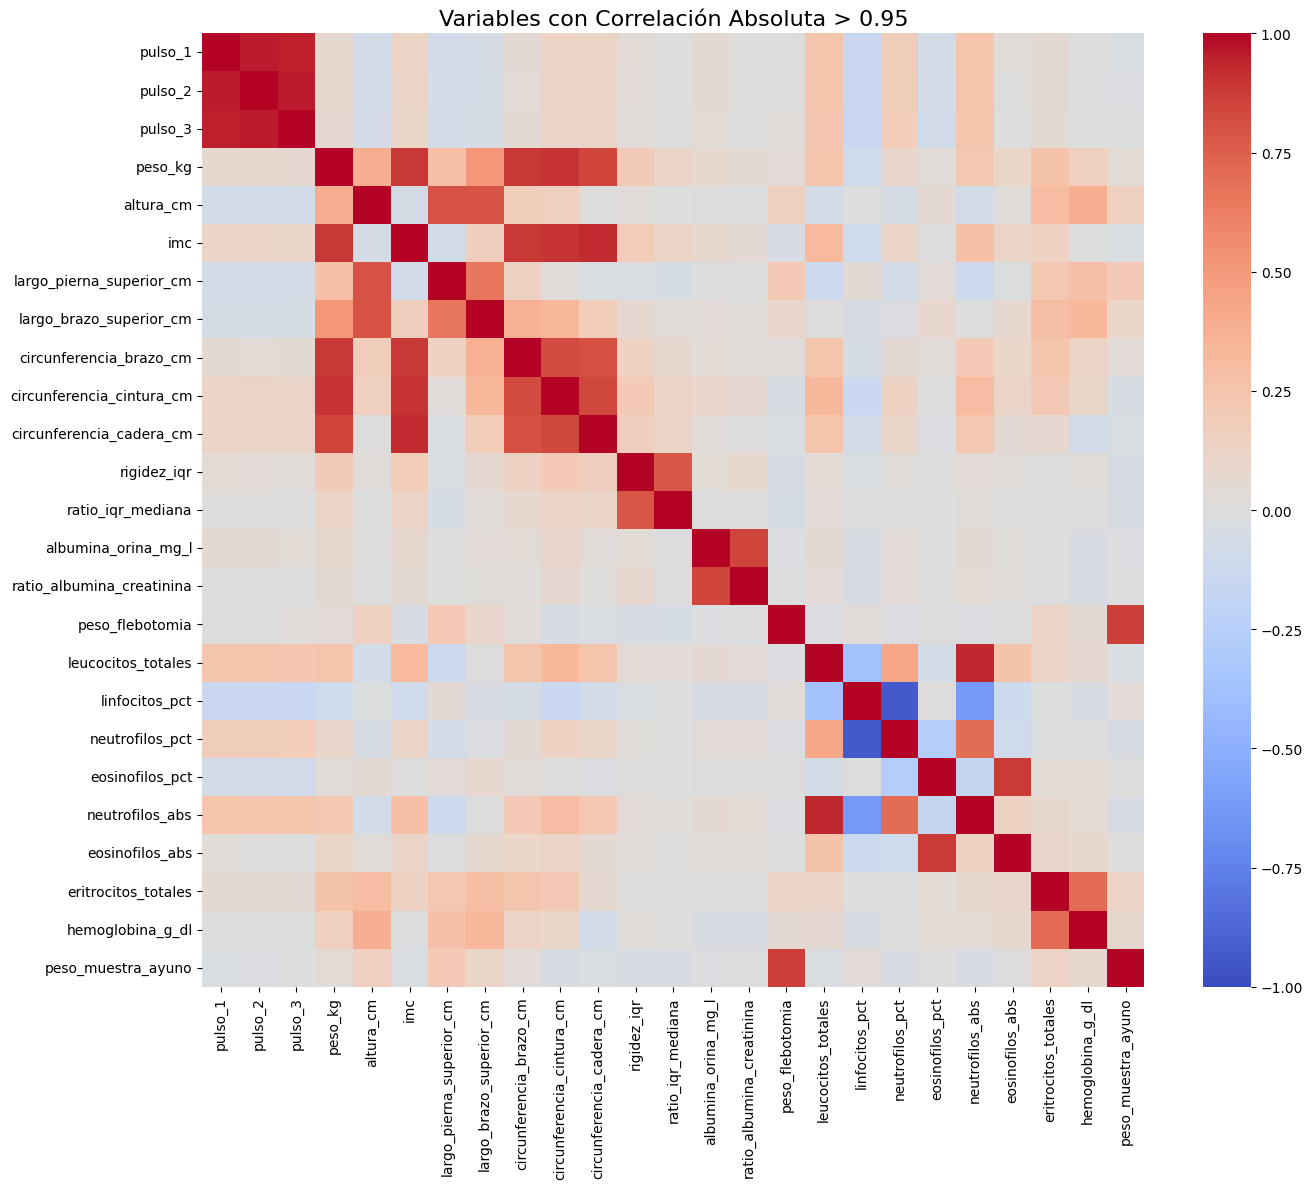

In [130]:
df_num = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación completa
corr_matrix = df_num.corr()

#  Aislar las correlaciones altas (ignorando la diagonal principal de 1.0)
corr_matrix_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_matrix_no_diag.values, 0) # Rellenamos la diagonal con 0

# Crear una máscara booleana buscando > 0.7 o < -0.7
mascara_altas = (corr_matrix_no_diag > 0.7) | (corr_matrix_no_diag < -0.7)

#  Obtener los nombres de las columnas que cumplen esta condición
columnas_altas = corr_matrix.columns[mascara_altas.any()].tolist()

print(f"Número de columnas analizadas: {len(df_num.columns)}")
print(f"Variables con alta correlación encontradas: {len(columnas_altas)}")

# 6. Generar el Heatmap solo con esas columnas
if len(columnas_altas) > 0:
    # Filtramos la matriz original usando las columnas seleccionadas
    corr_filtrada = df_num[columnas_altas].corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_filtrada, 
                annot=False,          # Ocultar números para que sea legible
                cmap='coolwarm',      # Divergente: rojo (+), azul (-)
                vmin=-1, vmax=1)
    
    plt.title('Variables con Correlación Absoluta > 0.95', fontsize=16)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables con correlación superior a 0.95 o menor a -0.95.")

Durante el examen físico (MEC), el protocolo médico establece tomar el pulso del paciente en tres momentos distintos (`pulso_1`, `pulso_2` y `pulso_3`) para asegurar una lectura estable. 

Debido a que estas tres variables están altamente correlacionadas (representan el estado circulatorio del mismo paciente en la misma visita), incluirlas por separado en el modelo generaría redundancia (**multicolinealidad**) y aumentaría innecesariamente la dimensionalidad del dataset.

**Transformación aplicada:**
Para capturar la verdadera señal clínica, se procedió a **promediar las tres tomas** creando una nueva característica única denominada `pulso`, que representa la frecuencia cardíaca promedio en reposo. Posteriormente, las tres mediciones individuales fueron eliminadas del conjunto de datos.

In [131]:
pulso_cols = ['pulso_1', 'pulso_2', 'pulso_3']

# 3. TRATAMIENTO: Calcular la media de las tomas por paciente (fila)
# axis=1 indica que calcule la media horizontalmente (por individuo)
df['pulso'] = df[pulso_cols].mean(axis=1).round(0)

# 4. Eliminar las variables originales
df = df.drop(columns=pulso_cols)

Al revisar el hemograma (conteo de células blancas), detectamos que el dataset incluye los 5 subtipos de leucocitos (neutrófilos, linfocitos, monocitos, eosinófilos y basófilos) medidos de dos formas: en **valor absoluto** (`_abs`) y en **porcentaje** (`_pct`).

Dado que el valor absoluto es una derivación matemática exacta del porcentaje sobre los `leucocitos_totales`, incluir ambos formatos introduce redundancia matemática (**multicolinealidad**) en el modelo. Además, el uso de porcentajes genera datos composicionales (cuya suma forzada al 100% crea falsas correlaciones negativas entre las variables).

Para asegurar la robustez del modelo predictivo:
* **Variables conservadas:** Se mantienen las unidades absolutas (`_abs`) de los 5 subtipos, así como los `leucocitos_totales`, por ser métricas clínicas directas de la magnitud real de la respuesta inmunitaria.
* **Variables eliminadas:** Se descartaron todas las variables porcentuales (`_pct`) para eliminar la dependencia lineal.

In [132]:
celulas_blancas = ['neutrofilos', 'linfocitos', 'monocitos', 'eosinofilos', 'basofilos']

# 3. Buscar todas las columnas de porcentajes para eliminarlas
columnas_pct_a_eliminar = [f"{celula}_pct" for celula in celulas_blancas if f"{celula}_pct" in df.columns]

# 4. TRATAMIENTO: Eliminar los porcentajes y conservar valores absolutos y leucocitos totales
df = df.drop(columns=columnas_pct_a_eliminar)

print("Se conservaron los valores absolutos (_abs) y los 'leucocitos_totales'")
print(f"Se eliminaron las proporciones relativas: {columnas_pct_a_eliminar}")

Se conservaron los valores absolutos (_abs) y los 'leucocitos_totales'
Se eliminaron las proporciones relativas: ['neutrofilos_pct', 'linfocitos_pct', 'monocitos_pct', 'eosinofilos_pct', 'basofilos_pct']


Las variables raza_etnia y raza_etnia_3 tienen los mismos datos solo que se agregó una categoría más para clasificar la etnia, por eso nos quedamos con la etnia_3 que es la más actualizada y la renombramos como raza_etnia

In [133]:
df = df.drop(columns=['raza_etnia1'], errors='ignore')

#Renombrar la variable conservada para un nombre más limpio
df = df.rename(columns={'raza_etnia_3': 'raza_etnia'})

Durante el análisis bivariante, evaluamos la relación entre el Índice de Masa Corporal (`imc`) y diversas medidas antropométricas específicas: `circunferencia_brazo_cm`, `circunferencia_cintura_cm` y `circunferencia_cadera_cm`.

Los resultados arrojaron una correlación positiva muy alta (entre **0.88 y 0.93**) entre el IMC y estas circunferencias corporales. Dado que el IMC ya sintetiza de forma robusta la proporción de masa corporal del paciente (peso/altura²), la inclusión adicional de las circunferencias introduce redundancia matemática que podría derivar en **multicolinealidad**.

**Decisión tomada:** * **Variable conservada:** `imc`. Se mantiene por ser la métrica clínica global estándar más utilizada para estratificar los rangos de peso (bajo peso, normopeso, sobrepeso, obesidad).
* **Variables eliminadas:** Se descartaron las circunferencias de brazo, cintura y cadera para simplificar el modelo, reducir la dimensionalidad y evitar sesgar el aprendizaje del algoritmo hacia la dimensión del peso corporal.

In [134]:
# Definir las columnas de circunferencias a eliminar
circunferencia_cols = [
    'circunferencia_brazo_cm', 
    'circunferencia_cintura_cm', 
    'circunferencia_cadera_cm'
]

# TRATAMIENTO PARA MACHINE LEARNING:
# Eliminar las medidas de circunferencia debido a su alta correlación con el IMC
df = df.drop(columns=circunferencia_cols, errors='ignore')

print("Se ha conservado la variable global: 'imc'")
print(f"Se eliminaron del dataset las circunferencias: {circunferencia_cols}")

Se ha conservado la variable global: 'imc'
Se eliminaron del dataset las circunferencias: ['circunferencia_brazo_cm', 'circunferencia_cintura_cm', 'circunferencia_cadera_cm']


In [135]:
print(df.shape)

(2459, 71)


## Exportar datasets

Tras realizar esta revisión, análisis y primera limpieza del dataset vamos a proceder a exportar el dataset.

In [136]:
# Exportar el DataFrame df a la carpeta "data"
df.to_csv("data/dataset_raw.csv", index=False, encoding="utf-8-sig")

Tras haber guardado el dataset completo, a continuación vamos a generar el set de training y el set de test aplicando "stratify" para asegurar que hay una división equitativa y evitar sesgos causados por la división.

              Train   Test
hipertension              
0             54.75  54.88
1             45.25  45.12


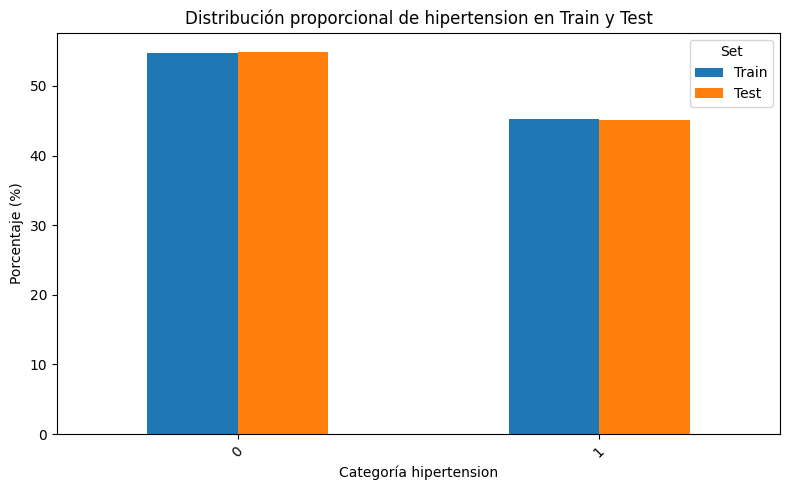

In [137]:
from sklearn.model_selection import train_test_split

# Split estratificado por "hipertension"
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["hipertension"]
)

# Ver distribución proporcional
distribucion = pd.DataFrame({
    "Train": train_df["hipertension"].value_counts(normalize=True),
    "Test": test_df["hipertension"].value_counts(normalize=True)
}).fillna(0) * 100

print(distribucion.round(2))

# Gráfico de barras
distribucion.plot(kind="bar", figsize=(8, 5))

plt.title("Distribución proporcional de hipertension en Train y Test")
plt.xlabel("Categoría hipertension")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.legend(title="Set")
plt.tight_layout()
plt.show()

# Exportar datasets
train_df.to_csv("data/trainset_raw.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("data/testset_raw.csv", index=False, encoding="utf-8-sig")

In [138]:
print( f"Train set: {train_df.shape[0]} filas, {train_df.shape[1]} columnas")
print( f"Test set: {test_df.shape[0]} filas, {test_df.shape[1]} columnas")

Train set: 1967 filas, 71 columnas
Test set: 492 filas, 71 columnas


In [139]:
train_df = pd.read_csv('data/trainset_raw.csv')
test_df = pd.read_csv('data/testset_raw.csv')

In [140]:
# Separar variables numéricas y categóricas
# 1. Variables Numéricas 
num_cols = [
    'edad_an', 'ratio_pobreza', 'peso_dieta_dia1', 'cant_suplementos', 
    'cant_antiacidos', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 
    'tiempo_seg_cond3', 'tiempo_seg_cond4', 'peso_kg', 'altura_cm', 'imc', 
    'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 
    'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 
    'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 
    'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 
    'peso_flebotomia', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 
    'neutrofilos_abs', 'eosinofilos_abs', 'basofilos_abs', 'eritrocitos_totales', 
    'hemoglobina_g_dl', 'volumen_corpuscular_medio', 'conc_hemoglobina_media', 
    'ancho_distribucion_eritrocitos', 'plaquetas_totales', 
    'volumen_plaquetario_medio', 'eritrocitos_nucleados', 'peso_muestra_ayuno', 
    'trigliceridos_mmol_l', 'ldl_martin_mmol_l', 'hdl_mmol_l', 
    'proteina_c_reactiva_mg_l', 'plomo_sangre_umol_l', 'cadmio_sangre_nmol_l', 
    'mercurio_sangre_nmol_l', 'selenio_sangre_umol_l', 'manganeso_sangre_nmol_l', 
    'pres_arterial_media', 'pulso', 'tamano_hogar'
]

# 2. Variables Categóricas  
cat_cols = [
    'genero', 'raza_etnia', 'periodo_examen', 'pais_nacimiento', 'estrato', 'psu', 
    'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 
    'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 
    'medicacion_osteoporosis', 'aprueba_cond4', 'estado_elastografia', 
    'tipo_sonda_elasto', 'tamano_manguito_pa'
]

Revisar la media para asegurar que test es representativo

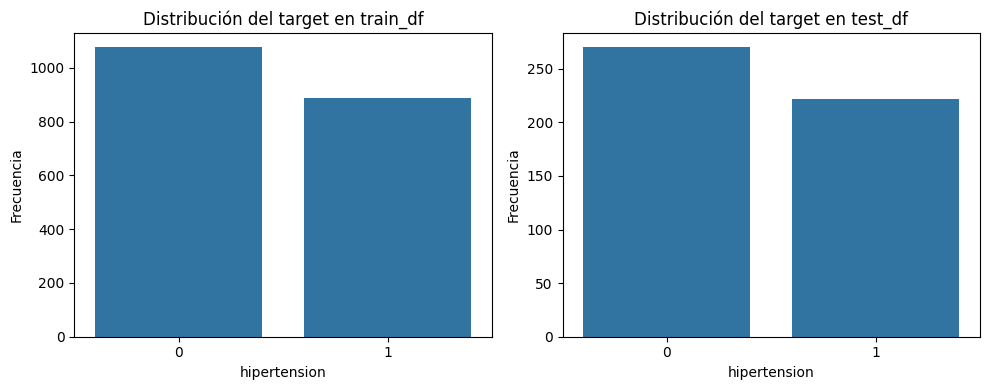

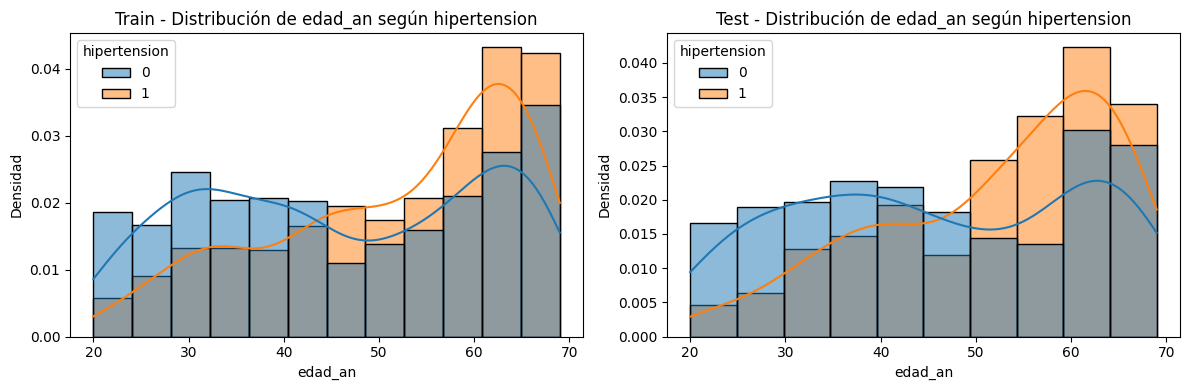

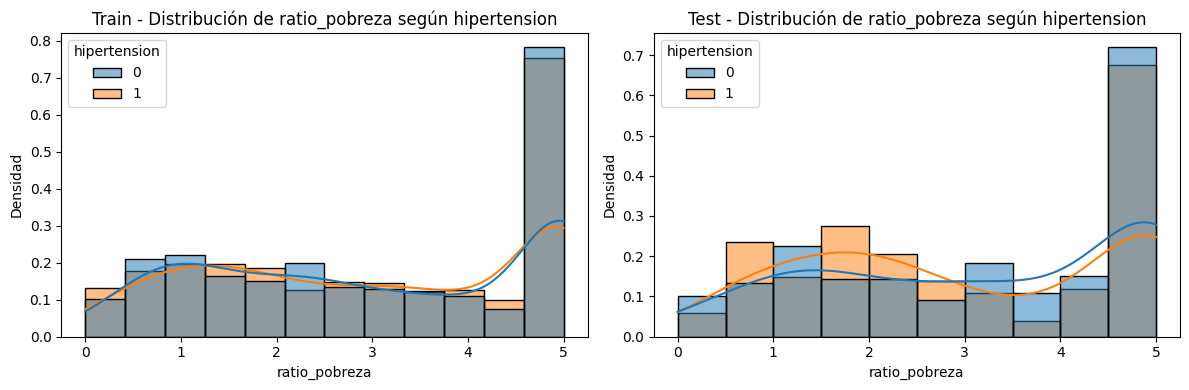

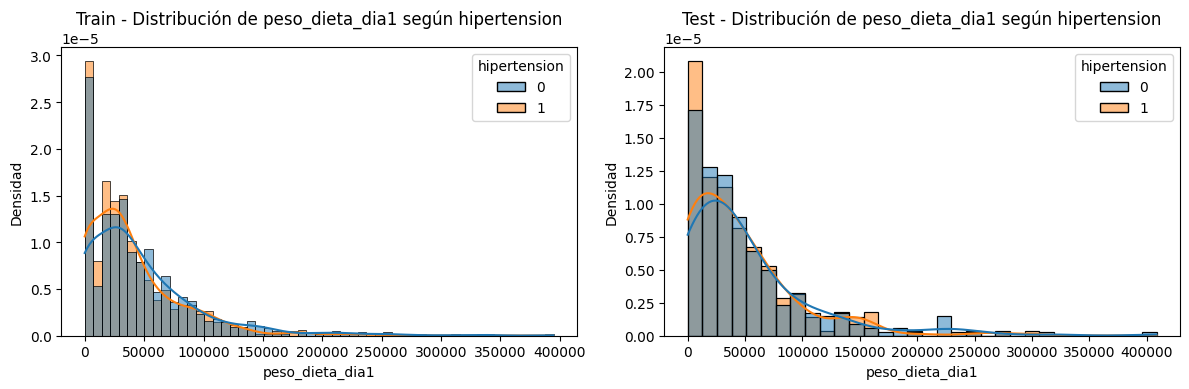

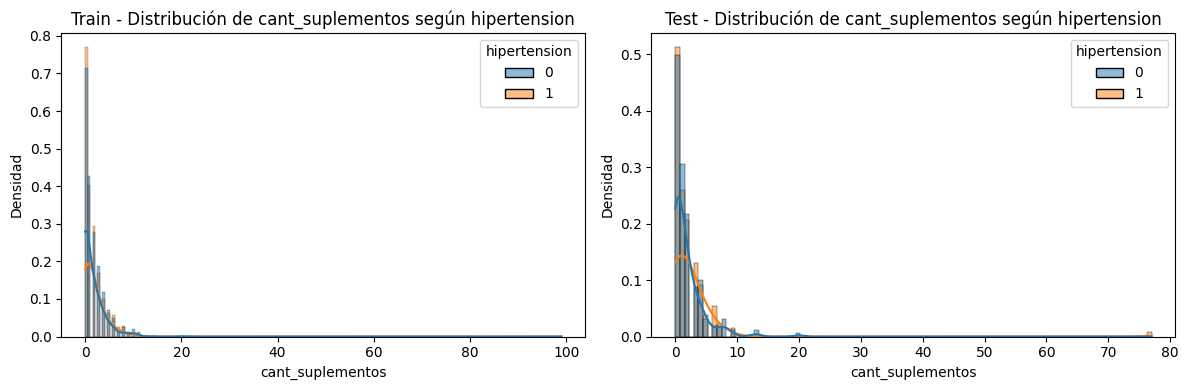

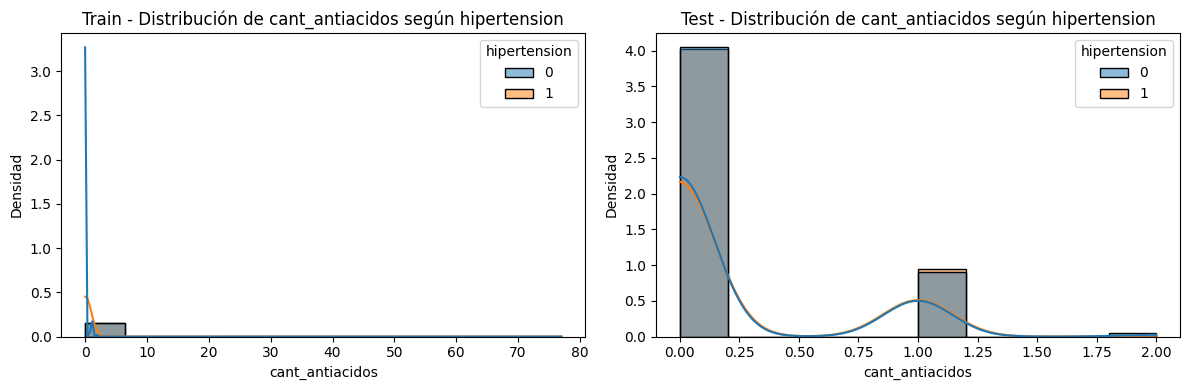

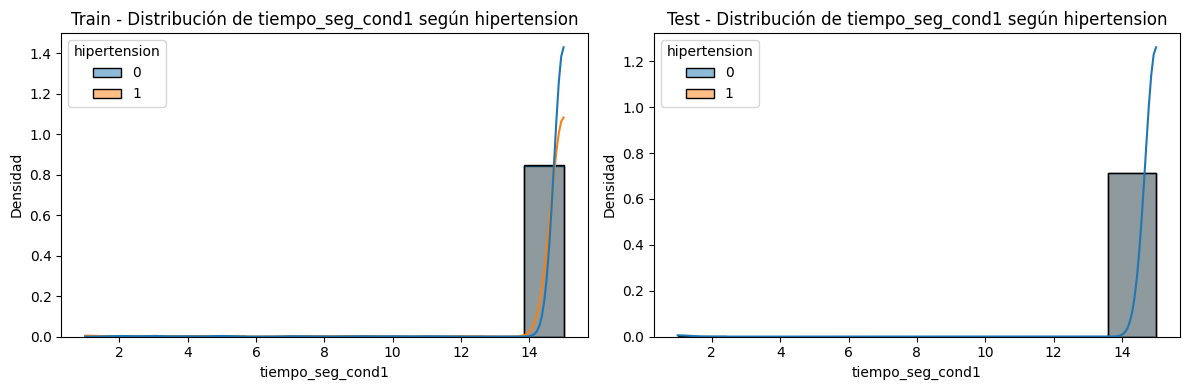

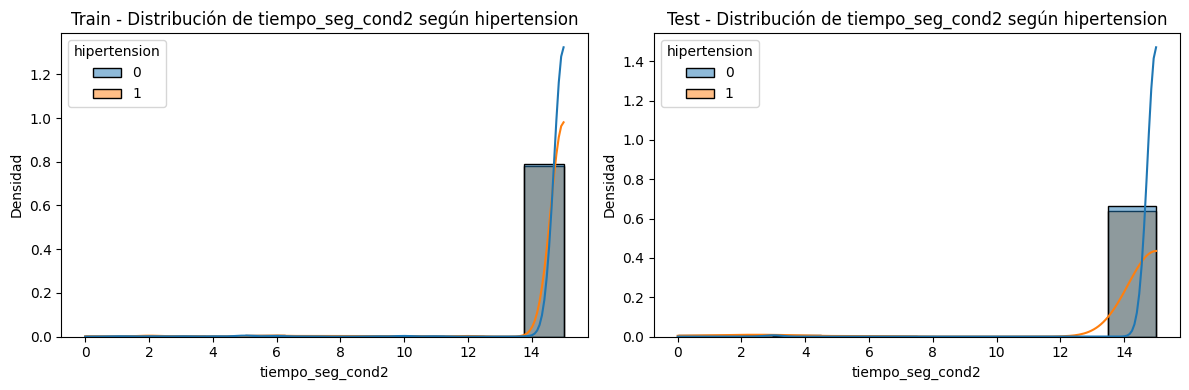

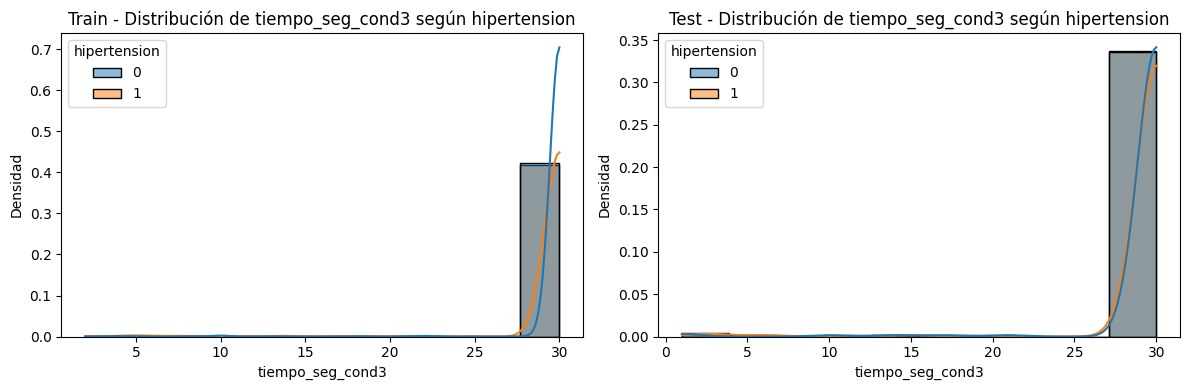

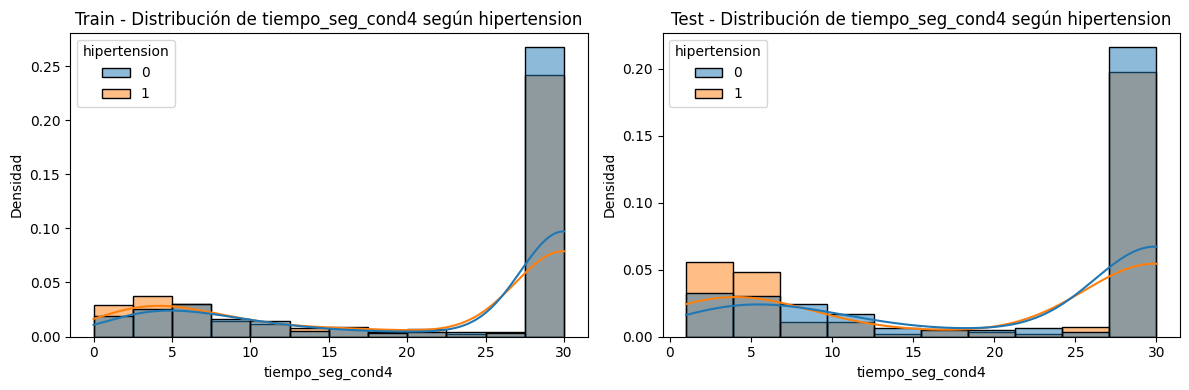

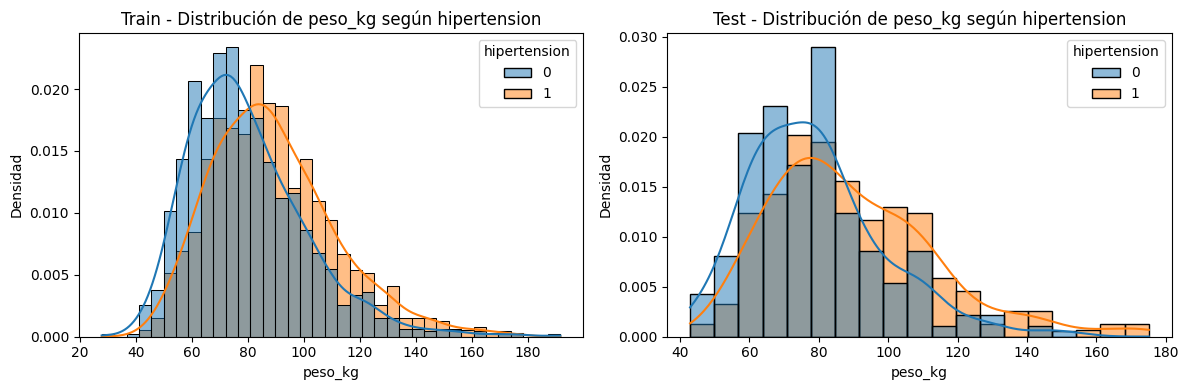

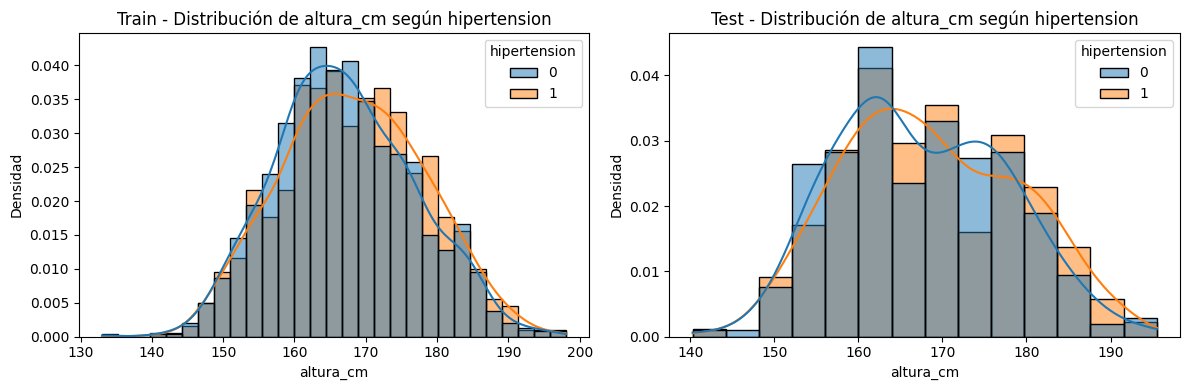

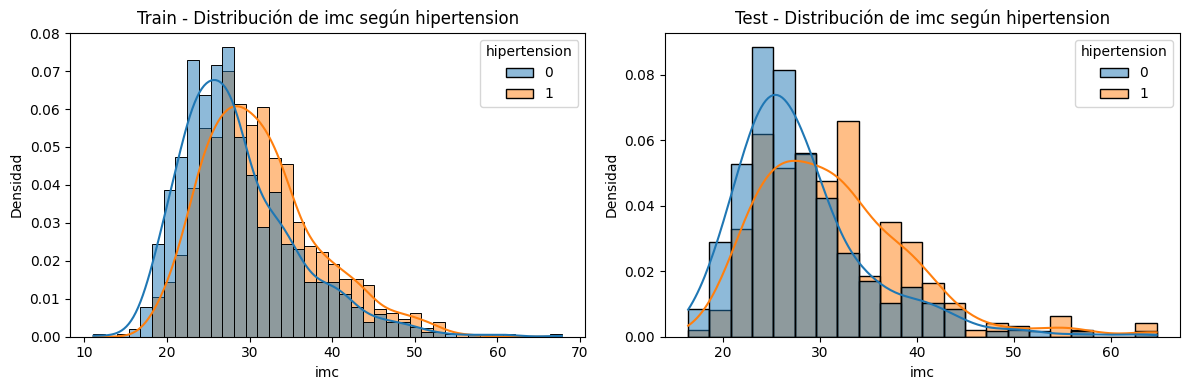

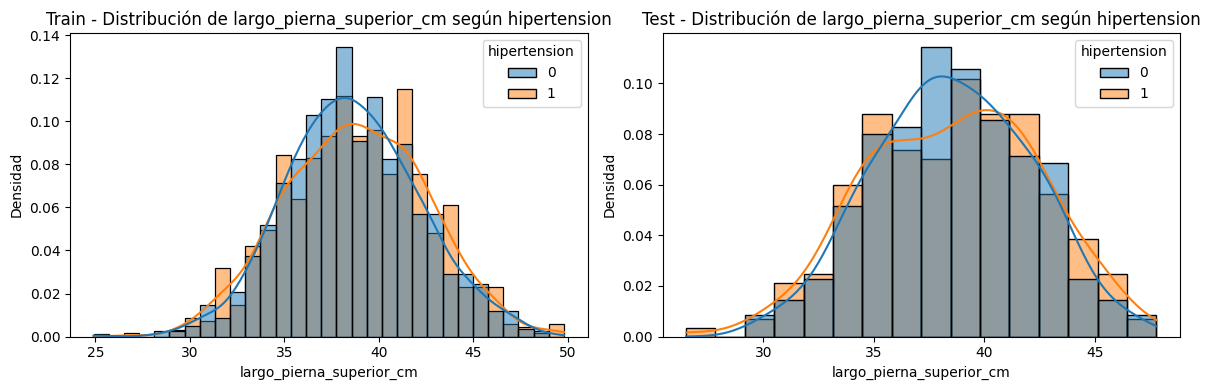

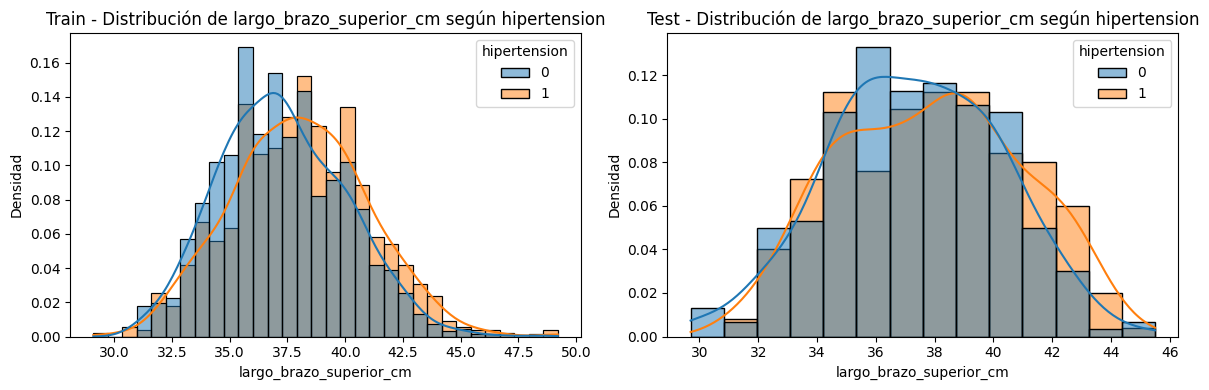

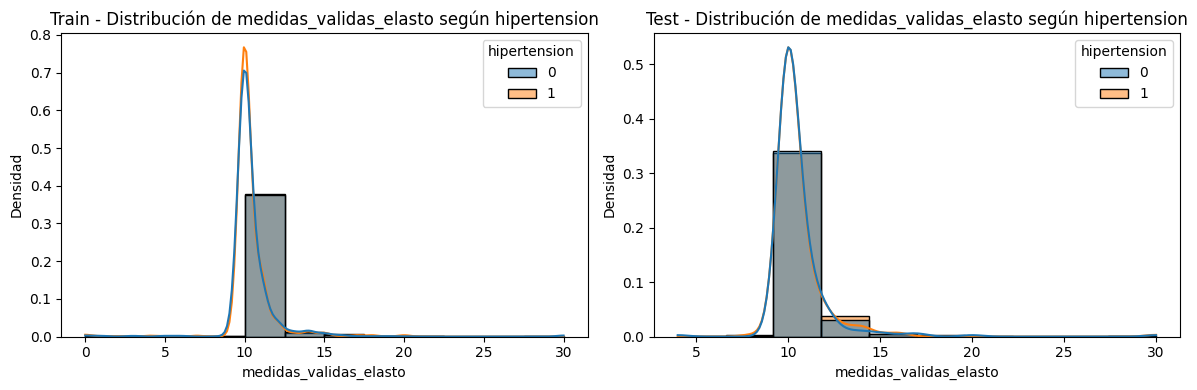

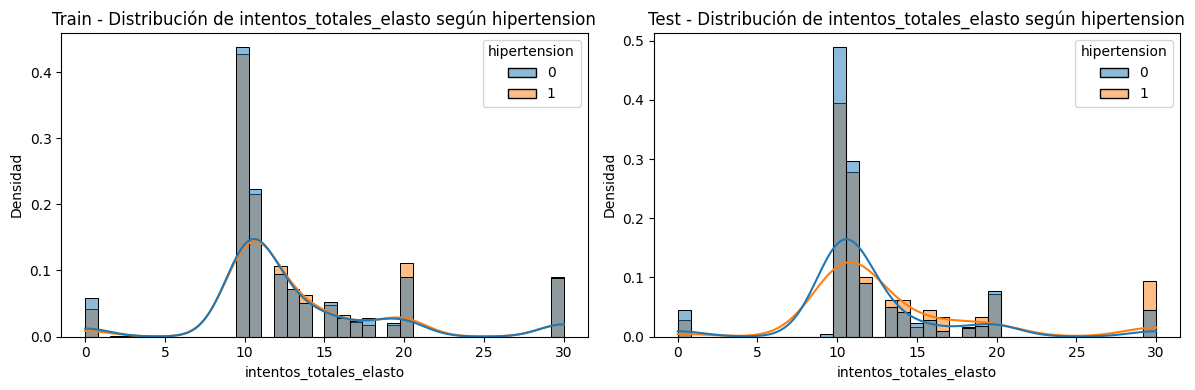

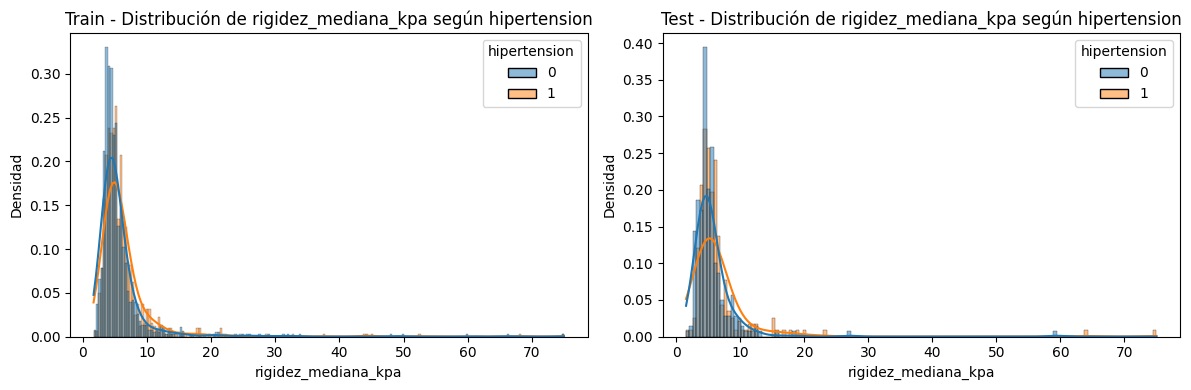

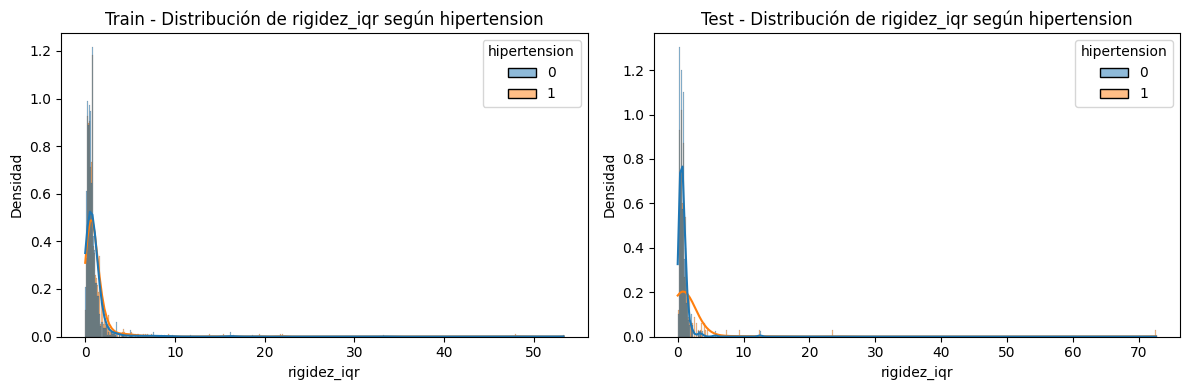

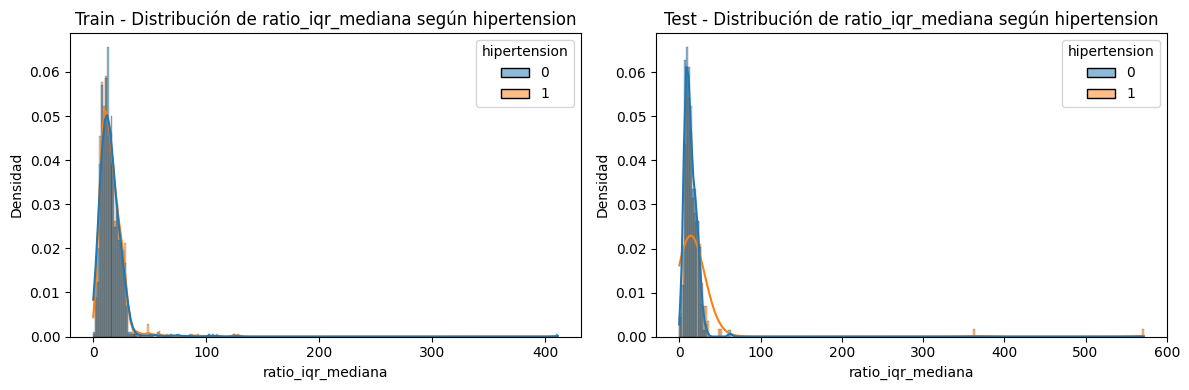

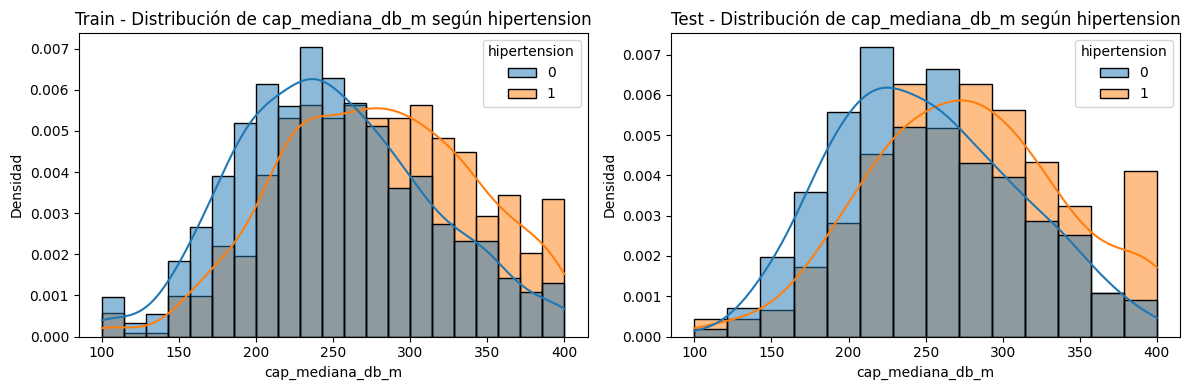

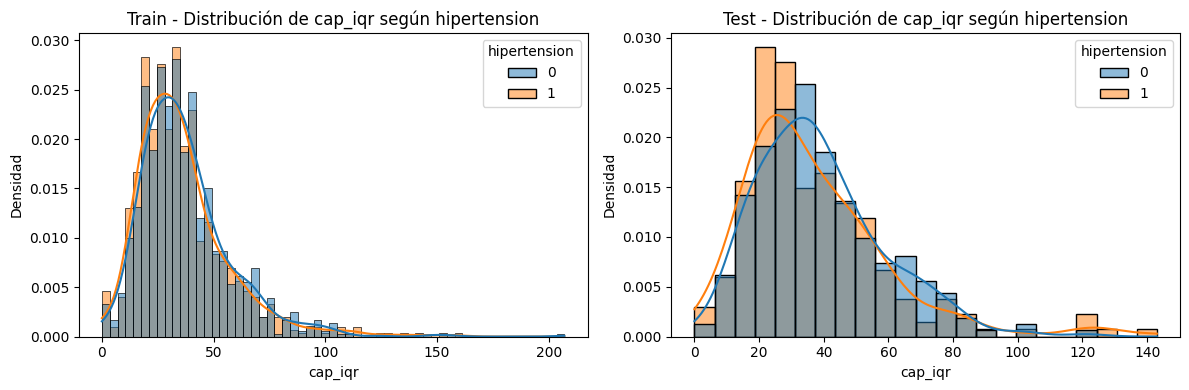

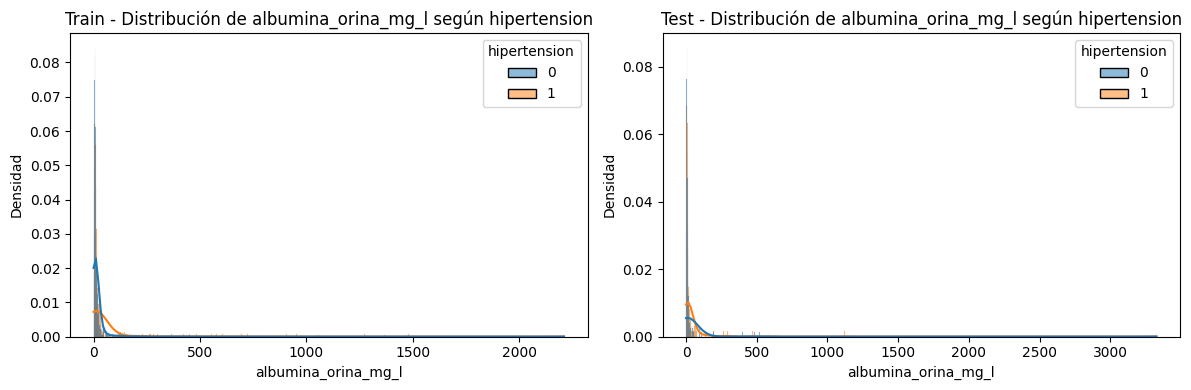

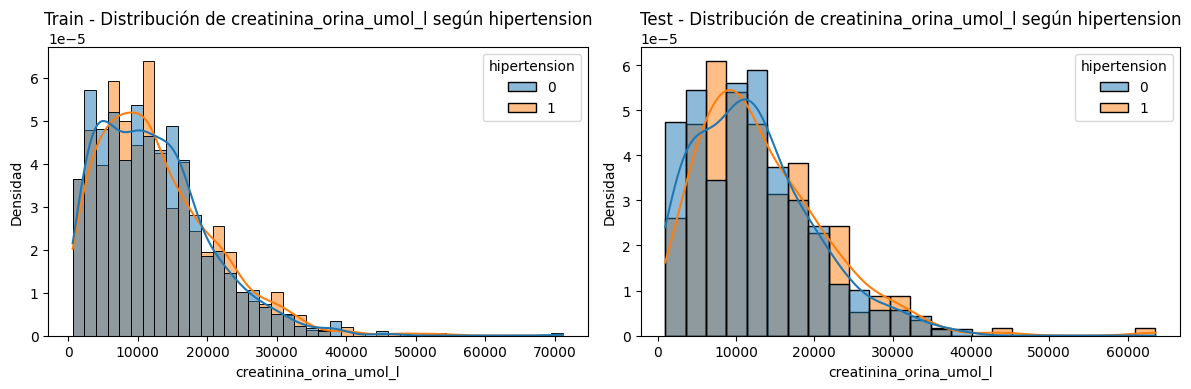

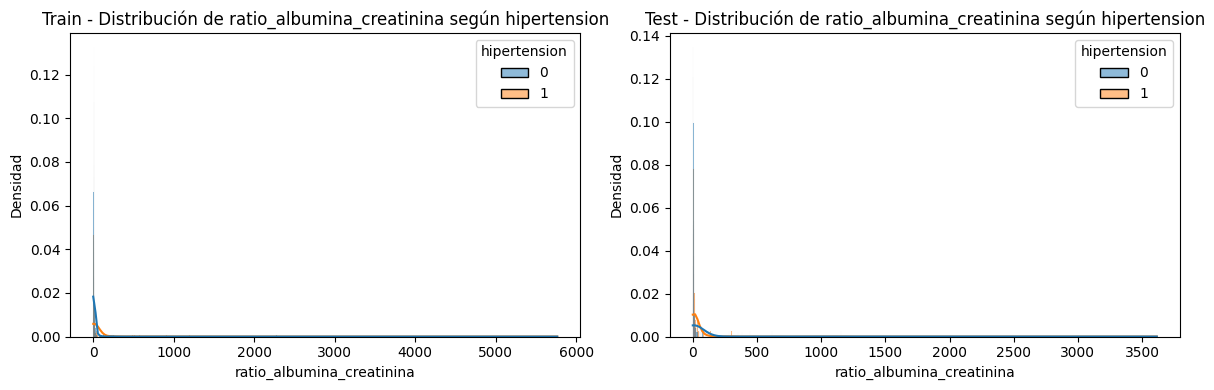

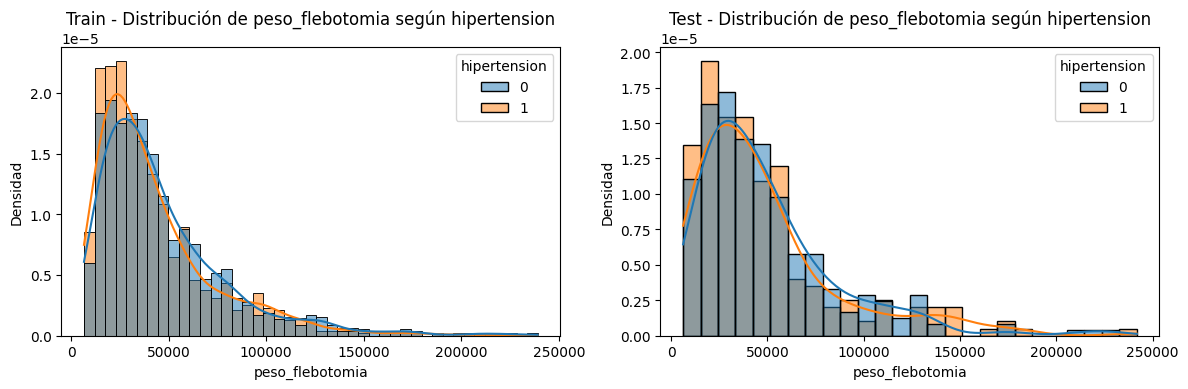

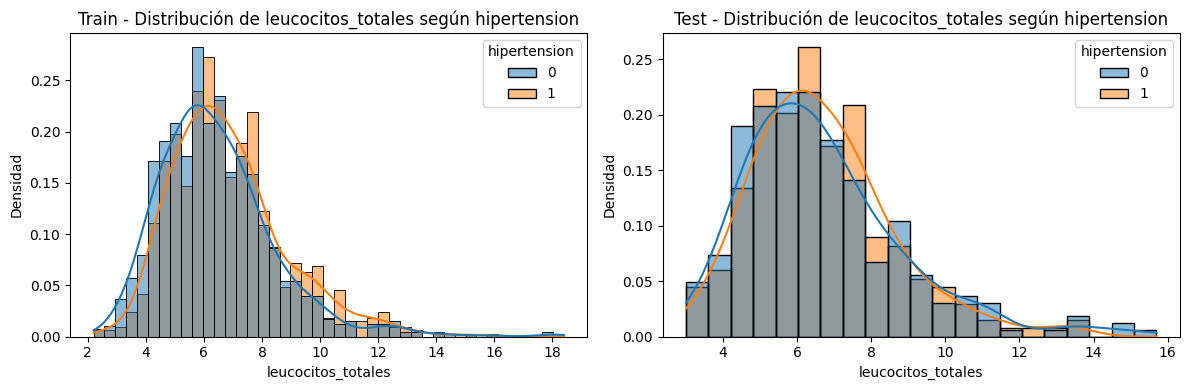

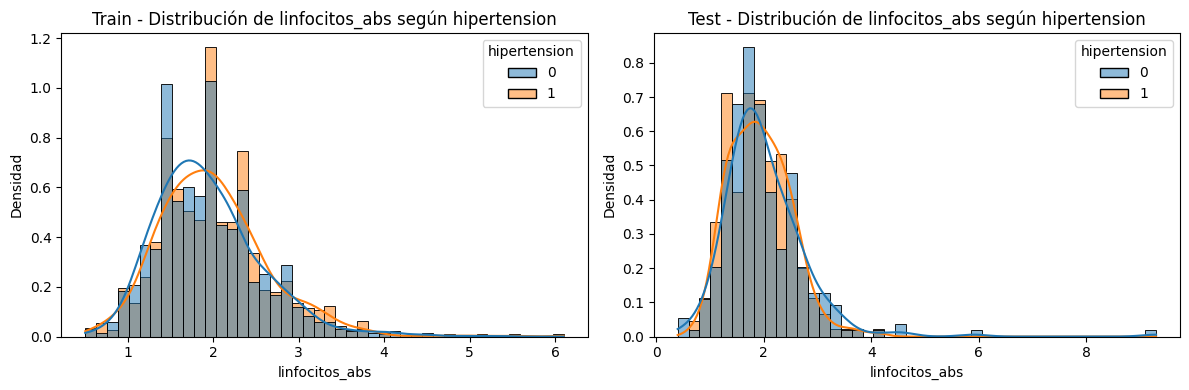

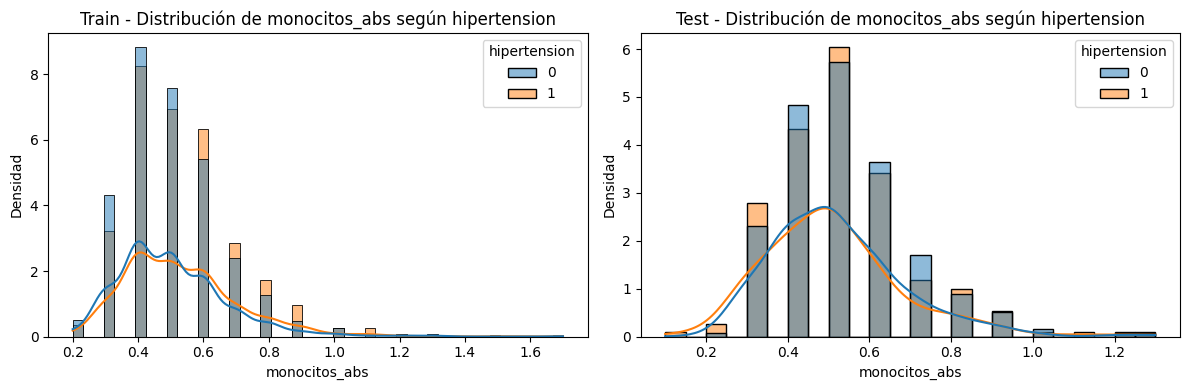

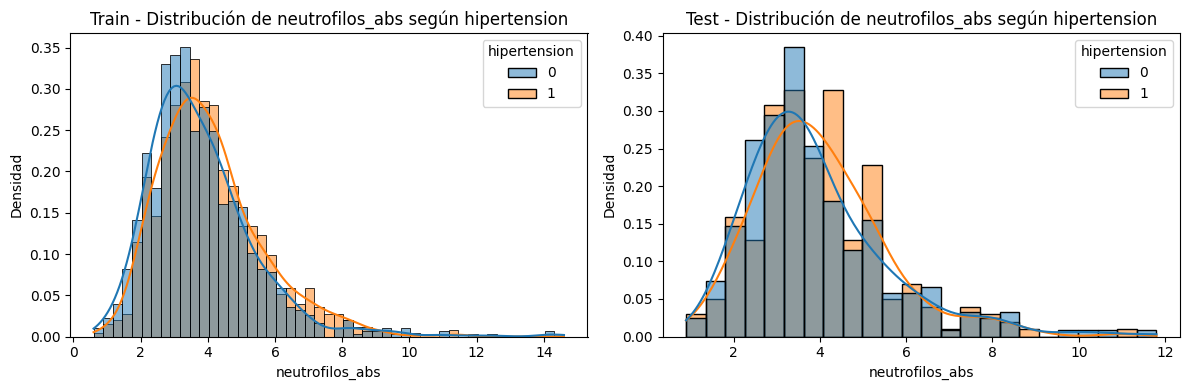

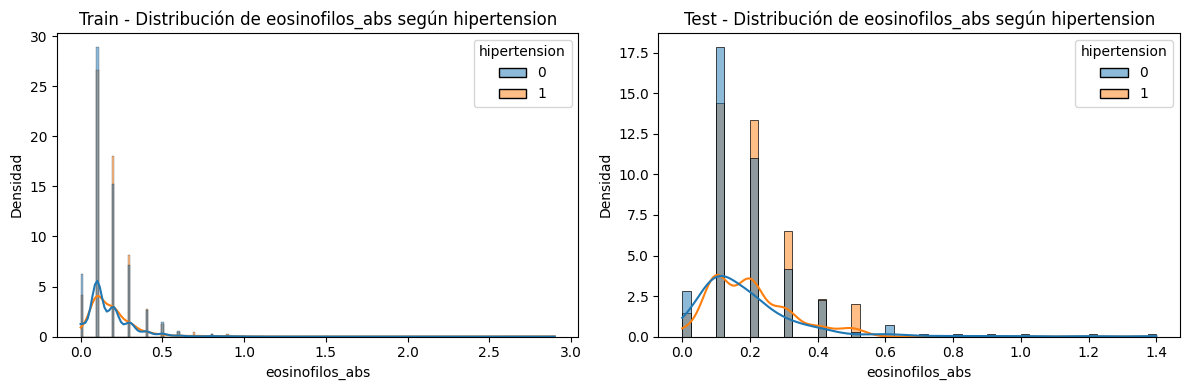

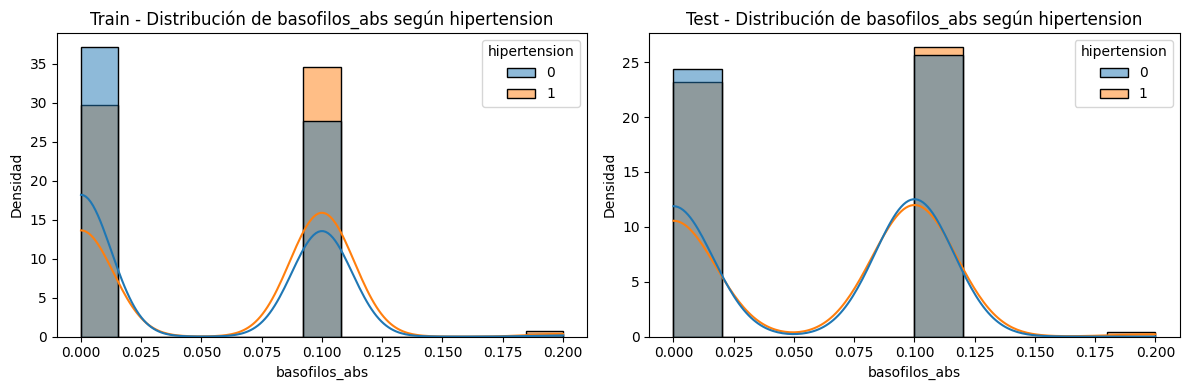

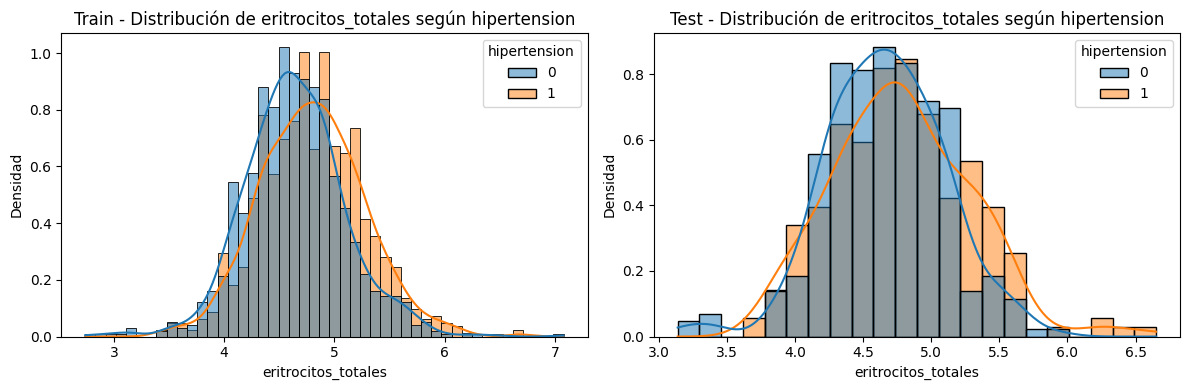

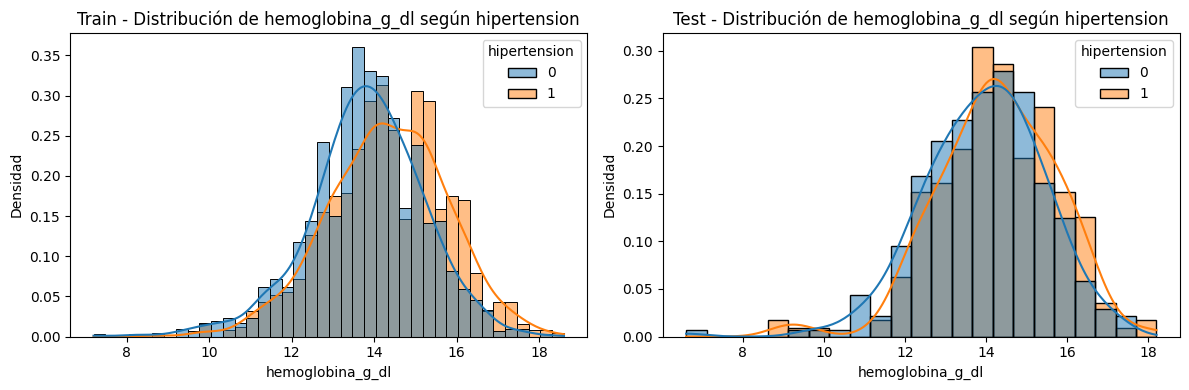

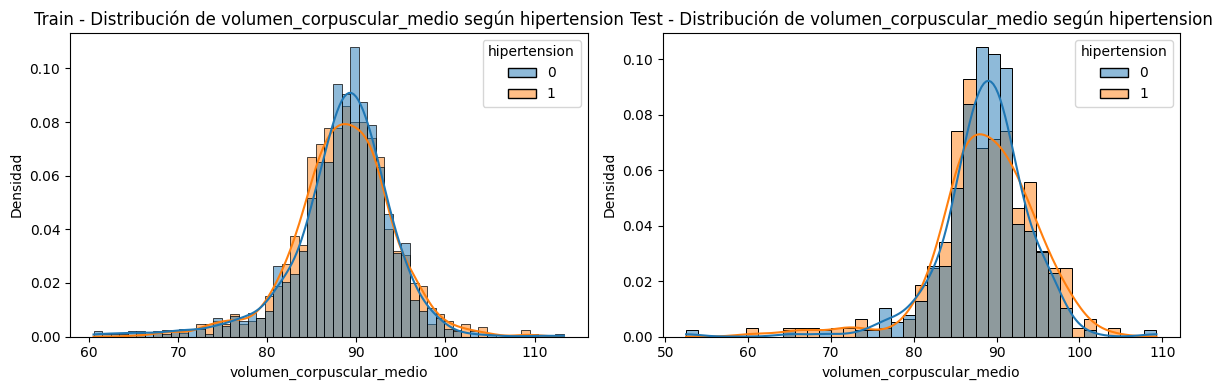

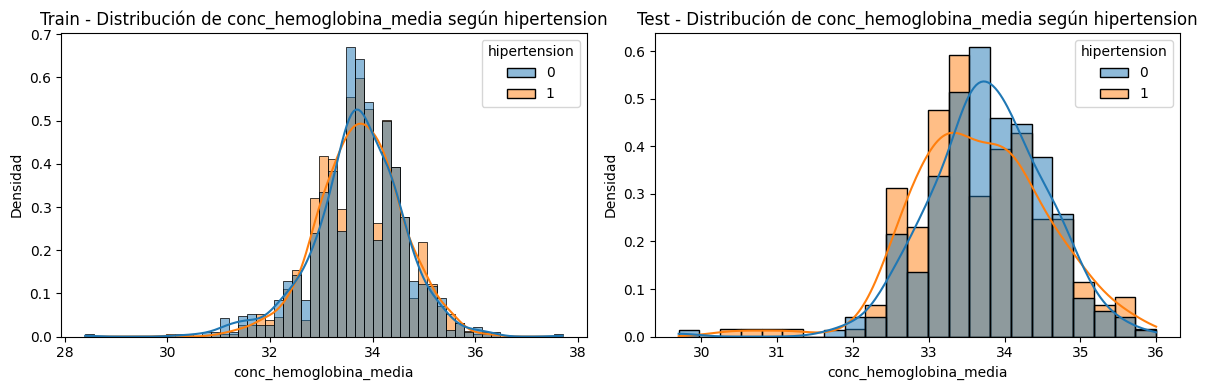

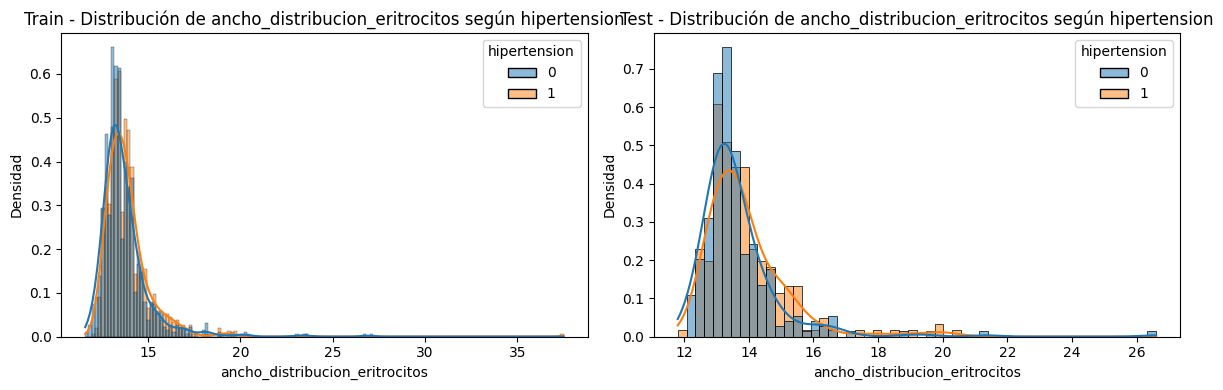

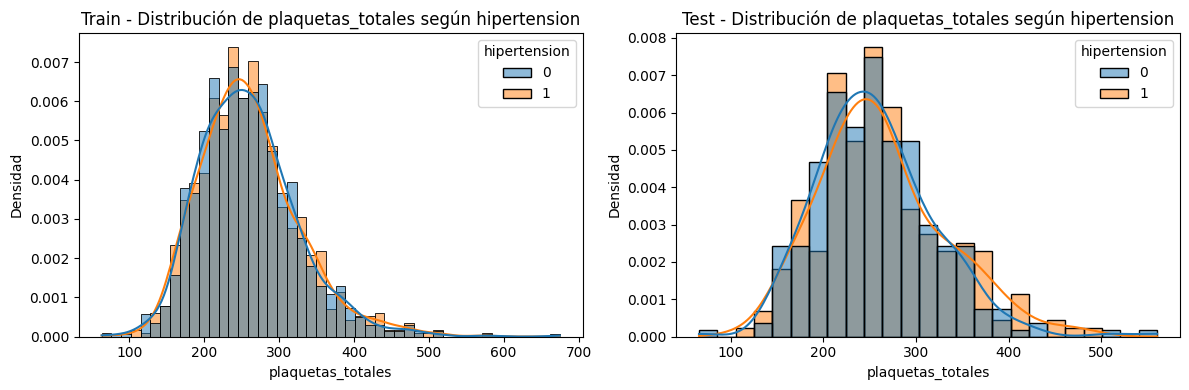

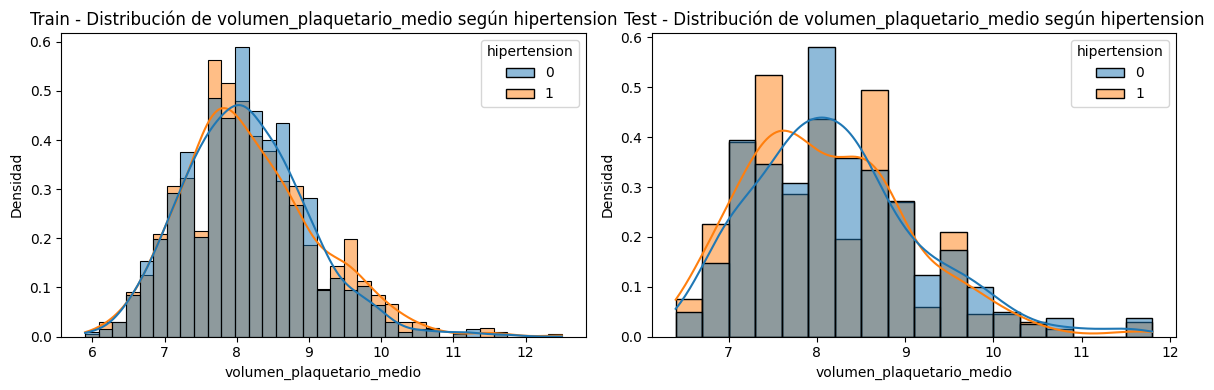

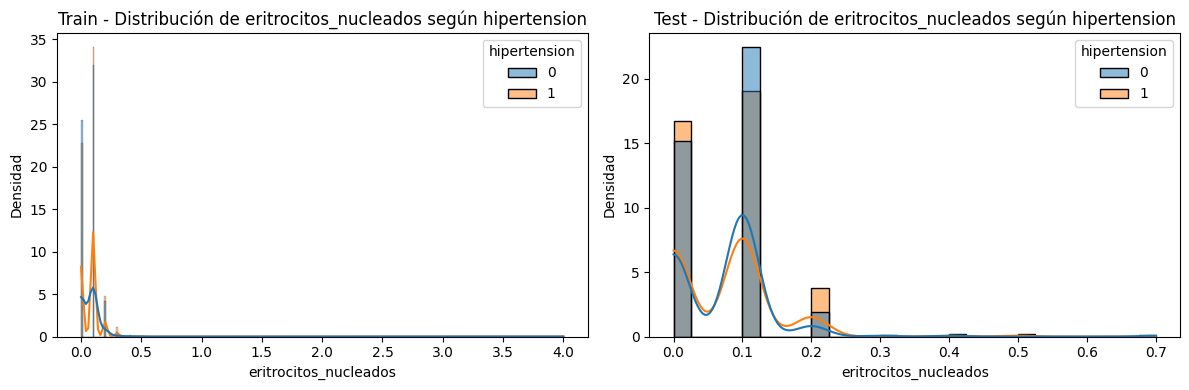

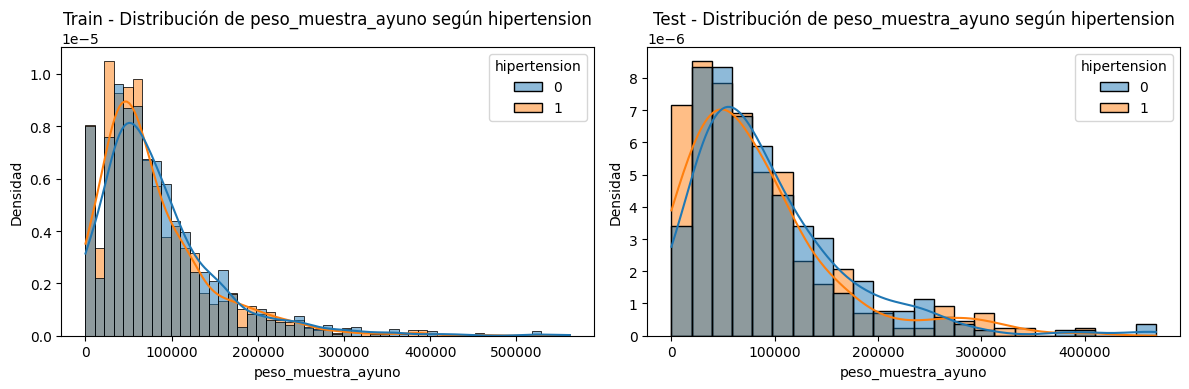

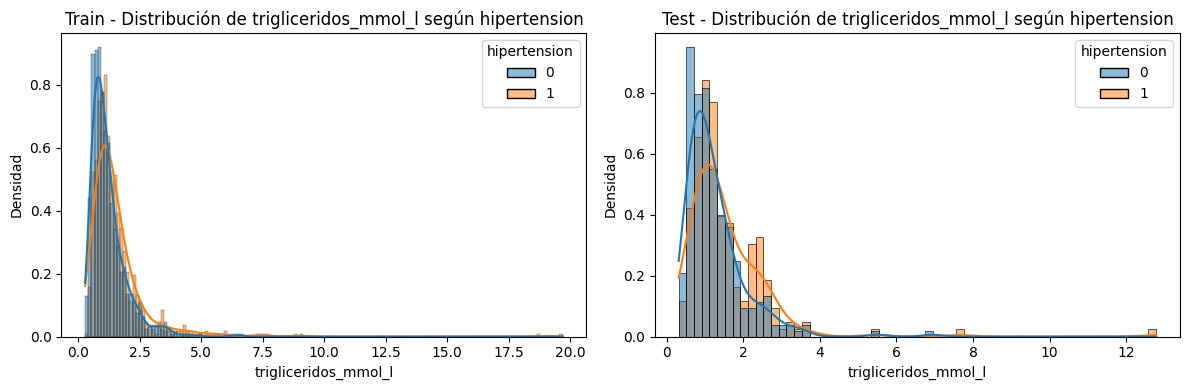

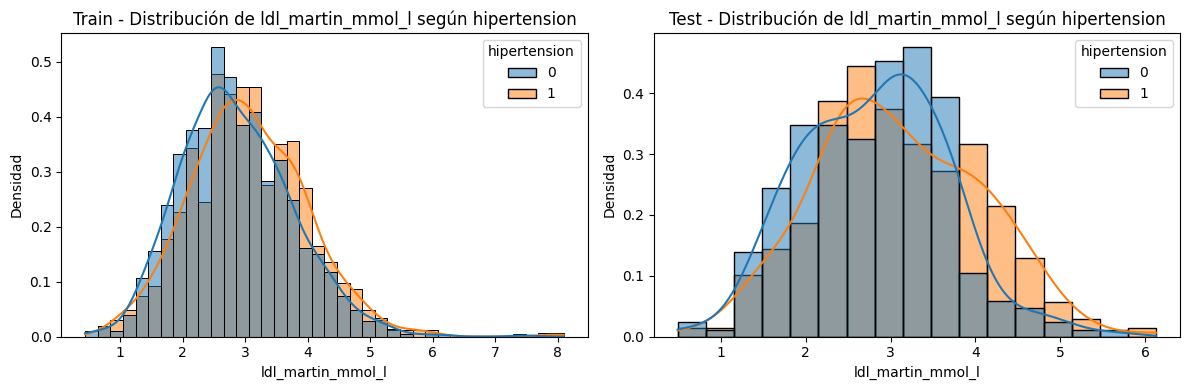

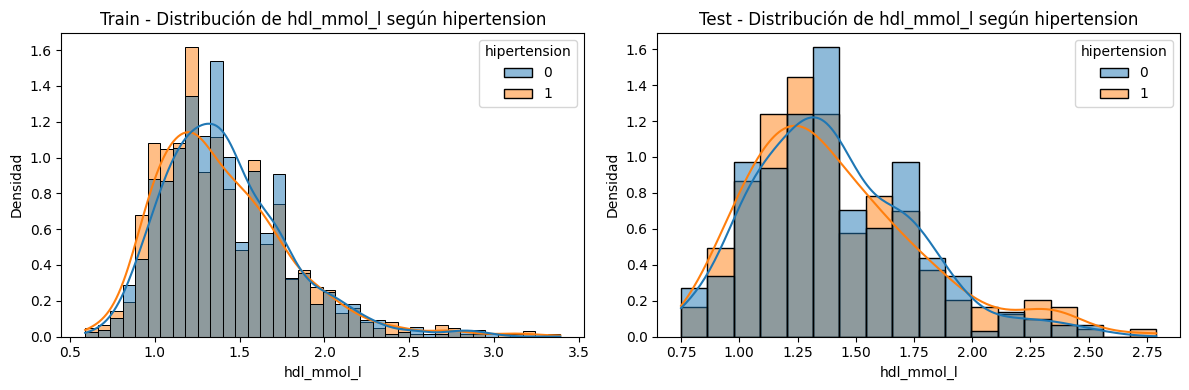

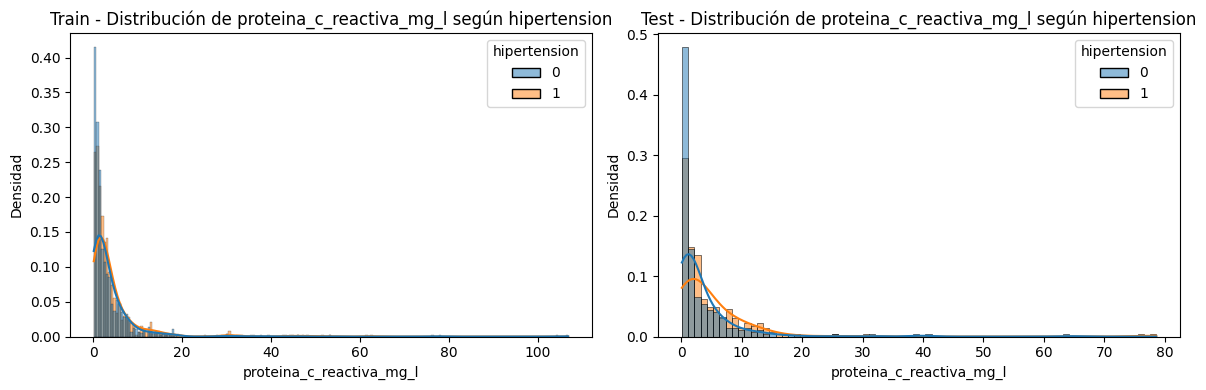

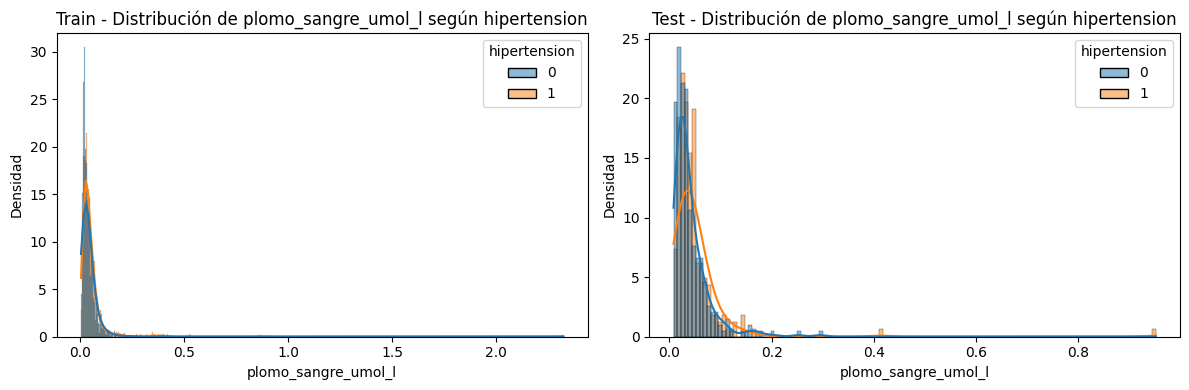

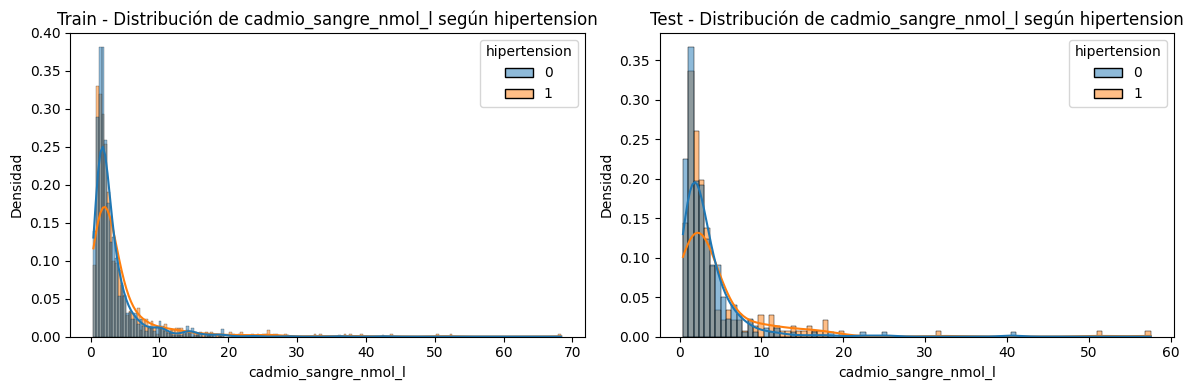

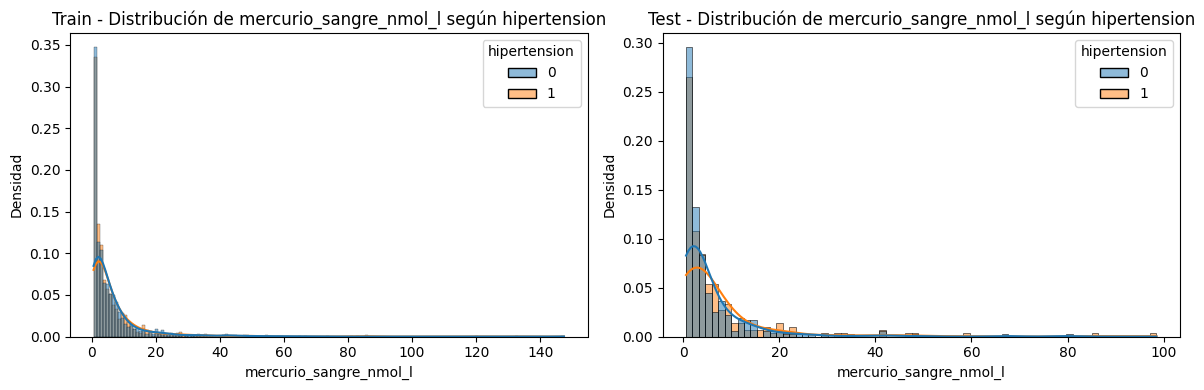

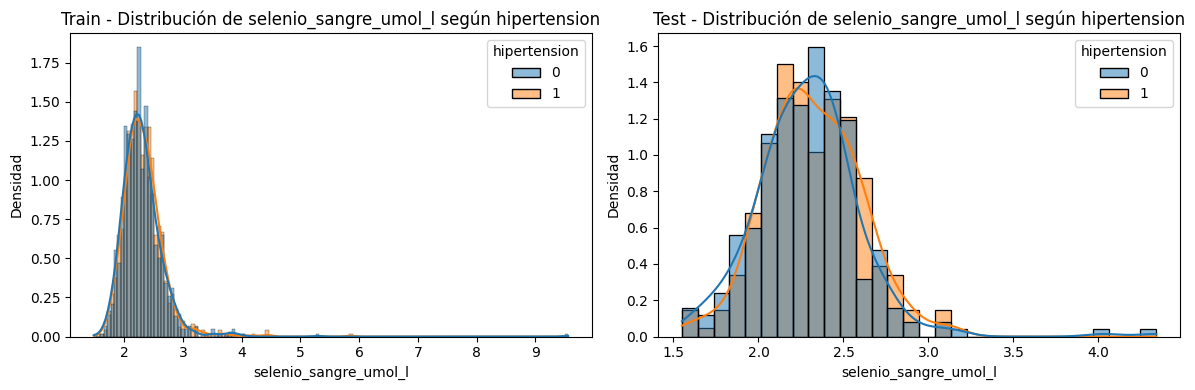

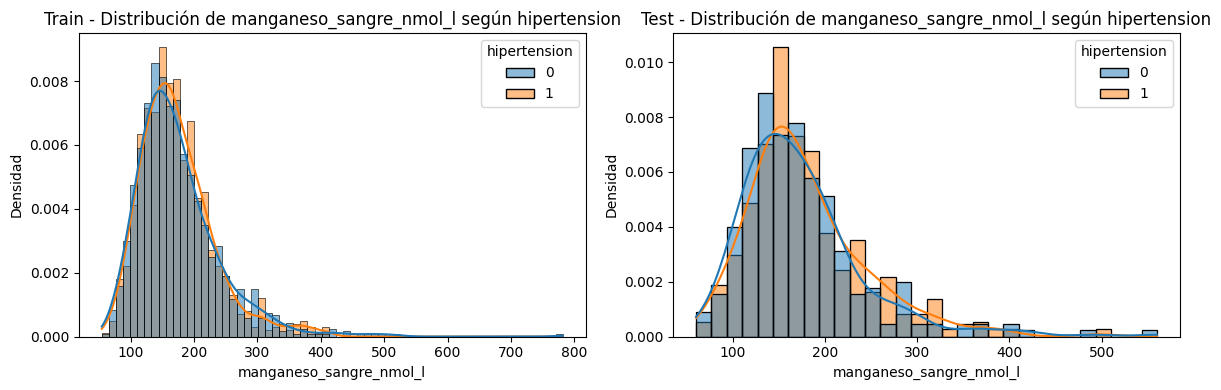

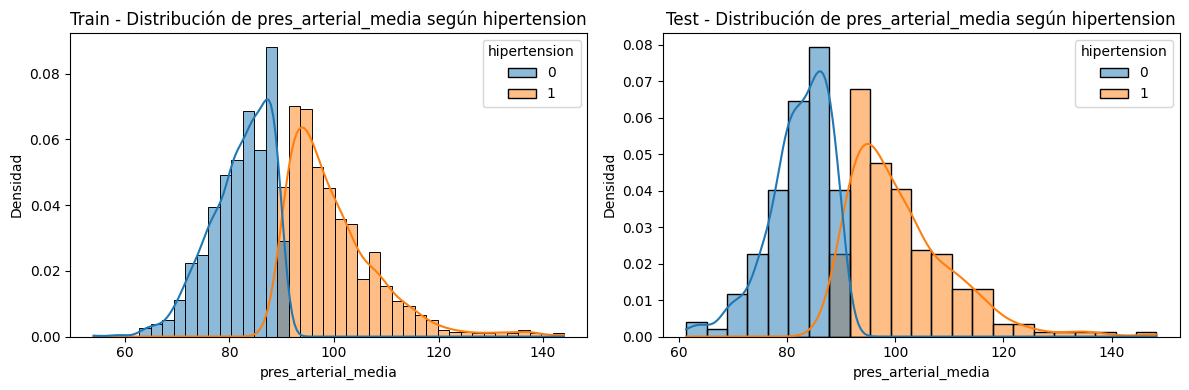

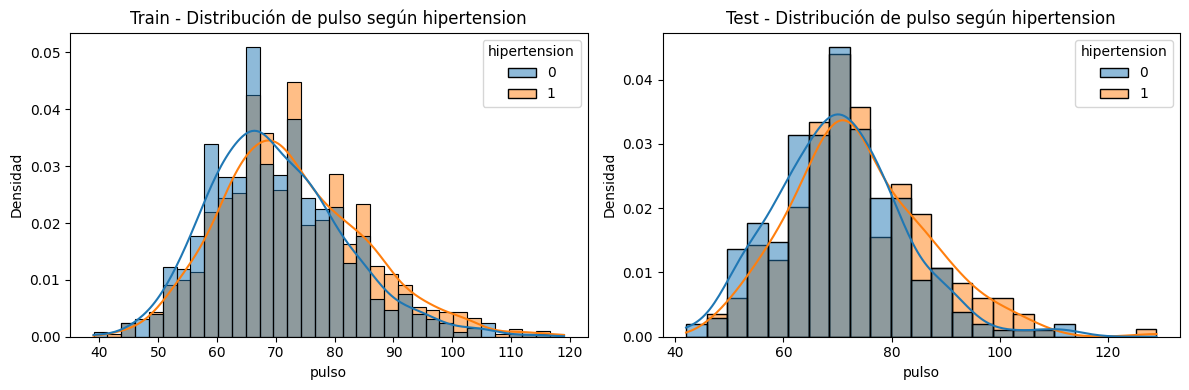

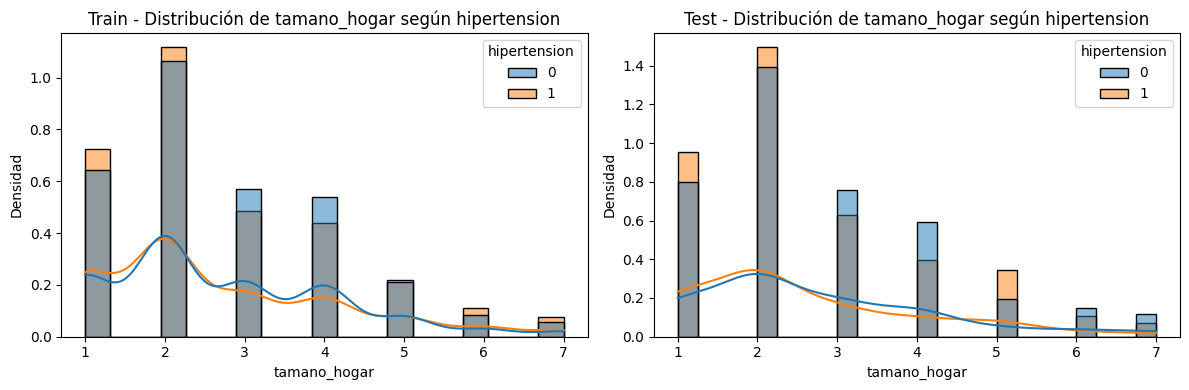

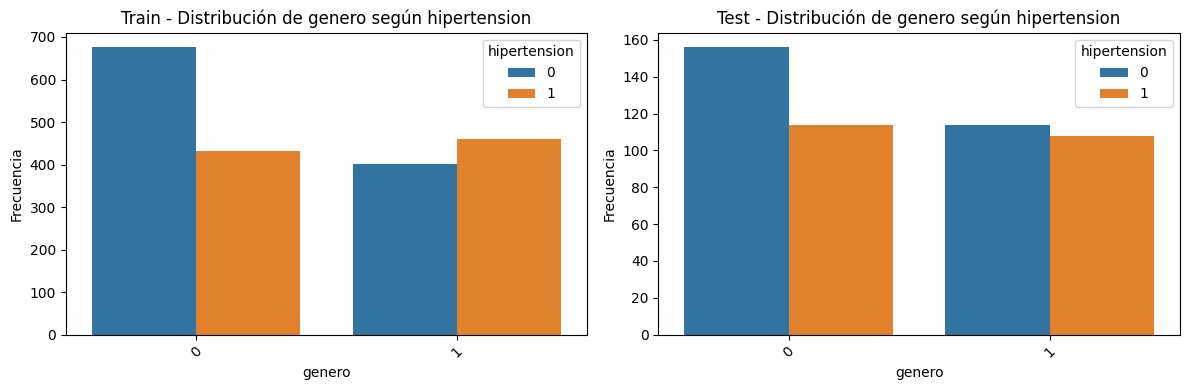

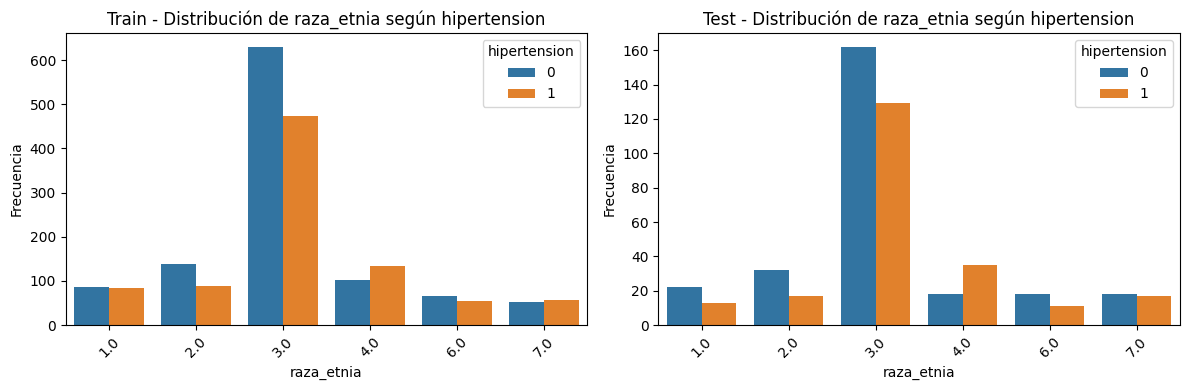

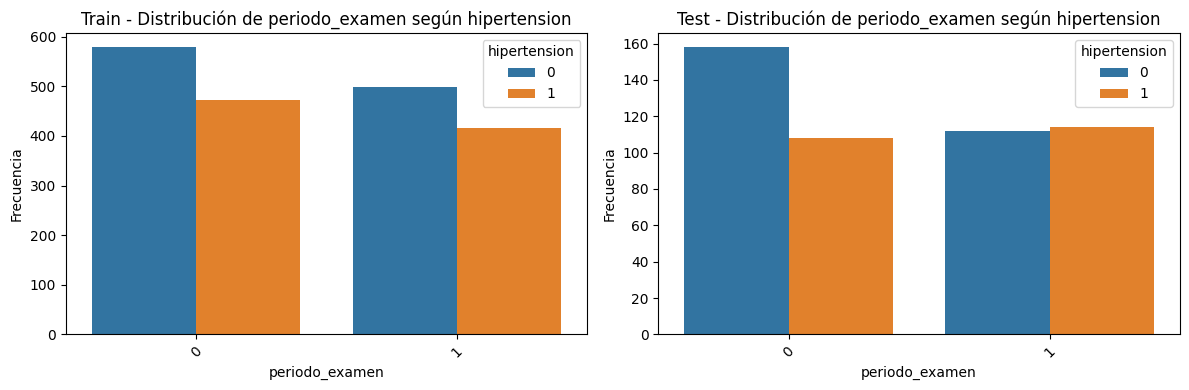

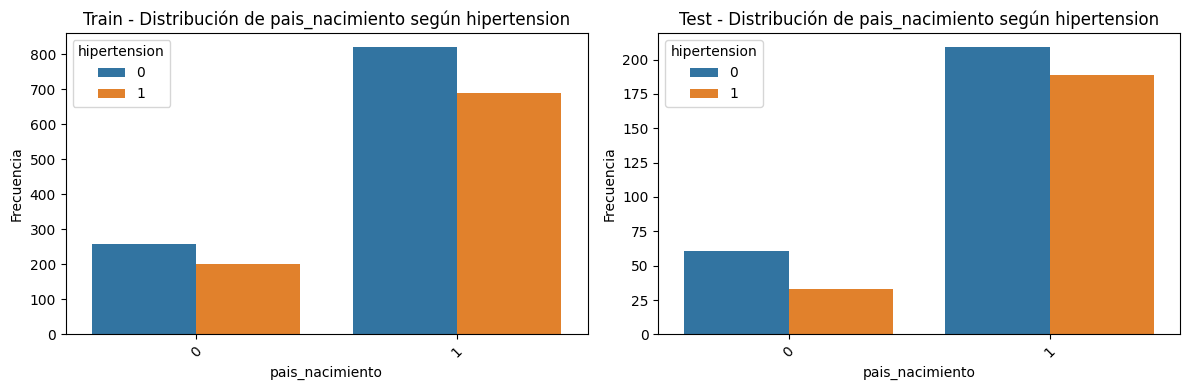

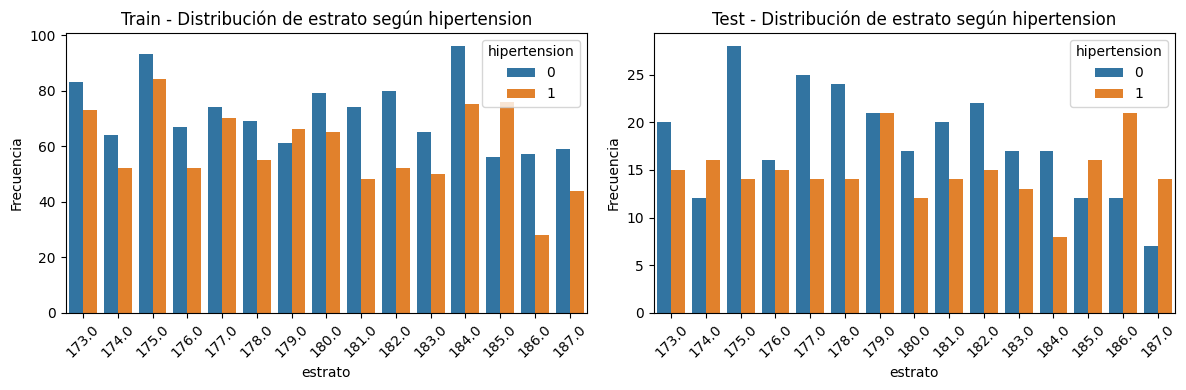

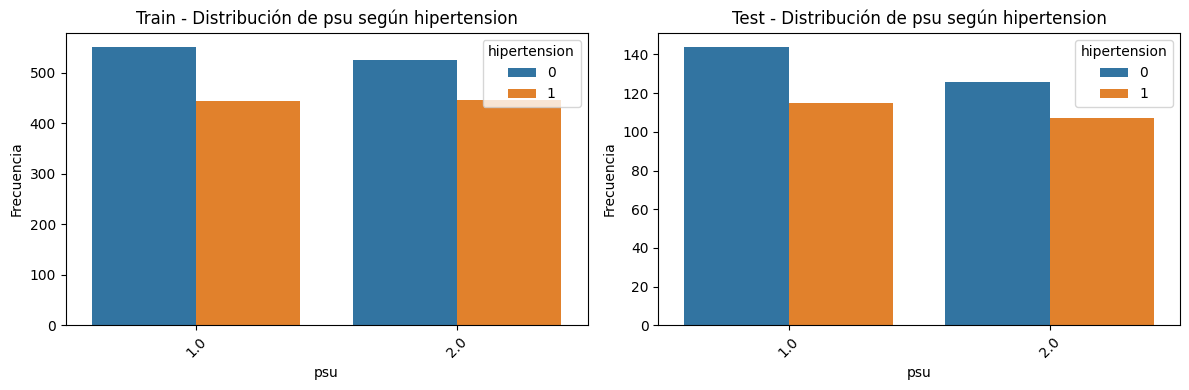

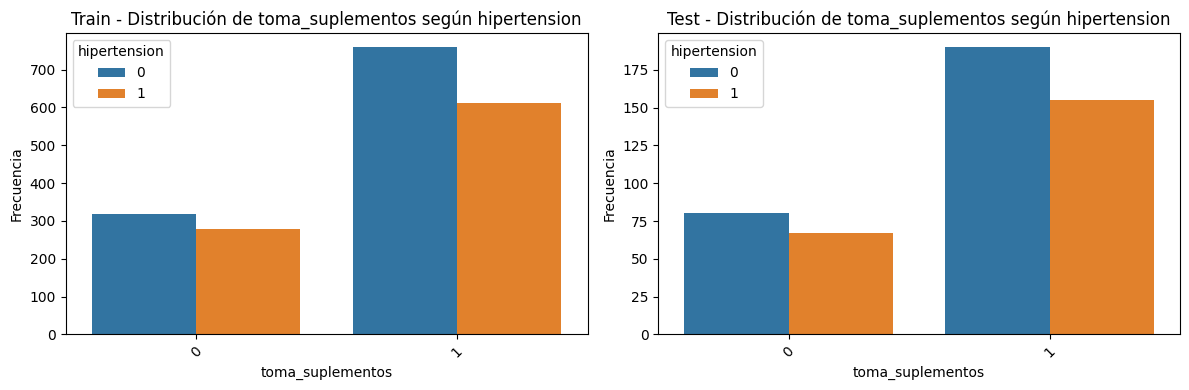

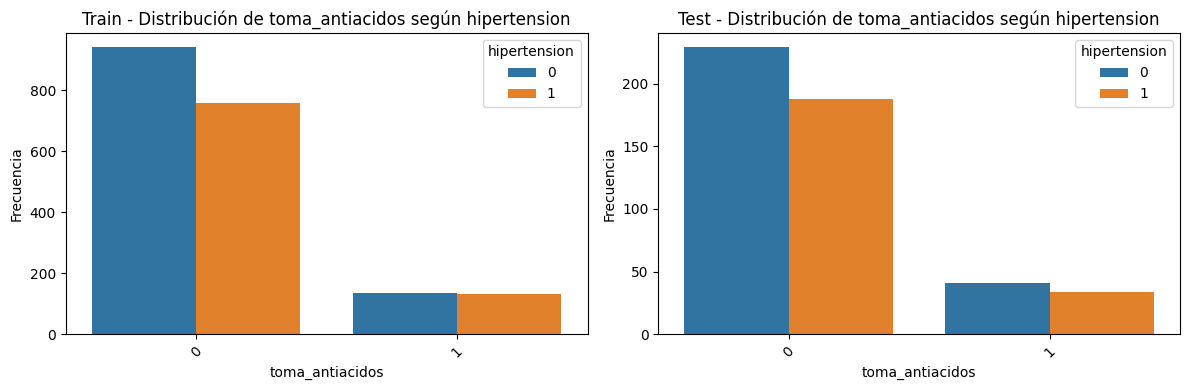

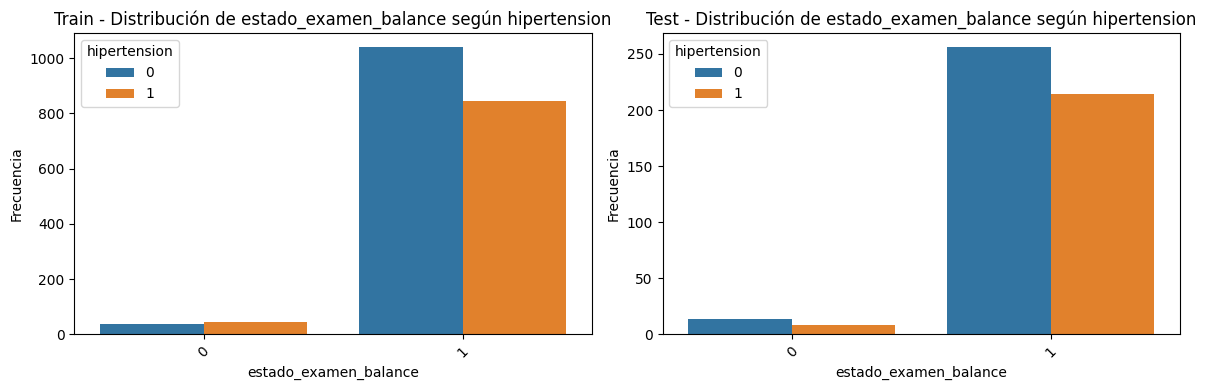

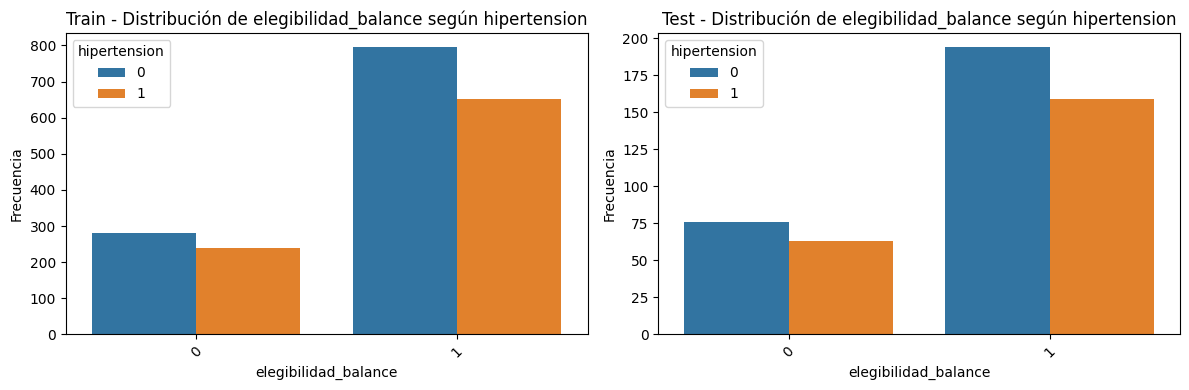

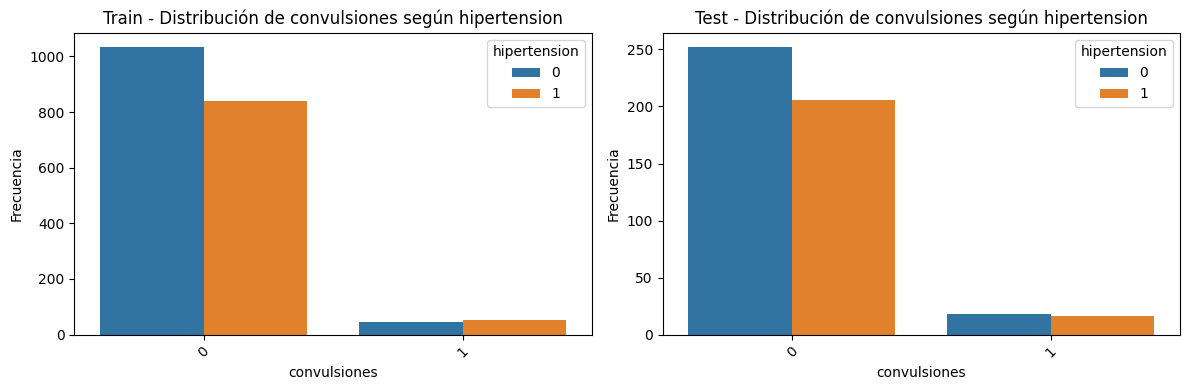

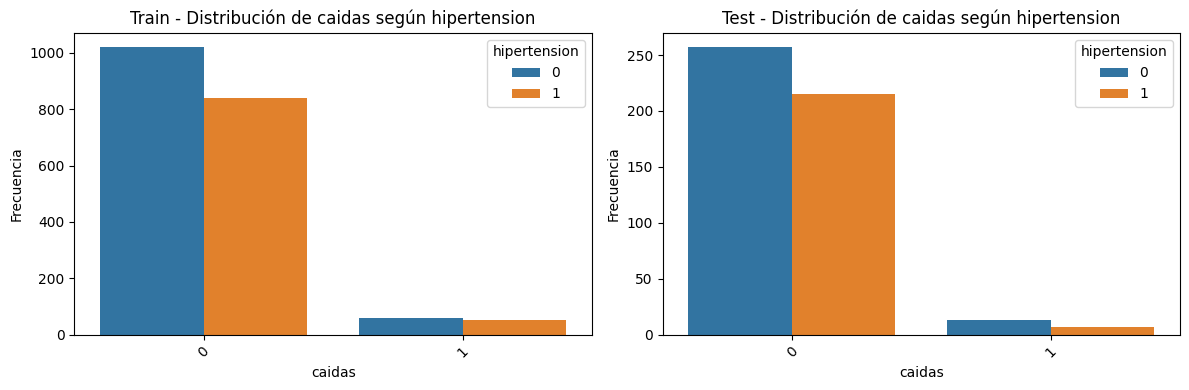

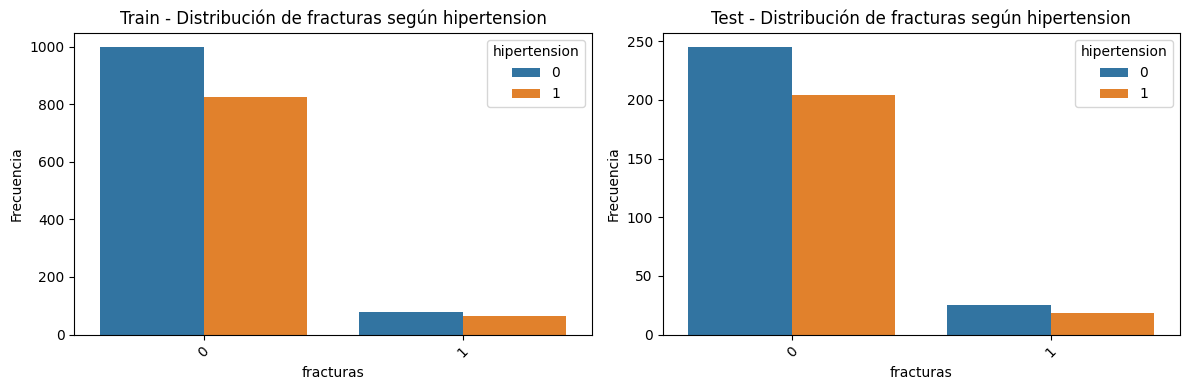

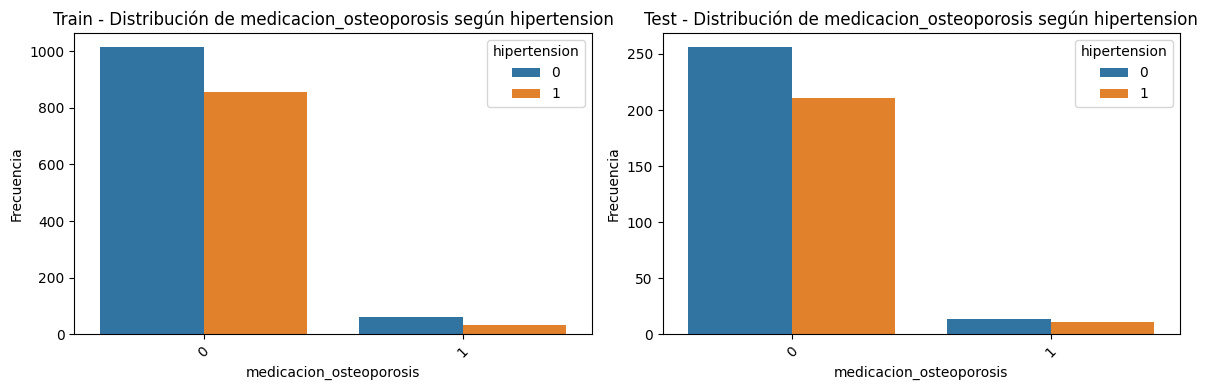

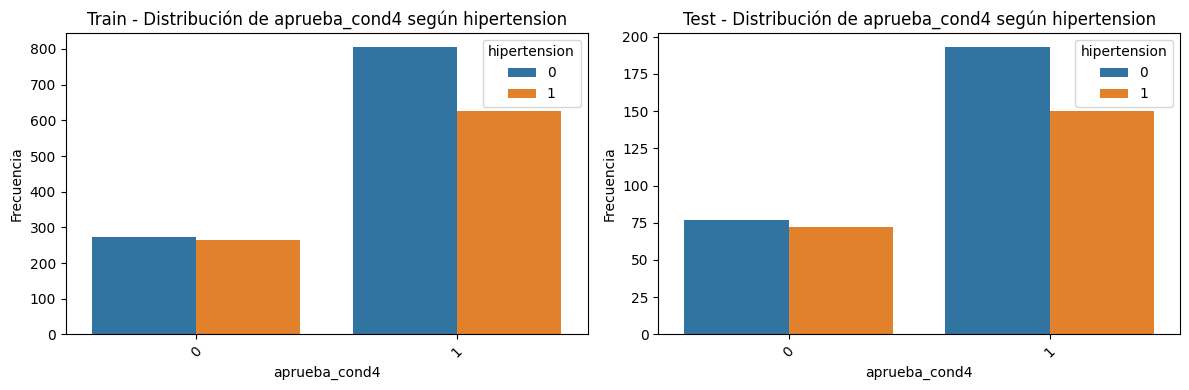

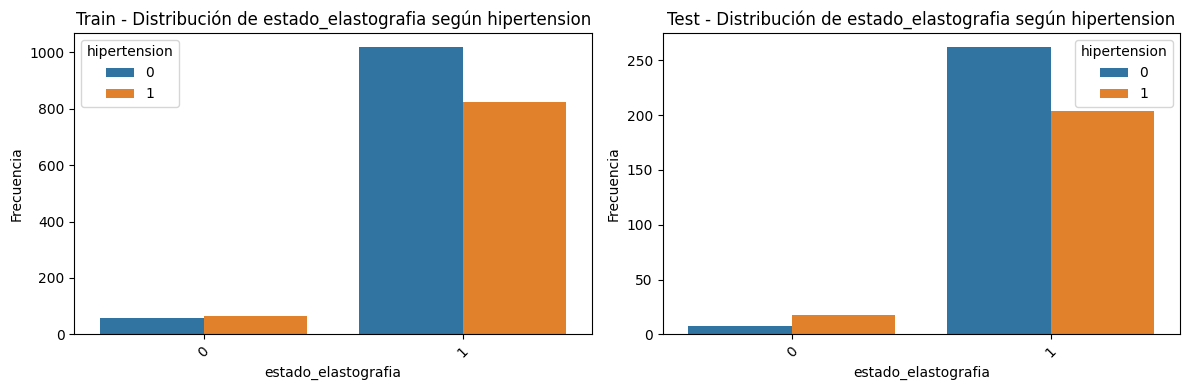

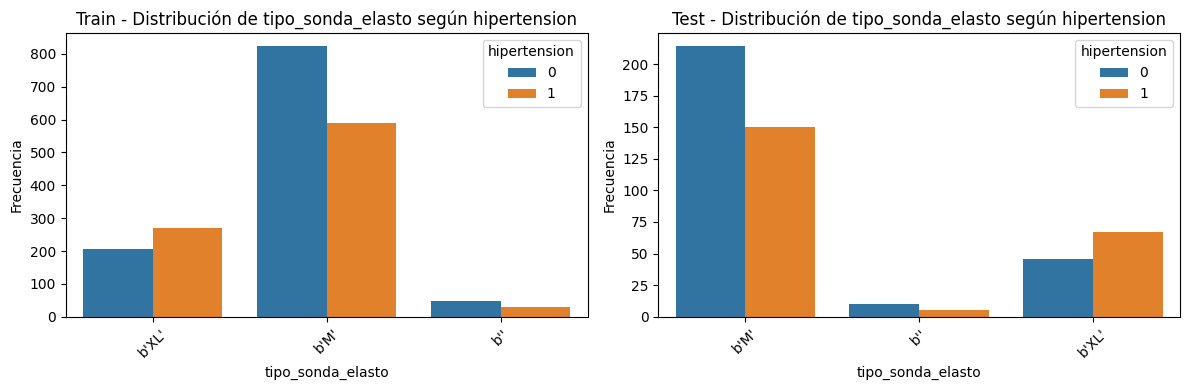

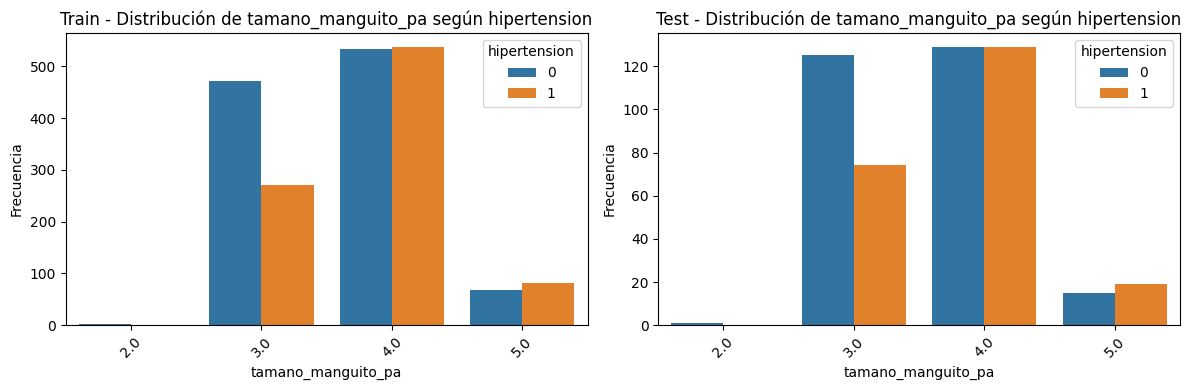

In [141]:
target = "hipertension"

# Asegurar que solo usamos columnas comunes entre train y test
num_cols = [col for col in num_cols if col in test_df.columns]
cat_cols = [col for col in cat_cols if col in test_df.columns]

# 1. Distribución del target

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=train_df, x=target, ax=axes[0])
axes[0].set_title("Distribución del target en train_df")
axes[0].set_xlabel(target)
axes[0].set_ylabel("Frecuencia")

sns.countplot(data=test_df, x=target, ax=axes[1])
axes[1].set_title("Distribución del target en test_df")
axes[1].set_xlabel(target)
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# 2. Distribución de variables numéricas según target en train_df y test_df

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=train_df,
        x=col,
        hue=target,
        kde=True,
        stat="density",
        common_norm=False,
        ax=axes[0]
    )
    axes[0].set_title(f"Train - Distribución de {col} según {target}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Densidad")

    sns.histplot(
        data=test_df,
        x=col,
        hue=target,
        kde=True,
        stat="density",
        common_norm=False,
        ax=axes[1]
    )
    axes[1].set_title(f"Test - Distribución de {col} según {target}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Densidad")

    plt.tight_layout()
    plt.show()

# 3. Distribución de variables categóricas según target en train_df y test_df

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(
        data=train_df,
        x=col,
        hue=target,
        ax=axes[0]
    )
    axes[0].set_title(f"Train - Distribución de {col} según {target}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    sns.countplot(
        data=test_df,
        x=col,
        hue=target,
        ax=axes[1]
    )
    axes[1].set_title(f"Test - Distribución de {col} según {target}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frecuencia")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

<u>**Reu Paula** (19/05)</u>
- Meter mediana
- Revisar q todas las categorías estén distribuidas
- Revisar q pulso esté quitada

In [142]:
# Resumen estadístico de variables numéricas por target

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Ampliar el ancho de visualización
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

target = "hipertension"

# Variables numéricas
num_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.drop(target, errors="ignore")

# Asegurar columnas comunes en train y test
num_cols = [col for col in num_cols if col in test_df.columns]

print("===== TRAIN =====")
display(train_df.groupby(target)[num_cols].describe())

print("===== TEST =====")
display(test_df.groupby(target)[num_cols].describe())

===== TRAIN =====


genero                                              edad_an  \
               count      mean       std  min  25%  50%  75%  max   count   
hipertension                                                                
0             1077.0  0.372331  0.483650  0.0  0.0  0.0  1.0  1.0  1077.0   
1              890.0  0.515730  0.500033  0.0  0.0  1.0  1.0  1.0   890.0   

                                                                 raza_etnia  \
                   mean        std   min   25%   50%   75%   max      count   
hipertension                                                                  
0             46.126277  14.974912  20.0  33.0  45.0  61.0  69.0     1077.0   
1             51.862921  13.045963  20.0  43.0  55.0  63.0  69.0      890.0   

                                                          periodo_examen  \
                  mean       std  min  25%  50%  75%  max          count   
hipertension                                                               
0             3.186630  1.361133  1.0  3.0  3.0  3.0  7.0         1077.0   
1             3.301124  1.452394  1.0  3.0  3.0  4.0  7.0          890.0   

                                                          pais_nacimiento  \
                  mean       std  min  25%  50%  75%  max           count   
hipertension                                                                
0             0.462396  0.498816  0.0  0.0  0.0  1.0  1.0          1077.0   
1             0.468539  0.499290  0.0  0.0  0.0  1.0  1.0           890.0   

                                                          tamano_hogar  \
                  mean       std  min  25%  50%  75%  max        count   
hipertension                                                             
0             0.761374  0.426442  0.0  1.0  1.0  1.0  1.0       1077.0   
1             0.773034  0.419106  0.0  1.0  1.0  1.0  1.0        890.0   

                                                          estrato              \
                  mean       std  min  25%  50%  75%  max   count        mean   
hipertension                                                                    
0             2.709378  1.421436  1.0  2.0  2.0  4.0  7.0  1077.0  179.748375   
1             2.662921  1.503979  1.0  2.0  2.0  4.0  7.0   890.0  179.574157   

                                                               psu            \
                   std    min    25%    50%     75%    max   count      mean   
hipertension                                                                   
0             4.263706  173.0  176.0  180.0  183.00  187.0  1077.0  1.487465   
1             4.256353  173.0  176.0  179.0  183.75  187.0   890.0  1.501124   

                                                ratio_pobreza            \
                   std  min  25%  50%  75%  max         count      mean   
hipertension                                                              
0             0.500075  1.0  1.0  1.0  2.0  2.0         933.0  3.006517   
1             0.500280  1.0  1.0  2.0  2.0  2.0         782.0  2.996918   

                                                           peso_dieta_dia1  \
                   std           min   25%   50%  75%  max           count   
hipertension                                                                 
0             1.703615  5.397605e-79  1.40  2.94  5.0  5.0          1077.0   
1             1.694784  5.397605e-79  1.44  3.04  5.0  5.0           890.0   

                                                                      \
                      mean           std           min           25%   
hipertension                                                           
0             46646.930124  49117.603617  5.397605e-79  15457.459702   
1             39274.668630  40387.200656  5.397605e-79  12880.575582   

                                                        cant_suplementos  \
                       50%           75%            max            count   
hiperte

===== TEST =====


genero                                              edad_an  \
              count      mean       std  min  25%  50%  75%  max   count   
hipertension                                                               
0             270.0  0.422222  0.494831  0.0  0.0  0.0  1.0  1.0   270.0   
1             222.0  0.486486  0.500947  0.0  0.0  0.0  1.0  1.0   222.0   

                                                                  raza_etnia  \
                   mean        std   min    25%   50%   75%   max      count   
hipertension                                                                   
0             46.051852  15.066553  20.0  32.25  46.0  61.0  69.0      270.0   
1             52.243243  12.429505  20.0  42.25  56.0  62.0  69.0      222.0   

                                                          periodo_examen  \
                  mean       std  min  25%  50%  75%  max          count   
hipertension                                                               
0             3.251852  1.456780  1.0  3.0  3.0  3.0  7.0          270.0   
1             3.418919  1.404647  1.0  3.0  3.0  4.0  7.0          222.0   

                                                          pais_nacimiento  \
                  mean       std  min  25%  50%  75%  max           count   
hipertension                                                                
0             0.414815  0.493605  0.0  0.0  0.0  1.0  1.0           270.0   
1             0.513514  0.500947  0.0  0.0  1.0  1.0  1.0           222.0   

                                                          tamano_hogar  \
                  mean       std  min  25%  50%  75%  max        count   
hipertension                                                             
0             0.774074  0.418967  0.0  1.0  1.0  1.0  1.0        270.0   
1             0.851351  0.356546  0.0  1.0  1.0  1.0  1.0        222.0   

                                                          estrato              \
                  mean       std  min  25%  50%  75%  max   count        mean   
hipertension                                                                    
0             2.725926  1.493130  1.0  2.0  2.0  4.0  7.0   270.0  179.274074   
1             2.572072  1.458858  1.0  2.0  2.0  3.0  7.0   222.0  179.986486   

                                                             psu            \
                   std    min    25%    50%    75%    max  count      mean   
hipertension                                                                 
0             3.939939  173.0  176.0  179.0  182.0  187.0  270.0  1.466667   
1             4.393001  173.0  176.0  180.0  184.0  187.0  222.0  1.481982   

                                                ratio_pobreza            \
                   std  min  25%  50%  75%  max         count      mean   
hipertension                                                              
0             0.499814  1.0  1.0  1.0  2.0  2.0         239.0  3.205690   
1             0.500804  1.0  1.0  1.0  2.0  2.0         204.0  3.016667   

                                                             peso_dieta_dia1  \
                   std           min     25%   50%  75%  max           count   
hipertension                                                                   
0             1.667757  5.397605e-79  1.6150  3.42  5.0  5.0           270.0   
1             1.662863  5.397605e-79  1.5975  2.76  5.0  5.0           222.0   

                                                                      \
                      mean           std           min           25%   
hipertension                                                           
0             51341.420201  58857.361871  5.397605e-79  14264.375049   
1             45128.736385  49038.900730  5.397605e-79  11505.119529   

                                                        cant_suplementos  \
                       50%           75%            max            count   
hipert

In [144]:
for col in cat_cols:
    print(f"\n===== {col} - TRAIN =====")
    display(pd.crosstab(train_df[col], train_df[target], normalize="columns") * 100)

    print(f"\n===== {col} - TEST =====")
    display(pd.crosstab(test_df[col], test_df[target], normalize="columns") * 100)


===== genero - TRAIN =====


hipertension,0,1
genero,,
0,62.766945,48.426966
1,37.233055,51.573034



===== genero - TEST =====


hipertension,0,1
genero,,
0,57.777778,51.351351
1,42.222222,48.648649



===== raza_etnia - TRAIN =====


...

hipertension,0,1
tipo_sonda_elasto,,
b'',3.703704,2.252252
b'M',79.259259,67.567568
b'XL',17.037037,30.180180



===== tamano_manguito_pa - TRAIN =====


hipertension,0,1
tamano_manguito_pa,,
2.0,0.278552,0.000000
3.0,43.732591,30.337079
4.0,49.582173,60.449438
5.0,6.406685,9.213483



===== tamano_manguito_pa - TEST =====


hipertension,0,1
tamano_manguito_pa,,
2.0,0.370370,0.000000
3.0,46.296296,33.333333
4.0,47.777778,58.108108
5.0,5.555556,8.558559


In [143]:
print(train_df.shape)
print(test_df.shape)

(1967, 71)
(492, 71)
